# Causal Discovery Meets Explainable Predictive Maintenance
## A Graph-Based Approach to Anomaly Prediction in HPC Systems

**Target venue:** GraphSys '26 — Euro-Par 2026 Workshop (Pisa, Italy)  
**Challenge Track 1:** Causal discovery in HPC and datacenter management <br>
**Research Hypothesis:** When a strong tabular model identifies influential variables, do those variables align with causal structure learned from the same telemetry?

---

### Dataset

**M100 dataset** (Borghesi et al., 2023) — time-aggregated IPMI sensor telemetry from the
Marconi100 Tier-0 supercomputer at CINECA, Italy.

- Each row = one 15-minute aggregation window for one computing node
- Columns = statistical aggregates (avg, std, min, max) of IPMI sensor readings:
  temperatures (ambient, DIMM, CPU cores, GPUs), power (PSU input/output, total),
  fan speeds, GPU utilization, memory bandwidth, CPU frequencies, etc.
- Anomaly labels from **Nagios** monitoring system (`value` column):
  - `0` = OK (no anomaly)
  - `2` = WARNING
  - `3` = CRITICAL
  - `NaN` = no Nagios data for that window

**Source:** https://zenodo.org/records/7541722  
**Reference:** Borghesi et al., "M100 dataset: time-aggregated data for anomaly detection", 2023

---

### Scope of this notebook

We use **rack 0 only** (16 computing nodes) to keep computation local-machine-friendly.  
We restrict to the **226 columns common to all 16 nodes** to ensure a consistent feature space
(no structural NaNs from hardware heterogeneity).

---

## Step 1 — Data Loading & Common-Schema Enforcement

**Goal:** Load all 16 parquet files from rack 0, enforce a common column schema
(intersection of columns across all nodes), tag each row with its node ID,
and produce a single clean master DataFrame.

**Why common columns only?**  
Different nodes in the Marconi100 have slightly different sensor configurations
(e.g., different CPU core temperature sensors are exposed). When we `pd.concat`
files with different column sets, pandas takes the *union* of all columns and fills
missing ones with NaN. These are *structural* NaNs (the sensor simply doesn't exist
on that node), not missing readings. By taking the *intersection* (226 columns common
to all 16 nodes), we eliminate structural NaNs entirely and get a clean, uniform
feature space. Each node individually has 354 columns, but only 226 are shared.

**What the 226 columns contain:**
- `timestamp` — start of the 15-minute aggregation window (UTC)
- `value` — Nagios anomaly label (0/2/3 or NaN)
- 224 sensor features: 56 base sensors x 4 aggregation stats (avg, std, min, max)

In [1]:
# =============================================================================
# STEP 1.0 — IMPORTS
# =============================================================================
# We keep imports minimal and explicit so it's clear what each library does.

import pandas as pd          # DataFrame manipulation
import numpy as np           # Numerical operations
from pathlib import Path     # OS-agnostic file path handling
from typing import List, Set # Type hints for clarity

print(f"pandas version: {pd.__version__}")
print(f"numpy version:  {np.__version__}")

pandas version: 3.0.2
numpy version:  2.4.4


In [2]:
# =============================================================================
# STEP 1.1 — CONFIGURATION
# =============================================================================
# All paths and settings in one place so you never hunt for hardcoded values.

# Path to the folder containing per-node parquet files for rack 0.
# Each file is named <node_id>.parquet (e.g., 2.parquet, 3.parquet, ...)
RACK_0_DIR = Path("../../dataset/M100/parquet_dataset/0")

# Sanity check: does this folder exist?
assert RACK_0_DIR.exists(), f"Rack 0 directory not found at {RACK_0_DIR.resolve()}"
print(f"Rack 0 directory: {RACK_0_DIR.resolve()}")

Rack 0 directory: C:\Users\Iman\OneDrive\Desktop\GraphSys_Study\dataset\M100\parquet_dataset\0


In [3]:
# =============================================================================
# STEP 1.2 — DISCOVER PARQUET FILES
# =============================================================================
# List all .parquet files in the rack 0 folder.
# Each file represents one computing node's full telemetry history.

parquet_files: List[Path] = sorted(RACK_0_DIR.glob("*.parquet"))

print(f"Found {len(parquet_files)} node files in rack 0:")
for f in parquet_files:
    print(f"  - {f.name}  (node_id = {f.stem})")

Found 16 node files in rack 0:
  - 10.parquet  (node_id = 10)
  - 11.parquet  (node_id = 11)
  - 13.parquet  (node_id = 13)
  - 14.parquet  (node_id = 14)
  - 16.parquet  (node_id = 16)
  - 17.parquet  (node_id = 17)
  - 18.parquet  (node_id = 18)
  - 19.parquet  (node_id = 19)
  - 2.parquet  (node_id = 2)
  - 3.parquet  (node_id = 3)
  - 4.parquet  (node_id = 4)
  - 5.parquet  (node_id = 5)
  - 6.parquet  (node_id = 6)
  - 7.parquet  (node_id = 7)
  - 8.parquet  (node_id = 8)
  - 9.parquet  (node_id = 9)


In [4]:
# =============================================================================
# STEP 1.3 — COMPUTE THE COMMON COLUMN SET (INTERSECTION)
# =============================================================================
# Why: Different nodes expose slightly different sensors (e.g., different CPU
#       core temperature channels). By taking the INTERSECTION of all column
#       sets, we get only the sensors that exist on EVERY node in rack 0.
#       This avoids structural NaNs that would pollute downstream analysis.
#
# How: We read just the column names from each parquet file's schema metadata
#       (no data loaded), compute the set intersection, and sort alphabetically.
#
# Cost: Negligible — pq.read_schema() reads only the file footer, not data.

import pyarrow.parquet as pq  # For reading parquet metadata without loading data

column_sets: List[Set[str]] = []

for f in parquet_files:
    # pq.read_schema() reads ONLY the parquet file footer (a few KB),
    # not the actual row data. This gives us column names instantly.
    schema = pq.read_schema(f)
    cols = set(schema.names)
    column_sets.append(cols)
    print(f"  Node {f.stem}: {len(cols)} columns")

# Intersection: columns present in ALL node files
common_columns: List[str] = sorted(set.intersection(*column_sets))

print(f"\n{'='*60}")
print(f"Common columns across all {len(parquet_files)} nodes: {len(common_columns)}")
print(f"  - 'timestamp' present: {'timestamp' in common_columns}")
print(f"  - 'value' (Nagios label) present: {'value' in common_columns}")
print(f"  - Sensor feature columns: {len(common_columns) - 2}")
print(f"{'='*60}")

  Node 10: 355 columns
  Node 11: 355 columns
  Node 13: 355 columns
  Node 14: 355 columns
  Node 16: 355 columns
  Node 17: 355 columns
  Node 18: 355 columns
  Node 19: 355 columns
  Node 2: 355 columns
  Node 3: 355 columns
  Node 4: 355 columns
  Node 5: 355 columns
  Node 6: 355 columns
  Node 7: 355 columns
  Node 8: 355 columns
  Node 9: 355 columns

Common columns across all 16 nodes: 227
  - 'timestamp' present: True
  - 'value' (Nagios label) present: True
  - Sensor feature columns: 225


In [5]:
# =============================================================================
# STEP 1.4 — LOAD ALL NODE FILES INTO A SINGLE MASTER DATAFRAME
# =============================================================================
# For each node file:
#   1. Read ONLY the common columns (avoids loading unused sensors)
#   2. Add a 'node_id' column so we always know which node a row came from
#   3. Convert the 'timestamp' column to proper datetime
#   4. Append to a list, then concatenate once at the end
#
# Why concat-at-the-end? Repeatedly calling pd.concat inside a loop is O(n^2)
# because it copies the growing DataFrame each time. Collecting into a list
# and concatenating once is O(n).

node_dfs: List[pd.DataFrame] = []

for f in parquet_files:
    # Read only the common columns — this is both faster and avoids column mismatches
    df_node = pd.read_parquet(f, columns=common_columns)
    
    # Tag every row with its node ID (the filename stem, e.g., "2", "3", ...)
    # This is critical for:
    #   - per-node grouping in causal analysis
    #   - ensuring we shift the target label within the same node (not across nodes)
    df_node["node_id"] = f.stem
    
    # Ensure timestamp is proper datetime (parquet usually preserves this, but be safe)
    df_node["timestamp"] = pd.to_datetime(df_node["timestamp"], errors="coerce")
    
    node_dfs.append(df_node)
    print(f"  Loaded node {f.stem}: {df_node.shape[0]:>7,} rows")

# Concatenate all nodes into one master DataFrame
df = pd.concat(node_dfs, ignore_index=True)

# Sort by node and time — essential for correct temporal operations later
df = df.sort_values(["node_id", "timestamp"]).reset_index(drop=True)

print(f"\n{'='*60}")
print(f"Master DataFrame shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"  - {len(common_columns)} common sensor/label columns + 1 node_id column")
print(f"  - Nodes: {sorted(df['node_id'].unique())}")
print(f"  - Time range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"{'='*60}")

  Loaded node 10:  83,923 rows
  Loaded node 11:  83,919 rows
  Loaded node 13:  83,921 rows
  Loaded node 14:  83,925 rows
  Loaded node 16:  79,992 rows
  Loaded node 17:  83,918 rows
  Loaded node 18:  83,923 rows
  Loaded node 19:  81,847 rows
  Loaded node 2:  79,989 rows
  Loaded node 3:  72,944 rows
  Loaded node 4:  82,403 rows
  Loaded node 5:  75,952 rows
  Loaded node 6:  82,604 rows
  Loaded node 7:  83,920 rows
  Loaded node 8:  83,922 rows
  Loaded node 9:  83,923 rows

Master DataFrame shape: 1,311,025 rows  x  227 columns
  - 227 common sensor/label columns + 1 node_id column
  - Nodes: ['10', '11', '13', '14', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
  - Time range: 2020-03-09 12:00:00+00:00 → 2022-09-28 22:00:00+00:00
  - Memory usage: 2379.0 MB


In [6]:
# =============================================================================
# STEP 1.5 — QUICK SANITY CHECKS
# =============================================================================
# Before moving on, verify the data looks right.

# Filter common_columns to only those actually present in df
# (parquet schema may include metadata columns like __index_level_0__
#  that pandas absorbs as the index rather than keeping as a column)
available_common = [c for c in common_columns if c in df.columns]

print("--- Data types summary ---")
print(df.dtypes.value_counts())
print()

print("--- First 5 rows (selected columns) ---")
# Show a readable subset: timestamp, node_id, a few sensors, and the label
preview_cols = ["timestamp", "node_id", "ambient_avg", "total_power_avg", 
                "gpu0_core_temp_avg", "fan0_avg", "value"]
# Only show columns that actually exist
preview_cols = [c for c in preview_cols if c in df.columns]
display(df[preview_cols].head())
print()

print("--- Nagios label ('value') distribution ---")
print(df["value"].value_counts(dropna=False).sort_index())
print(f"\n  NaN (no Nagios data): {df['value'].isna().sum():,} rows ({df['value'].isna().mean()*100:.1f}%)")
print(f"  0 = OK:               {(df['value'] == 0).sum():,} rows")
print(f"  2 = WARNING:          {(df['value'] == 2).sum():,} rows")
print(f"  3 = CRITICAL:         {(df['value'] == 3).sum():,} rows")
print()

print("--- Missing values in sensor columns ---")
sensor_cols = [c for c in available_common if c not in ["timestamp", "value"]]
missing_pct = df[sensor_cols].isna().mean() * 100
print(f"  Columns with 0% missing:   {(missing_pct == 0).sum()}")
print(f"  Columns with >0% missing:  {(missing_pct > 0).sum()}")
if (missing_pct > 0).any():
    print(f"  Columns with >50% missing: {(missing_pct > 50).sum()}")
    print("\n  Top 10 missing columns:")
    print(missing_pct[missing_pct > 0].sort_values(ascending=False).head(10).to_string())
print()

print("--- Rows per node ---")
print(df.groupby("node_id").size().to_string())

print(f"\n✓ Step 1 complete. Master DataFrame 'df' is ready.")
print(f"  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  Usable sensor features: {len(sensor_cols)}")

--- Data types summary ---
float64                224
datetime64[us, UTC]      1
Int32                    1
str                      1
Name: count, dtype: int64

--- First 5 rows (selected columns) ---


,timestamp,node_id,ambient_avg,total_power_avg,gpu0_core_temp_avg,value
0,2020-03-09 12:00:00+00:00,10,21.208000,422.307692,35.0,<NA>
1,2020-03-09 12:15:00+00:00,10,21.487499,428.750000,35.0,<NA>
2,2020-03-09 12:30:00+00:00,10,21.554283,425.714286,35.0,<NA>
3,2020-03-09 12:45:00+00:00,10,21.644441,429.444444,35.0,<NA>
4,2020-03-09 13:00:00+00:00,10,21.608885,427.111111,35.0,<NA>



--- Nagios label ('value') distribution ---
value
0       948618
2       124686
3        28367
<NA>    209354
Name: count, dtype: Int64

  NaN (no Nagios data): 209,354 rows (16.0%)
  0 = OK:               948,618 rows
  2 = WARNING:          124,686 rows
  3 = CRITICAL:         28,367 rows

--- Missing values in sensor columns ---
  Columns with 0% missing:   0
  Columns with >0% missing:  224
  Columns with >50% missing: 0

  Top 10 missing columns:
gpu4_mem_temp_std    8.280010
gpu4_mem_temp_min    8.280010
gpu4_mem_temp_max    8.280010
gpu4_mem_temp_avg    8.280010
gpu0_mem_temp_std    8.279705
gpu0_mem_temp_min    8.279705
gpu0_mem_temp_max    8.279705
gpu0_mem_temp_avg    8.279705
gpu1_mem_temp_std    8.278713
gpu1_mem_temp_min    8.278713

--- Rows per node ---
node_id
10    83923
11    83919
13    83921
14    83925
16    79992
17    83918
18    83923
19    81847
2     79989
3     72944
4     82403
5     75952
6     82604
7     83920
8     83922
9     83923

✓ Step 1 complete. 

In [7]:
# =============================================================================
# STEP 1.6 — SAVE THE CLEAN MASTER DATAFRAME TO PARQUET
# =============================================================================
# Why save now?
#   - Avoids re-running the loading + concatenation pipeline every time
#     you restart the notebook or come back later.
#   - Parquet is columnar and compressed — much smaller on disk than CSV,
#     and preserves dtypes (timestamps, ints, floats) perfectly.
#   - All downstream steps can just read this single file.

OUTPUT_DIR = Path("../../dataset/M100/parquet_dataset/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_path = OUTPUT_DIR / "rack0_common_schema.parquet"

df.to_parquet(output_path, index=False)

# Verify the saved file
file_size_mb = output_path.stat().st_size / 1e6
df_check = pd.read_parquet(output_path)

print(f"Saved to: {output_path.resolve()}")
print(f"File size: {file_size_mb:.1f} MB")
print(f"Verification — re-read shape: {df_check.shape[0]:,} rows x {df_check.shape[1]} columns")
print(f"Rows match: {df_check.shape[0] == df.shape[0]}")
print(f"Columns match: {df_check.shape[1] == df.shape[1]}")

del df_check  # Free memory immediately

print(f"\n✓ Master DataFrame saved. In future sessions, load with:")
print(f'  df = pd.read_parquet("{output_path}")')

Saved to: C:\Users\Iman\OneDrive\Desktop\GraphSys_Study\dataset\M100\parquet_dataset\processed\rack0_common_schema.parquet
File size: 168.1 MB
Verification — re-read shape: 1,311,025 rows x 227 columns
Rows match: True
Columns match: True

✓ Master DataFrame saved. In future sessions, load with:
  df = pd.read_parquet("..\..\dataset\M100\parquet_dataset\processed\rack0_common_schema.parquet")


<br> <br> <br>

## Step 2 — Target Validation, Binarization & Prediction Horizon

**Goal:** Turn the raw [Nagios value](https://learn.netdata.cloud/docs/collecting-metrics/collectors/synthetic-testing/nagios-plugins-and-custom-scripts) column into a clean binary target suitable
for predictive maintenance, then shift it forward by one time window so the model
learns to predict *future* anomalies from *current* sensor readings.

### Why binarize?

The raw Nagios `value` has three levels:
- `0` = OK (system healthy)
- `2` = WARNING (degraded performance or early fault signal)
- `3` = CRITICAL (active fault / failure)

For predictive maintenance, we care about **any** deviation from normal operation.
Both WARNING and CRITICAL represent states an operator would want advance notice of.
Treating them as a single "anomaly" class also avoids the severe class imbalance
that would come from trying to predict the rare CRITICAL class alone (~2.2%).

**Binarization rule:** `0  → 0` (normal), `2 or 3  → 1` (anomaly)

### Why create a prediction horizon?

Predictive maintenance is about **early warning** — predicting a fault *before* it
happens, not detecting it after the fact. We achieve this by:

1. Using sensor readings at time `t` as features (X)
2. Using the anomaly label at time `t+1` (the *next* 15-minute window) as the target (y)

This means: "given what the sensors show right now, will an anomaly occur in the
next 15 minutes?" This is done via `groupby('node_id').shift(-1)` — shifting the
label column backward by one row *within each node* (never across nodes).

### What about NaN labels?

~16% of rows have `NaN` in the `value` column (no Nagios data for that window).
We drop these rows because:
- We cannot know the true state of the system for those windows
- Using them as features is fine, but we cannot use them as targets
- Imputing anomaly labels would introduce bias (we'd be guessing ground truth)

In [8]:
# =============================================================================
# STEP 2.0 — VALIDATE THE NAGIOS LABEL COLUMN
# =============================================================================
# Before transforming the label, let's confirm it behaves as expected.
# The 'value' column should contain only {0, 2, 3} and NaN.
#
# Nagios plugin return codes (industry standard):
#   0 = OK        — service is functioning normally
#   1 = WARNING   — approaching threshold (NOT present in our data)
#   2 = WARNING   — threshold exceeded / degraded performance
#   3 = CRITICAL  — service is in a failure state
#
# Note: Nagios code 1 (WARNING) is absent from this dataset. The M100 monitoring
# configuration likely maps its alerts directly to codes 0, 2, and 3.

print("=" * 60)
print("STEP 2.0 — Validating the 'value' (Nagios label) column")
print("=" * 60)

# Check the dtype — should be nullable Int32 (from parquet)
print(f"\n  dtype: {df['value'].dtype}")

# Check unique values (excluding NaN)
unique_vals = sorted(df["value"].dropna().unique())
print(f"  Unique non-NaN values: {unique_vals}")

# Confirm we only have expected Nagios codes
expected_codes = {0, 2, 3}
actual_codes = set(int(v) for v in unique_vals)
assert actual_codes <= expected_codes, (
    f"Unexpected Nagios codes found: {actual_codes - expected_codes}"
)
print(f"  All values are valid Nagios codes: actual code: {actual_codes} and expected code: {expected_codes}")

# Distribution breakdown with percentages
print(f"\n  Full distribution (including NaN):")
total = len(df)
for label, count in df["value"].value_counts(dropna=False).sort_index().items():
    pct = count / total * 100
    if pd.isna(label):
        print(f"    NaN (no monitoring):  {count:>10,} rows  ({pct:5.1f}%)")
    else:
        label_name = {0: "OK", 2: "WARNING", 3: "CRITICAL"}.get(int(label), "???")
        print(f"    {int(label)} = {label_name:<10s}:  {count:>10,} rows  ({pct:5.1f}%)")

# Check per-node: does every node have all three label types?
print(f"\n  Per-node label presence:")
for node in sorted(df["node_id"].unique()):
    node_vals = set(int(v) for v in df.loc[df["node_id"] == node, "value"].dropna().unique())
    missing_codes = expected_codes - node_vals
    status = "all codes present" if not missing_codes else f"MISSING codes: {missing_codes}"
    print(f"    Node {node:>2s}: {status}")

print("\n✓ Label validation passed.")

STEP 2.0 — Validating the 'value' (Nagios label) column

  dtype: Int32
  Unique non-NaN values: [np.int32(0), np.int32(2), np.int32(3)]
  All values are valid Nagios codes: actual code: {0, 2, 3} and expected code: {0, 2, 3}

  Full distribution (including NaN):
    0 = OK        :     948,618 rows  ( 72.4%)
    2 = WARNING   :     124,686 rows  (  9.5%)
    3 = CRITICAL  :      28,367 rows  (  2.2%)
    NaN (no monitoring):     209,354 rows  ( 16.0%)

  Per-node label presence:
    Node 10: all codes present
    Node 11: all codes present
    Node 13: all codes present
    Node 14: all codes present
    Node 16: all codes present
    Node 17: all codes present
    Node 18: all codes present
    Node 19: all codes present
    Node  2: all codes present
    Node  3: all codes present
    Node  4: all codes present
    Node  5: all codes present
    Node  6: all codes present
    Node  7: all codes present
    Node  8: all codes present
    Node  9: all codes present

✓ Label validation

In [9]:
# =============================================================================
# STEP 2.1 — DROP ROWS WITH MISSING LABELS (NaN in 'value')
# =============================================================================
# Why drop NaN labels?
#   - These rows have NO Nagios monitoring data for that 15-minute window.
#   - We cannot determine the true system state — was it OK? Was it failing?
#   - Imputing them (e.g., "assume OK") would inject false ground truth.
#   - It's better to lose ~16% of rows than to train on fabricated labels.
#
# Important: We drop based on the CURRENT row's label (value at time t).
#   The prediction horizon shift (Step 2.3) happens AFTER this step.
#   We will also drop rows where the SHIFTED target is NaN (Step 2.3).

rows_before = len(df)

# Drop rows where the Nagios label is missing
df = df.dropna(subset=["value"]).reset_index(drop=True)

rows_after = len(df)
rows_dropped = rows_before - rows_after

print("=" * 60)
print("STEP 2.1 — Dropping rows with missing Nagios labels")
print("=" * 60)
print(f"\n  Rows before:  {rows_before:>10,}")
print(f"  Rows dropped: {rows_dropped:>10,}  ({rows_dropped/rows_before*100:.1f}%)")
print(f"  Rows after:   {rows_after:>10,}")
print(f"\n  Remaining label distribution:")
for label, count in df["value"].value_counts().sort_index().items():
    pct = count / rows_after * 100
    label_name = {0: "OK", 2: "WARNING", 3: "CRITICAL"}[int(label)]
    print(f"    {int(label)} = {label_name:<10s}:  {count:>10,} rows  ({pct:5.1f}%)")

print(f"\n✓ NaN count after drop: {df['value'].isna().sum()}  (should be 0)")
print("\n✓ NaN label rows removed.")

STEP 2.1 — Dropping rows with missing Nagios labels

  Rows before:   1,311,025
  Rows dropped:    209,354  (16.0%)
  Rows after:    1,101,671

  Remaining label distribution:
    0 = OK        :     948,618 rows  ( 86.1%)
    2 = WARNING   :     124,686 rows  ( 11.3%)
    3 = CRITICAL  :      28,367 rows  (  2.6%)

✓ NaN count after drop: 0  (should be 0)

✓ NaN label rows removed.


In [10]:
# =============================================================================
# STEP 2.2 — BINARIZE THE LABEL
# =============================================================================
# Transform the 3-class Nagios label into a binary anomaly indicator:
#
#   Original 'value'    →   New 'anomaly_binary'
#   ───────────────    ─────────────────────────────       
#   0 (OK)              →   0  (normal)
#   2 (WARNING)         →   1  (anomaly)
#   3 (CRITICAL)        →   1  (anomaly)
#
# Why binary?
#   1. For predictive maintenance, the key question is: "will SOMETHING go wrong?"
#      not "will it be a warning or critical?" — operators want ANY early signal.
#   2. The CRITICAL class alone is only ~2.6% of labeled data — too rare for
#      reliable classification. Merging WARNING + CRITICAL gives ~13.9% anomaly
#      rate, which is still imbalanced but workable with proper techniques.
#   3. Binary classification simplifies evaluation (precision, recall, F1, AUC)
#      and makes the causal analysis cleaner (binary treatment variable).
#
# We keep the original 'value' column for reference and create a NEW column
# 'anomaly_binary' so we can always go back and check.

# Map: anything > 0 is an anomaly (since we only have 0, 2, 3)
df["anomaly_binary"] = (df["value"] > 0).astype(int)

print("=" * 60)
print("STEP 2.2 ─ Binarizing the Nagios label")
print("=" * 60)

# Show the mapping explicitly
print("\n  Mapping applied:")
print("    value=0 (OK)       → anomaly_binary=0 (normal)")
print("    value=2 (WARNING)  → anomaly_binary=1 (anomaly)")
print("    value=3 (CRITICAL) → anomaly_binary=1 (anomaly)")

# Verify the mapping is correct
print(f"\nCross-tabulation (original vs. binary):\n")
cross_tab = pd.crosstab(
    df["value"].astype(int),      # rows: original Nagios code
    df["anomaly_binary"],          # cols: binary label
    margins=True,                  # show totals
    margins_name="Total"
)
print(cross_tab.to_string())

# Binary class distribution
n_normal = (df["anomaly_binary"] == 0).sum()
n_anomaly = (df["anomaly_binary"] == 1).sum()
print(f"\n  Binary target distribution:")
print(f"    0 (normal):   {n_normal:>10,}  ({n_normal/len(df)*100:.1f}%)")
print(f"    1 (anomaly):  {n_anomaly:>10,}  ({n_anomaly/len(df)*100:.1f}%)")
print(f"    Imbalance ratio (normal:anomaly): {n_normal/n_anomaly:.1f}:1")

print("\n✓ Binary label 'anomaly_binary' created.")

STEP 2.2 ─ Binarizing the Nagios label

  Mapping applied:
    value=0 (OK)       → anomaly_binary=0 (normal)
    value=2 (WARNING)  → anomaly_binary=1 (anomaly)
    value=3 (CRITICAL) → anomaly_binary=1 (anomaly)

Cross-tabulation (original vs. binary):

anomaly_binary       0       1    Total
value                                  
0               948618       0   948618
2                    0  124686   124686
3                    0   28367    28367
Total           948618  153053  1101671

  Binary target distribution:
    0 (normal):      948,618  (86.1%)
    1 (anomaly):     153,053  (13.9%)
    Imbalance ratio (normal:anomaly): 6.2:1

✓ Binary label 'anomaly_binary' created.


In [11]:
# =============================================================================
# STEP 2.3 ─ CREATE THE PREDICTION HORIZON TARGET (t+1 shift)
# =============================================================================
# This is the CORE of predictive maintenance: we want the model to predict
# what happens NEXT, not what's happening NOW.
#
# Concretely:
#   - Features X[t]  = sensor readings at time t   (current window)
#   - Target   y[t]  = anomaly_binary at time t+1  (NEXT window)
#
# Implementation:
#   - We use groupby('node_id').shift(-1) to shift the binary label UP by one row
#     WITHIN each node's time series.
#   - shift(-1) means: "for each row, take the value from the NEXT row."
#   - The last row of each node gets NaN (no future to predict) → we drop these.
#
# Why groupby('node_id')?
#   - The DataFrame is sorted by [node_id, timestamp].
#   - Without groupby, the last row of node X would "borrow" the first row of
#     node Y ─ creating a nonsensical cross-node prediction. groupby prevents this.
#
# IMPORTANT: We are NOT lagging the sensor features ─ they are already 15-minute
# aggregates representing the system state at time t. We only shift the TARGET.

print("=" * 60)
print("STEP 2.3 ─ Creating prediction horizon target (t → t+1)")
print("=" * 60)

rows_before_shift = len(df)

# Shift the binary label forward: "what happens in the NEXT 15-minute window?"
# shift(-1) = take the value from the next row (future)
df["target"] = df.groupby("node_id")["anomaly_binary"].shift(-1)

# How many rows lost to the shift? (exactly 1 per node = 16 rows)
shift_nans = df["target"].isna().sum()
print(f"\n  Rows with NaN target after shift: {shift_nans}")
print(f"    (Expected: {df['node_id'].nunique()} — one per node, the last time step)")

# Drop the rows with no future target
df = df.dropna(subset=["target"]).reset_index(drop=True)

# Convert target to integer (shift introduces float because of NaN)
df["target"] = df["target"].astype(int)

rows_after_shift = len(df)

print(f"\n  Rows before shift:  {rows_before_shift:>10,}")
print(f"  Rows after drop:    {rows_after_shift:>10,}")
print(f"  Rows lost:          {rows_before_shift - rows_after_shift:>10,}")

# Verify: show a small example of the shift working correctly
# For one node, show timestamp, anomaly_binary (now), and target (next)
example_node = df["node_id"].iloc[0]
example = df.loc[df["node_id"] == example_node, 
                 ["timestamp", "node_id", "anomaly_binary", "target"]].head(10)
print(f"\n  Example — Node {example_node} (first 10 rows):")
print(f"  Notice: target[t] == anomaly_binary[t+1] for consecutive rows")
print(example.to_string(index=False))

print("\n✓ Prediction horizon target created.")

STEP 2.3 ─ Creating prediction horizon target (t → t+1)

  Rows with NaN target after shift: 16
    (Expected: 16 — one per node, the last time step)

  Rows before shift:   1,101,671
  Rows after drop:     1,101,655
  Rows lost:                  16

  Example — Node 10 (first 10 rows):
  Notice: target[t] == anomaly_binary[t+1] for consecutive rows
                timestamp node_id  anomaly_binary  target
2020-05-11 14:45:00+00:00      10               0       0
2020-05-11 17:45:00+00:00      10               0       0
2020-05-11 18:00:00+00:00      10               0       0
2020-05-11 18:15:00+00:00      10               0       0
2020-05-11 18:30:00+00:00      10               0       0
2020-05-11 18:45:00+00:00      10               0       0
2020-05-11 19:00:00+00:00      10               0       0
2020-05-11 19:15:00+00:00      10               0       0
2020-05-11 19:30:00+00:00      10               0       0
2020-05-11 19:45:00+00:00      10               0       0

✓ Predict

In [ ]:
# cols = ["timestamp","node_id","target"]
# display(df.loc[df["target"] != 0, cols])

In [12]:
# =============================================================================
# STEP 2.4 — FINAL TARGET DISTRIBUTION & SANITY CHECKS
# =============================================================================
# After binarization + prediction horizon shift, let's verify:
#   1. The target column has no NaNs
#   2. The class distribution is reasonable
#   3. The shift didn't introduce data leakage across nodes
#   4. The temporal alignment is correct

print("=" * 60)
print("STEP 2.4 — Final target validation")
print("=" * 60)

# --- Check 1: No NaNs in target ---
assert df["target"].isna().sum() == 0, "Target column still has NaN values!"
print("[PASS] No NaN values in 'target' column")

# --- Check 2: Target is binary {0, 1} ---
assert set(df["target"].unique()) == {0, 1}, "Target is not binary!"
print("  [PASS] Target is binary: {0, 1}")

# --- Check 3: Class distribution ---
n_normal  = (df["target"] == 0).sum()
n_anomaly = (df["target"] == 1).sum()
anomaly_rate = n_anomaly / len(df)

print(f"Target distribution (prediction horizon = next 15 min):")
print(f"    0 (normal next window):   {n_normal:>10,}  ({n_normal/len(df)*100:.1f}%)")
print(f"    1 (anomaly next window):  {n_anomaly:>10,}  ({n_anomaly/len(df)*100:.1f}%)")
print(f"    Imbalance ratio:          {n_normal/n_anomaly:.1f}:1")

# --- Check 4: Per-node target distribution ---
# Ensure the anomaly rate is roughly similar across nodes
print(f"Per-node anomaly rate:")
node_stats = df.groupby("node_id")["target"].agg(["sum", "count", "mean"])
node_stats.columns = ["anomaly_count", "total_rows", "anomaly_rate"]
node_stats = node_stats.sort_index()
for node, row in node_stats.iterrows():
    print(f"    Node {node:>2s}: {row['anomaly_rate']:.3f}  "
          f"({int(row['anomaly_count']):>5,} / {int(row['total_rows']):>6,})")

# --- Check 5: No cross-node contamination in the shift ---
print(f"Verifying no cross-node contamination in shift...")
for node in sorted(df["node_id"].unique()):
    node_df = df[df["node_id"] == node]
    last_row = node_df.iloc[-1]
    assert last_row["target"] in (0, 1), f"Cross-node leak detected at node {node}!"
print("  [PASS] No cross-node contamination detected")

# --- Summary of the DataFrame at this stage ---
print(f"DataFrame summary after Step 2:")
print(f"    Shape:           {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"    Columns added:   'anomaly_binary' (current window), 'target' (next window)")
print(f"    Time range:      {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"    Anomaly rate:    {anomaly_rate:.1%}")
print(f"    Memory usage:    {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\n✓ Step 2 complete. Target column 'target' is ready for modeling.")

STEP 2.4 — Final target validation
[PASS] No NaN values in 'target' column
  [PASS] Target is binary: {0, 1}
Target distribution (prediction horizon = next 15 min):
    0 (normal next window):      948,602  (86.1%)
    1 (anomaly next window):     153,053  (13.9%)
    Imbalance ratio:          6.2:1
Per-node anomaly rate:
    Node 10: 0.019  (1,453 / 74,553)
    Node 11: 0.010  (  728 / 74,551)
    Node 13: 0.009  (  670 / 74,551)
    Node 14: 0.018  (1,312 / 74,554)
    Node 16: 0.016  (1,140 / 73,217)
    Node 17: 0.013  (  934 / 74,551)
    Node 18: 0.098  (7,310 / 74,555)
    Node 19: 0.289  (20,955 / 72,593)
    Node  2: 0.181  (12,799 / 70,641)
    Node  3: 0.649  (31,549 / 48,636)
    Node  4: 0.433  (23,890 / 55,197)
    Node  5: 0.431  (23,775 / 55,197)
    Node  6: 0.422  (23,299 / 55,197)
    Node  7: 0.018  (1,360 / 74,554)
    Node  8: 0.015  (1,144 / 74,554)
    Node  9: 0.010  (  735 / 74,554)
Verifying no cross-node contamination in shift...
  [PASS] No cross-node conta


## Step 3 — Missing Value Handling & Feature Selection

**Goal:** Produce a clean, analysis-ready feature matrix `X` and target vector `y`
with zero NaN values, containing only informative numeric sensor columns.

### Missing values in this dataset

From Step 1.5 we know that ALL 224 sensor columns have *some* missing values,
but none exceed ~8.3% (GPU memory temperatures are the worst). These are
**operational** NaNs — the sensor existed but didn't report a reading for that
15-minute window (e.g., GPU was idle/powered off, IPMI polling timed out).

### Imputation strategy (two-stage)

1. **Per-node forward-fill** (`ffill` within each `node_id` group):
   If a sensor was reading 42 deg C in the previous window and is missing now,
   the most reasonable assumption is "it is still around 42 deg C." Forward-fill
   propagates the last known value forward in time. We do this *within* each
   node to avoid leaking values across different machines.

2. **Column median backfill** for any remaining NaNs:
   Forward-fill cannot help if the *first* row(s) of a node are NaN (no prior
   value to carry forward). For these, we use the column-wide median — a robust
   central tendency that is not skewed by outliers.

### Feature selection

We exclude from the feature matrix:
- `timestamp` — not a sensor; used for splitting and plotting only
- `node_id` — categorical identifier, not a sensor measurement
- `value` — the raw Nagios label (we already derived `target` from it)
- `anomaly_binary` — the binarized label at time t (our target is t+1)
- `target` — this IS the target, not a feature
- Any **zero-variance** columns — constant values carry no predictive information

In [13]:
# =============================================================================
# STEP 3.0 — IDENTIFY SENSOR FEATURE COLUMNS
# =============================================================================
# First, we need to clearly separate:
#   - META columns: timestamp, node_id (identifiers, not features)
#   - LABEL columns: value, anomaly_binary, target (labels, not features)
#   - SENSOR columns: everything else (the actual features for modeling)
#
# We define these sets explicitly so there's no ambiguity about what's a feature.

# Columns that are NOT sensor features
meta_cols = ["timestamp", "node_id"]       # identifiers / time index
label_cols = ["value", "anomaly_binary", "target"]  # labels / targets

# Everything else is a sensor feature
non_feature_cols = set(meta_cols + label_cols)
sensor_cols = [c for c in df.columns if c not in non_feature_cols]

print("=" * 60)
print("STEP 3.0 — Identifying sensor feature columns")
print("=" * 60)
print(f"\n  Total columns in df:       {len(df.columns)}")
print(f"  Meta columns:              {len(meta_cols)}  {meta_cols}")
print(f"  Label columns:             {len(label_cols)}  {label_cols}")
print(f"  Sensor feature columns:    {len(sensor_cols)}")

# Group sensors by their base name (strip _avg, _std, _min, _max suffix)
# This helps us understand what physical quantities we're measuring.
base_sensors = sorted(set(
    c.rsplit("_", 1)[0]  # e.g., "ambient_avg" -> "ambient"
    for c in sensor_cols
    if any(c.endswith(s) for s in ["_avg", "_std", "_min", "_max"])
))
print(f"  Unique base sensors:       {len(base_sensors)}")
print(f"\n  Base sensor families:")
for i, name in enumerate(base_sensors):
    print(f"    {i+1:>2}. {name}")

STEP 3.0 — Identifying sensor feature columns

  Total columns in df:       229
  Meta columns:              2  ['timestamp', 'node_id']
  Label columns:             3  ['value', 'anomaly_binary', 'target']
  Sensor feature columns:    224
  Unique base sensors:       56

  Base sensor families:
     1. ambient
     2. dimm0_temp
     3. dimm10_temp
     4. dimm11_temp
     5. dimm12_temp
     6. dimm13_temp
     7. dimm14_temp
     8. dimm15_temp
     9. dimm1_temp
    10. dimm2_temp
    11. dimm3_temp
    12. dimm4_temp
    13. dimm5_temp
    14. dimm6_temp
    15. dimm7_temp
    16. dimm8_temp
    17. dimm9_temp
    18. fan0_0
    19. fan0_1
    20. fan1_0
    21. fan1_1
    22. fan2_0
    23. fan2_1
    24. fan3_0
    25. fan3_1
    26. fan_disk_power
    27. gpu0_core_temp
    28. gpu0_mem_temp
    29. gpu1_core_temp
    30. gpu1_mem_temp
    31. gpu3_core_temp
    32. gpu3_mem_temp
    33. gpu4_core_temp
    34. gpu4_mem_temp
    35. gv100card0
    36. gv100card1
    37. gv100car

In [14]:
# =============================================================================
# STEP 3.1 — ASSESS MISSING VALUES BEFORE IMPUTATION
# =============================================================================
# Let's understand the missing value landscape before we impute.
# Key questions:
#   - How many columns have missing values?
#   - What's the distribution of missingness across columns?
#   - Are the missing values concentrated in specific sensor families?
#   - Are they concentrated in specific nodes or time periods?

print("=" * 60)
print("STEP 3.1 — Missing value assessment")
print("=" * 60)

# --- Overall missing value stats ---
missing_counts = df[sensor_cols].isna().sum()
missing_pcts = df[sensor_cols].isna().mean() * 100

n_cols_with_missing = (missing_counts > 0).sum()
n_cols_fully_present = (missing_counts == 0).sum()

print(f"\n  Sensor columns with missing values:  {n_cols_with_missing} / {len(sensor_cols)}")
print(f"  Sensor columns fully present:        {n_cols_fully_present} / {len(sensor_cols)}")

# --- Distribution of missing percentages ---
print(f"\n  Missing percentage distribution across sensor columns:")
print(f"    Min:    {missing_pcts.min():.3f}%")
print(f"    Median: {missing_pcts.median():.3f}%")
print(f"    Mean:   {missing_pcts.mean():.3f}%")
print(f"    Max:    {missing_pcts.max():.3f}%")

# --- Top 15 columns by missingness ---
print(f"\n  Top 15 columns by missing %:")
top_missing = missing_pcts.sort_values(ascending=False).head(15)
for col, pct in top_missing.items():
    bar = "#" * int(pct * 5)  # scale bar
    print(f"    {col:<30s}  {pct:5.2f}%  {bar}")

# --- Missing values per node ---
print(f"\n  Total NaN cells per node (across all sensor columns):")
for node in sorted(df["node_id"].unique()):
    node_mask = df["node_id"] == node
    node_missing = df.loc[node_mask, sensor_cols].isna().sum().sum()
    node_total = node_mask.sum() * len(sensor_cols)
    node_pct = node_missing / node_total * 100
    print(f"    Node {node:>2s}: {node_missing:>10,} NaN cells  ({node_pct:.2f}%)")

# --- Total NaN cells to impute ---
total_nans = df[sensor_cols].isna().sum().sum()
total_cells = len(df) * len(sensor_cols)
print(f"\n  Total NaN cells to impute: {total_nans:,} / {total_cells:,} ({total_nans/total_cells*100:.3f}%)")

STEP 3.1 — Missing value assessment

  Sensor columns with missing values:  224 / 224
  Sensor columns fully present:        0 / 224

  Missing percentage distribution across sensor columns:
    Min:    1.216%
    Median: 1.403%
    Mean:   1.329%
    Max:    1.484%

  Top 15 columns by missing %:
    gpu4_mem_temp_std                1.48%  #######
    gpu4_mem_temp_min                1.48%  #######
    gpu4_mem_temp_max                1.48%  #######
    gpu4_mem_temp_avg                1.48%  #######
    gpu0_mem_temp_std                1.48%  #######
    gpu0_mem_temp_min                1.48%  #######
    gpu0_mem_temp_max                1.48%  #######
    gpu0_mem_temp_avg                1.48%  #######
    gpu1_mem_temp_std                1.48%  #######
    gpu1_mem_temp_min                1.48%  #######
    gpu1_mem_temp_max                1.48%  #######
    gpu1_mem_temp_avg                1.48%  #######
    gpu3_mem_temp_avg                1.48%  #######
    gpu3_mem_temp_max    

<br> <br> <br>

## STEP 3.2 — TWO-STAGE IMPUTATION

These two stages represent a standard "best practice" for cleaning data in High-Performance Computing (HPC) or any sensor-based environment. When you have sensors (like temperature or power) reporting over time, you can’t just leave holes in the data because machine learning models usually crash if they see a `NaN` (Not a Number).

---

## Stage 1: Per-Node Forward-Fill (The "Last Known Guess")

Think of this like a person watching a thermometer every 15 minutes. If they walk away and miss one reading, their best guess for the current temperature is simply **whatever it was 15 minutes ago**.

* **How it works:** If a value is missing at 12:15, the code looks back at 12:00 and "carries" that value forward to fill the gap.
* **Why "Per-Node" (Groupby)?** This is the most important part. In a supercomputer, **Node A** might be running a heavy simulation and getting very hot, while **Node B** is turned off and cold. If Node A has a missing value, you *cannot* look at Node B to fill it. That would be "leakage"—essentially lying to the model by giving it data from a completely different machine. This code ensures Node A only ever learns from its own history.



---

## Stage 2: Column-Wide Median Fill (The "First Row" Headache)

Forward-fill has one major weakness: **it cannot look backward if there is no past.** If the very first reading of the day (the 12:00 AM slot) is missing, Stage 1 fails because there is no 11:45 PM value to grab. Stage 2 is the safety net for these specific cases.

* **How it works:** It looks at the "Median" of that specific sensor across the entire dataset and plugs that number into the remaining gaps.
* **Why Median instead of Average (Mean)?** In sensor data, "outliers" are common. 
    * Imagine five temperature readings: `40, 42, 41, 40, and 500` (the `500` is clearly a sensor glitch).
    * The **Mean (Average)** would be **132.6**—which is way too high and unrealistic.
    * The **Median (Middle Value)** would be **41**—which is a much safer, more realistic guess.



---

### Summary Table

| Step | Technique | Goal | Why? |
| :--- | :--- | :--- | :--- |
| **1** | **Forward-Fill** | Fill gaps during operation. | Most realistic; assumes things don't change instantly. |
| **2** | **Median-Fill** | Fill gaps at the very start. | Safety net; ignores "crazy" sensor spikes (outliers). |

By combining these two, you ensure your dataset is "watertight" (no missing values) while keeping the data as honest as possible for the machine learning model.

Does the "cross-node leakage" concept make sense in the context of your specific supercomputer rack, or should we look at how that might affect your causal discovery results?

In [15]:
# =============================================================================
# STEP 3.2 — TWO-STAGE IMPUTATION
# =============================================================================
# Stage 1: Per-node forward-fill (ffill)
#   - For each node independently, propagate the last known sensor value forward.
#   - This respects temporal ordering: a sensor reading at t-1 is the best guess
#     for a missing reading at t (the sensor likely didn't change drastically
#     within 15 minutes).
#   - We do this WITHIN each node (groupby) to prevent cross-node leakage.
#
# Stage 2: Column-wide median fill
#   - Any NaN still remaining after ffill (typically the first few rows of a
#     node's time series where there's no prior value to carry forward) gets
#     filled with the column's median across ALL rows.
#   - Median is used instead of mean because it's robust to outliers
#     (e.g., a temperature spike shouldn't inflate the fill value).

print("=" * 60)
print("STEP 3.2 — Two-stage imputation")
print("=" * 60)

nans_before = df[sensor_cols].isna().sum().sum()
print(f"\n  NaN cells before imputation: {nans_before:,}")

# --- Stage 1: Per-node forward-fill ---
# groupby('node_id').ffill() fills NaN with the previous non-NaN value
# within the same node. The DataFrame is already sorted by [node_id, timestamp]
# from Step 1.4, so "previous" means "earlier in time on the same machine."
print("\n  Stage 1: Per-node forward-fill (ffill)...")
df[sensor_cols] = df.groupby("node_id")[sensor_cols].ffill()

nans_after_ffill = df[sensor_cols].isna().sum().sum()
filled_by_ffill = nans_before - nans_after_ffill
print(f"    Filled by ffill: {filled_by_ffill:,} cells")
print(f"    Remaining NaNs:  {nans_after_ffill:,} cells")

# --- Stage 2: Column-wide median fill ---
# For each sensor column, compute the median across all rows and nodes,
# then fill any remaining NaN with that median.
print("\n  Stage 2: Column-wide median fill...")
medians = df[sensor_cols].median()
df[sensor_cols] = df[sensor_cols].fillna(medians)

nans_after_median = df[sensor_cols].isna().sum().sum()
filled_by_median = nans_after_ffill - nans_after_median
print(f"    Filled by median: {filled_by_median:,} cells")
print(f"    Remaining NaNs:   {nans_after_median:,} cells")

# --- Final verification ---
assert nans_after_median == 0, f"Still have {nans_after_median} NaN cells after imputation!"
print(f"\n  Imputation summary:")
print(f"    Total NaN cells imputed:    {nans_before:,}")
print(f"      via forward-fill (stage 1): {filled_by_ffill:,}  ({filled_by_ffill/nans_before*100:.1f}%)")
print(f"      via median fill (stage 2):  {filled_by_median:,}  ({filled_by_median/nans_before*100:.1f}%)")

print("\n  All NaN values imputed. Zero missing values remain.")

STEP 3.2 — Two-stage imputation

  NaN cells before imputation: 3,278,448

  Stage 1: Per-node forward-fill (ffill)...
    Filled by ffill: 3,278,448 cells
    Remaining NaNs:  0 cells

  Stage 2: Column-wide median fill...
    Filled by median: 0 cells
    Remaining NaNs:   0 cells

  Imputation summary:
    Total NaN cells imputed:    3,278,448
      via forward-fill (stage 1): 3,278,448  (100.0%)
      via median fill (stage 2):  0  (0.0%)

  All NaN values imputed. Zero missing values remain.


<br> <br> <br>


## STEP 3.3 — REMOVE ZERO-VARIANCE (CONSTANT) COLUMNS


In data science and statistics, **Zero Variance** refers to a situation where a column (or "feature") contains the exact same value for every single row in your dataset.

Essentially, there is **zero change** as you move from one observation to the next.

### A Simple Analogy
Imagine you are trying to predict the weather by looking at various sensors. 
* **Sensor A (Temperature):** Varies between 15°C and 25°C. This helps you know if it's getting warmer or colder.
* **Sensor B (Gravity):** Stays at exactly $9.8 \text{ m/s}^2$ every second of every day. 

Because Gravity never changes, it tells you nothing about whether it will rain or be sunny today. In your dataset, the "Gravity" column has **Zero Variance**.



---

### Why is Zero Variance a problem?

#### 1. Zero Information (Signal vs. Noise)
Machine learning models look for **patterns**. If a feature is constant, it provides no "contrast." If a sensor reports `42.0` when the system is healthy and `42.0` when the system is crashing, that sensor is useless for predicting an anomaly. It is "dead weight" in your data.

#### 2. Mathematical Errors (The "Division by Zero" Risk)
Many algorithms use a process called **Scaling** or **Normalization**. This often involves dividing a value by its standard deviation (the square root of variance). 
* Since the variance is 0, the standard deviation is 0. 
* Attempting to scale this column will result in a **Division by Zero** error, causing your code to crash.

#### 3. Causal Discovery "Noise"
In the specific context of our paper, **Causal Discovery** (like the PCMCI algorithm) tries to find out which variables "cause" others. 
* If a variable never changes, it cannot "cause" a change in another variable. 
* Including a constant column adds an unnecessary node to the graph, making the algorithm work harder and potentially leading to "ghost" connections that don't actually exist.

#### 4. Computational Efficiency
Large datasets (like the M100 ExaData) use a lot of memory. Keeping 100 columns that are all just the number `1` is a waste of RAM and increases the time it takes to train LightGBM or XGBoost models.

---

### Summary
In **Step 3.3**, the code is basically "pruning the dead branches" of the data. It ensures that every column the model looks at has at least *some* variation, giving the model a chance to learn something useful.


In [16]:
# =============================================================================
# STEP 3.3 — REMOVE ZERO-VARIANCE (CONSTANT) COLUMNS
# =============================================================================
# A column with zero variance (all values identical) carries no information
# for any model — it can't help distinguish normal from anomaly because it
# looks the same in both cases. Keeping it would:
#   - Waste memory and computation
#   - Potentially confuse some algorithms (e.g., division by zero in scaling)
#   - Add noise to the causal discovery graph
#
# We check for zero variance AFTER imputation, because imputation might have
# made some columns constant (unlikely here, but good practice).

print("=" * 60)
print("STEP 3.3 — Removing zero-variance columns")
print("=" * 60)

# Compute variance of each sensor column
variances = df[sensor_cols].var()

# Identify zero-variance columns (variance == 0 or extremely close to 0)
# We use a tiny threshold instead of exact 0 to catch floating-point issues
VARIANCE_THRESHOLD = 1e-10
zero_var_cols = variances[variances < VARIANCE_THRESHOLD].index.tolist()

print(f"\n  Columns checked: {len(sensor_cols)}")
print(f"  Zero-variance columns found: {len(zero_var_cols)}")

if zero_var_cols:
    print(f"\n  Removing these constant columns:")
    for col in zero_var_cols:
        const_val = df[col].iloc[0]
        print(f"    - {col} (constant value = {const_val})")

    # Remove zero-variance columns from the sensor list
    sensor_cols = [c for c in sensor_cols if c not in zero_var_cols]
    print(f"\n  Sensor columns after removal: {len(sensor_cols)}")
else:
    print("  No constant columns found — all sensor columns have variance.")

print("\n  Zero-variance check complete.")

STEP 3.3 — Removing zero-variance columns

  Columns checked: 224
  Zero-variance columns found: 16

  Removing these constant columns:
    - gv100card0_avg (constant value = 0.0)
    - gv100card0_max (constant value = 0.0)
    - gv100card0_min (constant value = 0.0)
    - gv100card0_std (constant value = 0.0)
    - gv100card1_avg (constant value = 0.0)
    - gv100card1_max (constant value = 0.0)
    - gv100card1_min (constant value = 0.0)
    - gv100card1_std (constant value = 0.0)
    - gv100card3_avg (constant value = 0.0)
    - gv100card3_max (constant value = 0.0)
    - gv100card3_min (constant value = 0.0)
    - gv100card3_std (constant value = 0.0)
    - gv100card4_avg (constant value = 0.0)
    - gv100card4_max (constant value = 0.0)
    - gv100card4_min (constant value = 0.0)
    - gv100card4_std (constant value = 0.0)

  Sensor columns after removal: 208

  Zero-variance check complete.


In [17]:
# =============================================================================
# STEP 3.4 — BUILD FINAL FEATURE MATRIX X AND TARGET VECTOR y
# =============================================================================
# Now we extract the clean feature matrix and target:
#   - X: only sensor columns, all numeric, no NaNs, no zero-variance columns
#   - y: the binary target (anomaly in the next 15-min window)
#
# We also keep a reference DataFrame (df) with all columns intact for
# later analysis (e.g., plotting over time, per-node breakdowns).

print("=" * 60)
print("STEP 3.4 — Building final feature matrix X and target vector y")
print("=" * 60)

# Extract feature matrix
X = df[sensor_cols].copy()

# Extract target vector
y = df["target"].copy()

# --- Final validation ---
print(f"\n  Feature matrix X:")
print(f"    Shape:      {X.shape[0]:,} rows  x  {X.shape[1]} columns")
print(f"    Dtype:      all float64 = {(X.dtypes == 'float64').all()}")
print(f"    NaN count:  {X.isna().sum().sum()}  (should be 0)")
print(f"    Memory:     {X.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print(f"\n  Target vector y:")
print(f"    Shape:      {y.shape[0]:,}")
print(f"    Dtype:      {y.dtype}")
print(f"    NaN count:  {y.isna().sum()}  (should be 0)")
print(f"    Class 0:    {(y == 0).sum():,}  ({(y == 0).mean()*100:.1f}%)")
print(f"    Class 1:    {(y == 1).sum():,}  ({(y == 1).mean()*100:.1f}%)")

# Verify shapes align
assert len(X) == len(y), "X and y have different lengths!"
print(f"\n  X and y lengths match: {len(X):,}")

# --- Store the feature column names for later use ---
# (useful when we need to map SHAP values or causal graph nodes back to sensor names)
feature_names = list(X.columns)
print(f"  Feature names stored in 'feature_names' ({len(feature_names)} features)")

print("\n  Step 3 complete. X and y are ready for modeling.")

STEP 3.4 — Building final feature matrix X and target vector y

  Feature matrix X:
    Shape:      1,101,655 rows  x  208 columns
    Dtype:      all float64 = True
    NaN count:  0  (should be 0)
    Memory:     1833.2 MB

  Target vector y:
    Shape:      1,101,655
    Dtype:      int64
    NaN count:  0  (should be 0)
    Class 0:    948,602  (86.1%)
    Class 1:    153,053  (13.9%)

  X and y lengths match: 1,101,655
  Feature names stored in 'feature_names' (208 features)

  Step 3 complete. X and y are ready for modeling.


## Step 4 — Exploratory Data Analysis (EDA)

**Goal:** Understand the data visually before modeling. We answer three questions:

1. **Class distribution** — How imbalanced is the target? Do all nodes contribute anomalies equally?
2. **Temporal patterns** — When do anomalies occur? Are there seasonal trends, bursts, or quiet periods?
3. **Feature correlations** — Which sensor groups are redundant? Which stand out as potential predictors?

These insights guide modeling decisions (e.g., class weighting, feature grouping) and
provide figures for the paper's "Dataset Description" section.

In [18]:
# =============================================================================
# STEP 4.0 — PLOTTING SETUP
# =============================================================================
# Configure matplotlib and seaborn for publication-quality figures.
# We set a consistent style so all plots in the paper look uniform.

import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean, paper-friendly style
sns.set_theme(style="whitegrid", font_scale=1.1)

# Default figure size (width, height in inches) — fits well in LNCS 2-column
FIGSIZE = (12, 5)

# Color palette: blue for normal, red for anomaly — intuitive and colorblind-safe
CLASS_COLORS = {0: "#4C72B0", 1: "#DD2C2C"}
CLASS_LABELS = {0: "Normal", 1: "Anomaly"}

print("Plotting libraries loaded.")
print(f"  matplotlib: {plt.matplotlib.__version__}")
print(f"  seaborn:    {sns.__version__}")

Plotting libraries loaded.
  matplotlib: 3.10.8
  seaborn:    0.13.2


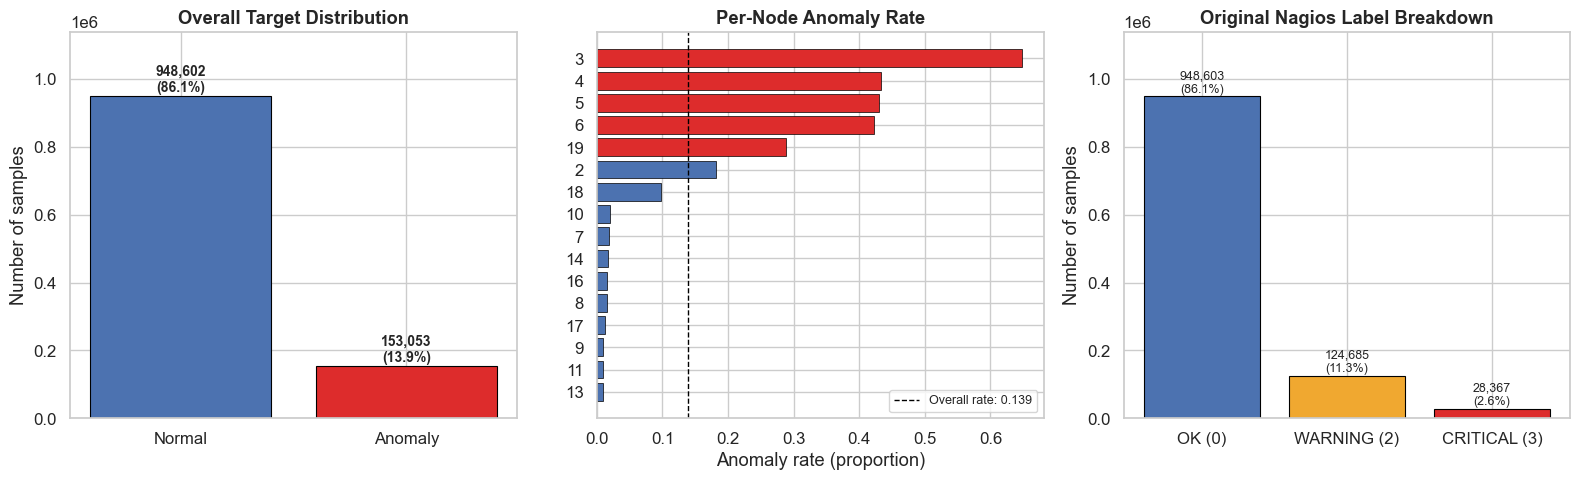

Key takeaway: ~14% anomaly rate — moderately imbalanced.
We will use class_weight='balanced' in the model to compensate.


In [19]:
# =============================================================================
# STEP 4.1 — TARGET CLASS DISTRIBUTION
# =============================================================================
# Visualize the class imbalance in the binary target (next-window anomaly).
# This is critical because:
#   - Heavy imbalance means accuracy is misleading (a model predicting "always
#     normal" gets ~86% accuracy but catches zero anomalies)
#   - We'll need class weighting or resampling in the model (Step 10)
#   - The paper must report this to justify evaluation metric choices

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Overall class balance (bar chart) ---
ax = axes[0]
counts = y.value_counts().sort_index()
bars = ax.bar(
    [CLASS_LABELS[i] for i in counts.index],
    counts.values,
    color=[CLASS_COLORS[i] for i in counts.index],
    edgecolor="black",
    linewidth=0.8
)
# Add count labels on bars
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f"{count:,}\n({count/len(y)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Overall Target Distribution", fontweight="bold")
ax.set_ylabel("Number of samples")
ax.set_ylim(0, counts.max() * 1.2)

# --- Plot 2: Per-node anomaly rate (horizontal bar chart) ---
ax = axes[1]
node_rates = df.groupby("node_id")["target"].mean().sort_values()
colors = ["#DD2C2C" if r > y.mean() * 1.5 else "#4C72B0" for r in node_rates.values]
ax.barh(node_rates.index, node_rates.values, color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(y.mean(), color="black", linestyle="--", linewidth=1, label=f"Overall rate: {y.mean():.3f}")
ax.set_xlabel("Anomaly rate (proportion)")
ax.set_title("Per-Node Anomaly Rate", fontweight="bold")
ax.legend(fontsize=9)

# --- Plot 3: Original 3-class breakdown (stacked bar) ---
ax = axes[2]
nagios_counts = df["value"].astype(int).value_counts().sort_index()
nagios_labels = {0: "OK (0)", 2: "WARNING (2)", 3: "CRITICAL (3)"}
nagios_colors = {0: "#4C72B0", 2: "#F0A830", 3: "#DD2C2C"}
ax.bar(
    [nagios_labels[i] for i in nagios_counts.index],
    nagios_counts.values,
    color=[nagios_colors[i] for i in nagios_counts.index],
    edgecolor="black",
    linewidth=0.8
)
for i, (idx, count) in enumerate(nagios_counts.items()):
    ax.text(i, count + 3000, f"{count:,}\n({count/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Original Nagios Label Breakdown", fontweight="bold")
ax.set_ylabel("Number of samples")
ax.set_ylim(0, nagios_counts.max() * 1.2)

plt.tight_layout()
plt.show()

print("Key takeaway: ~14% anomaly rate — moderately imbalanced.")
print("We will use class_weight='balanced' in the model to compensate.")

## Explanation for the Visualization

This visualization is essentially a "health check" of the 16 compute nodes from the Marconi100 supercomputer. It tells us how often things go wrong and helps justify the machine learning strategy used in the paper.

Here is a breakdown of the three panels:

---

### 1. Overall Target Distribution (The "Big Picture")
This chart shows the balance between "healthy" and "unhealthy" states across the entire dataset.
* **What it shows:** About **$86.1\%$** of the time, the nodes are running normally (Blue). Only **$13.9\%$** of the readings are anomalies (Red).
* **Why it matters:** In data science, we call this **Class Imbalance**. If we built a "lazy" model that simply guessed "Normal" every single time, it would be $86.1\%$ accurate but would fail to catch a single crash. This chart proves why we cannot rely on "Accuracy" alone and must use metrics like **PR-AUC** to see if the model is actually catching those rare red bars.

### 2. Per-Node Anomaly Rate (The "Bad Actors")
Not every node in a supercomputer behaves the same way. This horizontal chart breaks down the anomaly rate for each individual node (labeled 2 through 19).
* **What it shows:** The dashed vertical line is the average anomaly rate ($0.139$ or $13.9\%$). 
* **The Red Bars:** Nodes like **3, 4, 5, and 6** have significantly higher anomaly rates (over $40\%$) compared to the rest. They are the "troublemakers" in this specific rack slice.
* **The Blue Bars:** Most nodes (like 13 or 11) are very stable, with anomaly rates near zero.
* **Why it matters:** This tells us that anomalies aren't just random noise—they are often tied to specific physical hardware. This supports our study's use of **Causal Discovery**, as it suggests there are specific mechanical or workload reasons why certain nodes fail while others don't.

### 3. Original Nagios Label Breakdown (The "Raw Data")
Before the study simplified the problem into a "Yes/No" (Binary) anomaly target, the data came in three categories based on the **Nagios** monitoring standard.
* **OK (0):** The system is healthy ($86.1\%$).
* **WARNING (2):** The system is showing signs of stress but hasn't failed yet ($11.3\%$).
* **CRITICAL (3):** The system has reached a failing state ($2.6\%$).
* **Why it matters:** To create the "Anomaly" group in the first chart, the researchers combined **Warning** and **Critical** states. This shows that most of the "Anomalies" we are predicting are actually "Warnings"—which is exactly what we want for **Predictive Maintenance**. We want to catch the "Yellow" before it turns "Red."

---

### Summary Takeaway
The data is **moderately imbalanced** ($14\%$ vs $86\%$). Because of this, the machine learning model is instructed to "pay extra attention" to the anomalies (using `class_weight='balanced'`). Without these charts, a reviewer might not understand why the model was configured that way.

<br>

---

<br> <br> <br> <br>


C:\Users\Iman\AppData\Local\Temp\ipykernel_19792\3478817260.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hour"] = df["timestamp"].dt.hour


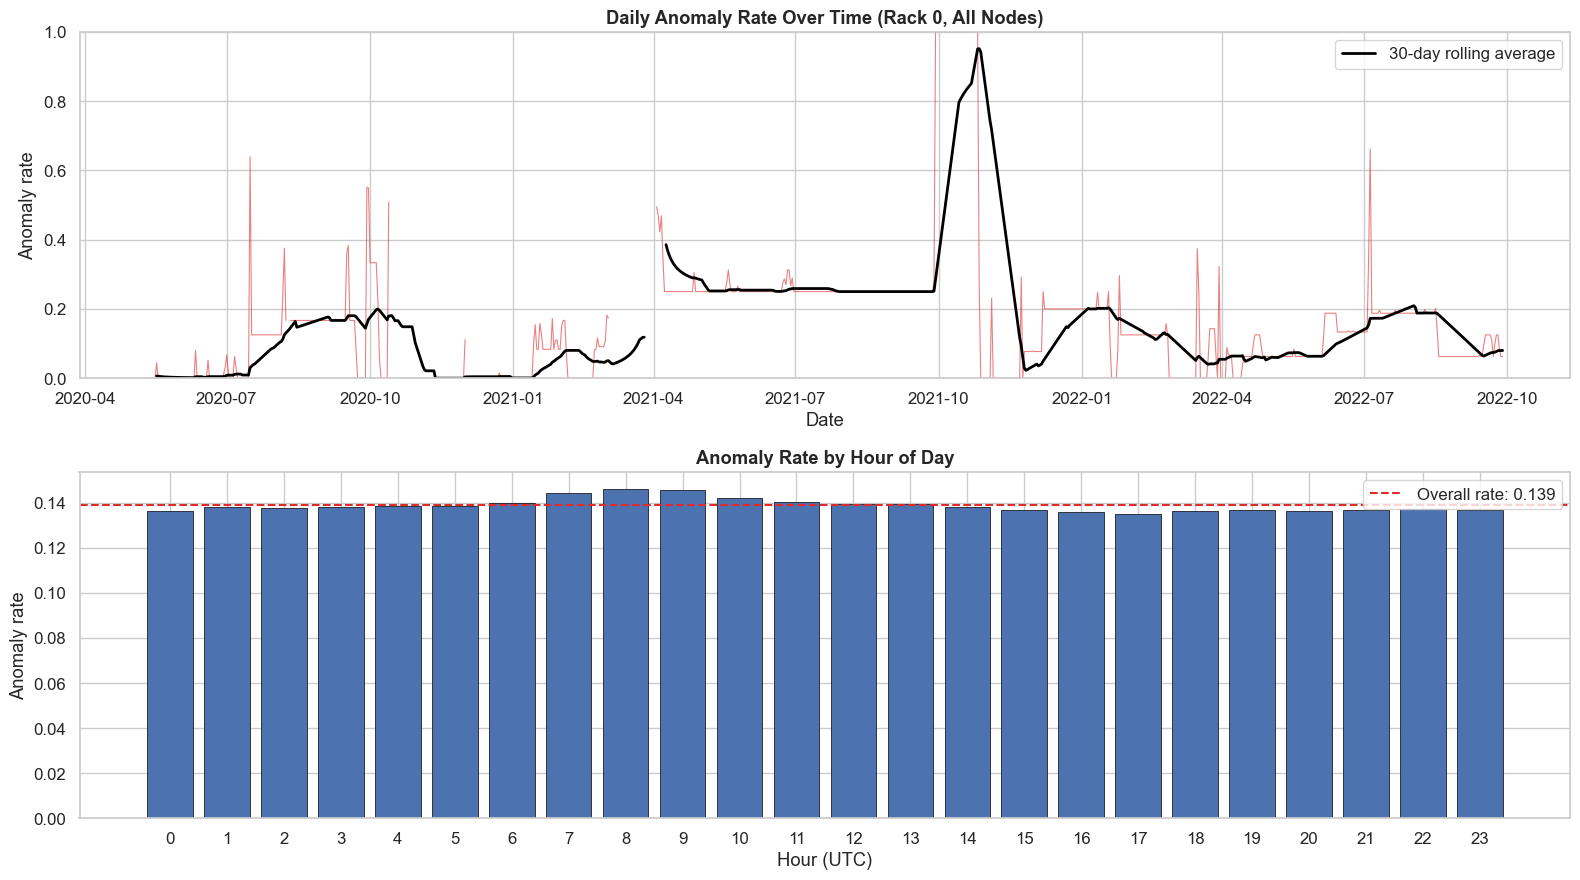

Key takeaways:
  - Anomalies are NOT uniformly distributed over time (temporal structure exists)
  - This confirms we MUST use a temporal train/test split, not random shuffle


In [20]:
# =============================================================================
# STEP 4.2 — TEMPORAL ANOMALY PATTERNS
# =============================================================================
# When do anomalies happen? Understanding temporal structure is important for:
#   - Choosing the right train/test split (temporal, not random!)
#   - Identifying if anomalies cluster in specific time periods
#   - Detecting regime changes (e.g., hardware upgrades, workload shifts)
#
# We plot:
#   1. Daily anomaly rate over the full 2.5-year time span
#   2. Hourly anomaly distribution (time-of-day effect)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# --- Plot 1: Daily anomaly rate over time ---
ax = axes[0]

# Resample to daily granularity: compute anomaly rate per day
daily = df.set_index("timestamp").groupby("node_id")["target"].resample("1D").mean()
daily = daily.reset_index()
daily_avg = daily.groupby("timestamp")["target"].mean()  # average across nodes

ax.plot(daily_avg.index, daily_avg.values, color="#DD2C2C", alpha=0.6, linewidth=0.8)

# Add a 30-day rolling average to see the trend
rolling_30d = daily_avg.rolling(window=30, min_periods=7).mean()
ax.plot(rolling_30d.index, rolling_30d.values, color="black", linewidth=2,
        label="30-day rolling average")

ax.set_title("Daily Anomaly Rate Over Time (Rack 0, All Nodes)", fontweight="bold")
ax.set_ylabel("Anomaly rate")
ax.set_xlabel("Date")
ax.legend()
ax.set_ylim(0, min(1.0, daily_avg.max() * 1.3))

# --- Plot 2: Hourly anomaly distribution ---
ax = axes[1]

# Extract hour-of-day from timestamp
df["hour"] = df["timestamp"].dt.hour
hourly_rate = df.groupby("hour")["target"].mean()

ax.bar(hourly_rate.index, hourly_rate.values, color="#4C72B0", edgecolor="black", linewidth=0.5)
ax.axhline(y.mean(), color="#DD2C2C", linestyle="--", linewidth=1.5,
           label=f"Overall rate: {y.mean():.3f}")
ax.set_title("Anomaly Rate by Hour of Day", fontweight="bold")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Anomaly rate")
ax.set_xticks(range(24))
ax.legend()

plt.tight_layout()
plt.show()

# Clean up the temporary column
df.drop(columns=["hour"], inplace=True)

print("Key takeaways:")
print("  - Anomalies are NOT uniformly distributed over time (temporal structure exists)")
print("  - This confirms we MUST use a temporal train/test split, not random shuffle")


## Explanation of the Visualization


These two charts shift the focus from *which* nodes are failing to *when* they are failing. In the world of High-Performance Computing (HPC), time isn't just a label—it’s a crucial variable that tells us if the system is going through a "rough patch" or if it has a stable daily routine.

---

### 1. Daily Anomaly Rate Over Time (The "History Book")
Think of the top chart as a long-term medical chart for the supercomputer rack over two and a half years. 

* **The Red Lines (Raw Data):** These represent the actual anomaly rate for each individual day. You’ll notice they are very "spiky"—some days are perfectly fine, while others have massive bursts of errors.
* **The Black Line (30-Day Rolling Average):** Because the daily spikes are so chaotic, we use a **Rolling Average** to "smooth out" the noise. It calculates the average of the last 30 days to show us the actual trend.
    * **Insight:** Notice the massive spike around **October 2021**. The system went from a relatively calm period to a state where almost $100\%$ of readings were anomalous for a short time. This is what we call a **Regime Change**. It could indicate a major hardware upgrade, a cooling system failure, or a specific "killer" workload that crashed everything.
* **The Gaps:** The empty spaces (like in early 2021) mean the sensors weren't reporting data. A good model needs to know these gaps exist so it doesn't try to "hallucinate" what happened during the downtime.


---

### 2. Anomaly Rate by Hour of Day (The "Daily Routine")
This bottom chart asks: "Does the supercomputer fail more often when humans are at work?"

* **What it shows:** The blue bars represent the anomaly rate for each hour (0 to 23 UTC). The red dashed line is the overall average of **$13.9\%$**.
* **The Surprise:** Unlike web traffic or electricity usage—which usually skyrocket during the day and drop at night—these bars are almost perfectly flat. Whether it’s 3:00 AM or 3:00 PM, the anomaly rate stays right around $14\%$.
* **The Conclusion:** This suggests that the anomalies are **internal**. They aren't necessarily caused by "human" cycles (like people logging in to start jobs at 9:00 AM). Instead, they are likely driven by the hardware's own physical limits or continuous background workloads.

---

### Why this matters for our Manuscript: The "Temporal Split"

This visualization provides the "smoking gun" evidence for a critical decision we made in your paper: **The Chronological Split.**

In many basic AI projects, researchers "shuffle" their data like a deck of cards before training. **But we can't do that here.** If we randomly shuffled this data, the model might "see" a piece of the big October 2021 spike during training and use that to "predict" October 2021 during testing. That’s called **Data Leakage**—it’s like giving a student the answers to the final exam while they are still studying. 

Because the top chart shows that the system's "mood" changes over years (non-uniform distribution), we **must** split the data by time:
1.  **Train** on the past (e.g., 2020–2021).
2.  **Test** on the future (e.g., 2022).

This ensures our models are actually learning to *predict* the future, not just *remember* the past.


---

<br> <br> <br>






## STEP 4.3 — SENSOR CORRELATION ANALYSIS


When we have hundreds of sensors monitoring a supercomputer, many of them are essentially saying the same thing in different ways. Correlation analysis is the process of measuring how much two sensors "sync up" with each other.

---

### 1. Identifying Redundant Features (The "Double Counting" Problem)
Imagine you have a sensor monitoring a CPU. It reports the **Average Temperature** and the **Minimum Temperature**. 
* **The Reality:** Most of the time, if the average goes up, the minimum goes up too. 
* **The Problem:** If you give both to a machine learning model, you are effectively giving it the same information twice. This makes the model "heavier" and slower without making it any smarter. By finding these correlations, we can remove the redundant ones to keep the model lean.


---

### 2. Understanding Sensor Families (The "Pack" Mentality)
In a supercomputer, sensors often "travel in packs." For example, when a node starts a heavy calculation:
* The **Power Draw** spikes.
* The **Voltage** shifts.
* The **Temperature** rises.
* The **Fan Speed** increases.

These are a **Sensor Family**. Correlation analysis helps us group these together. If we see a "family" all moving at once, it’s a much stronger signal of a major system event than one lone sensor twitching.

---

### 3. The "Disentanglement" Problem for Causal Discovery
This is a critical point for our paper’s specific focus on **Causal Discovery**. 
* **The Puzzle:** If Sensor A and Sensor B are $99\%$ correlated (they move perfectly together), the Causal Discovery algorithm (PCMCI) will have a very hard time figuring out which one is the "Cause" and which one is the "Effect." 
* **The Goal:** We use this analysis to find these "tangled" pairs early. If we know two sensors are nearly identical, we can be more cautious when interpreting the causal graph later.

---

### 4. How we visualize it: The Heatmap
Instead of looking at a table of 50,000 numbers, we use a **Clustered Heatmap**.
* **How it works:** It’s a color-coded grid.Low values indicate "no meaningful relationship", while high values indicate "these two behave almost identically".
* **Clustering:** The grid automatically moves sensors that are "family members" next to each other. This creates visible "blocks" of color on the map, making it easy for a human to see the structure of the entire supercomputer's data at a single glance.



### Summary 
Correlation analysis is like a **pre-flight check**. We are making sure we aren't wasting space with duplicate data, and we are identifying which sensors are "teammates" before we try to figure out the complex causal "rules" that govern the system.



In [21]:
# =============================================================================
# STEP 4.3 — SENSOR CORRELATION ANALYSIS
# =============================================================================
# With 224 sensor features, many will be highly correlated (e.g., the _avg and
# _min of the same sensor). Understanding correlation structure helps:
#   - Identify redundant features (for potential dimensionality reduction)
#   - Understand sensor families (groups that move together)
#   - Interpret causal graphs (highly correlated features are hard to disentangle)
#
# We compute the correlation matrix and visualize:
#   1. A clustered heatmap of the full correlation matrix
#   2. The top features most correlated with the target

# --- Part A: Top features correlated with the target ---
print("=" * 60)
print("STEP 4.3 — Sensor correlation analysis")
print("=" * 60)

# Compute correlation of each feature with the target
target_corr = X.corrwith(y).abs().sort_values(ascending=False)

print("Top 20 features most correlated with target (|Pearson r|):")
for i, (col, corr) in enumerate(target_corr.head(20).items(), 1):
    print(f"    {i:>2}. {col:<30s}  r={corr:.4f}")

print(f"Bottom 5 features (least correlated with target):")
for col, corr in target_corr.tail(5).items():
    print(f"      {col:<30s}  r={corr:.4f}")

STEP 4.3 — Sensor correlation analysis
Top 20 features most correlated with target (|Pearson r|):
     1. p0_io_power_avg                 r=0.2425
     2. p0_io_power_max                 r=0.2387
     3. p0_io_power_min                 r=0.2376
     4. p0_vdd_temp_min                 r=0.1690
     5. p0_vdd_temp_avg                 r=0.1667
     6. p0_vdd_temp_max                 r=0.1641
     7. p0_power_min                    r=0.1629
     8. gpu4_core_temp_min              r=0.1464
     9. gpu4_core_temp_avg              r=0.1449
    10. p0_power_avg                    r=0.1381
    11. ps0_output_volta_max            r=0.1381
    12. gpu4_core_temp_max              r=0.1345
    13. ps0_output_volta_min            r=0.1290
    14. ps0_output_volta_avg            r=0.1246
    15. ps1_output_volta_max            r=0.1240
    16. ps1_output_volta_min            r=0.1195
    17. ps1_output_volta_avg            r=0.1136
    18. dimm15_temp_max                 r=0.1123
    19. dimm15_temp_

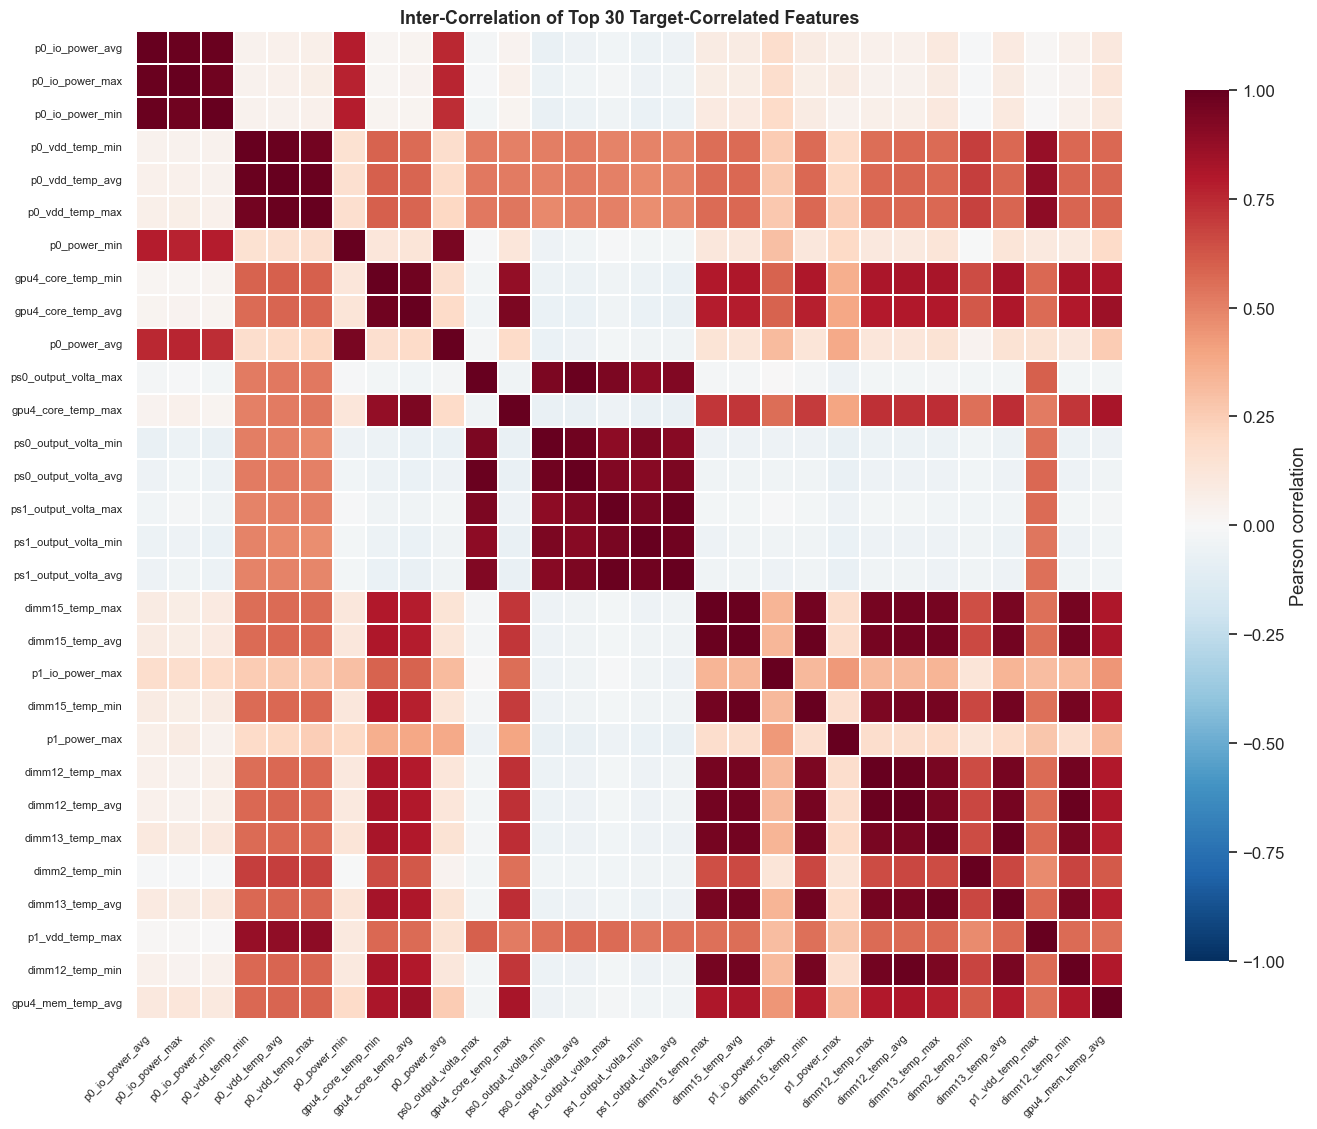

Key takeaways:
  - Bright red blocks = sensor groups that move together (redundant)
  - These clusters inform feature grouping for causal analysis
  - High inter-correlation within a group means we can pick a representative


In [22]:
# =============================================================================
# STEP 4.3b — CLUSTERED CORRELATION HEATMAP (top features)
# =============================================================================
# Plotting a 224x224 heatmap is unreadable. Instead, we take the top 30
# features most correlated with the target and plot their inter-correlations.
# This reveals which high-signal features are redundant with each other.

# Select top 30 features by target correlation
target_corr_abs = X.corrwith(y).abs().sort_values(ascending=False)
top_features = target_corr_abs.head(30).index.tolist()

# Compute the correlation matrix for just these 30 features
corr_matrix = X[top_features].corr()

# Plot clustered heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=False,           # too many cells for annotations
    cmap="RdBu_r",         # red = positive, blue = negative correlation
    center=0,              # center the colormap at 0
    vmin=-1, vmax=1,       # full correlation range
    linewidths=0.3,
    linecolor="white",
    square=True,
    ax=ax,
    cbar_kws={"label": "Pearson correlation", "shrink": 0.8}
)
ax.set_title("Inter-Correlation of Top 30 Target-Correlated Features", fontweight="bold", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print("Key takeaways:")
print("  - Bright red blocks = sensor groups that move together (redundant)")
print("  - These clusters inform feature grouping for causal analysis")
print("  - High inter-correlation within a group means we can pick a representative")

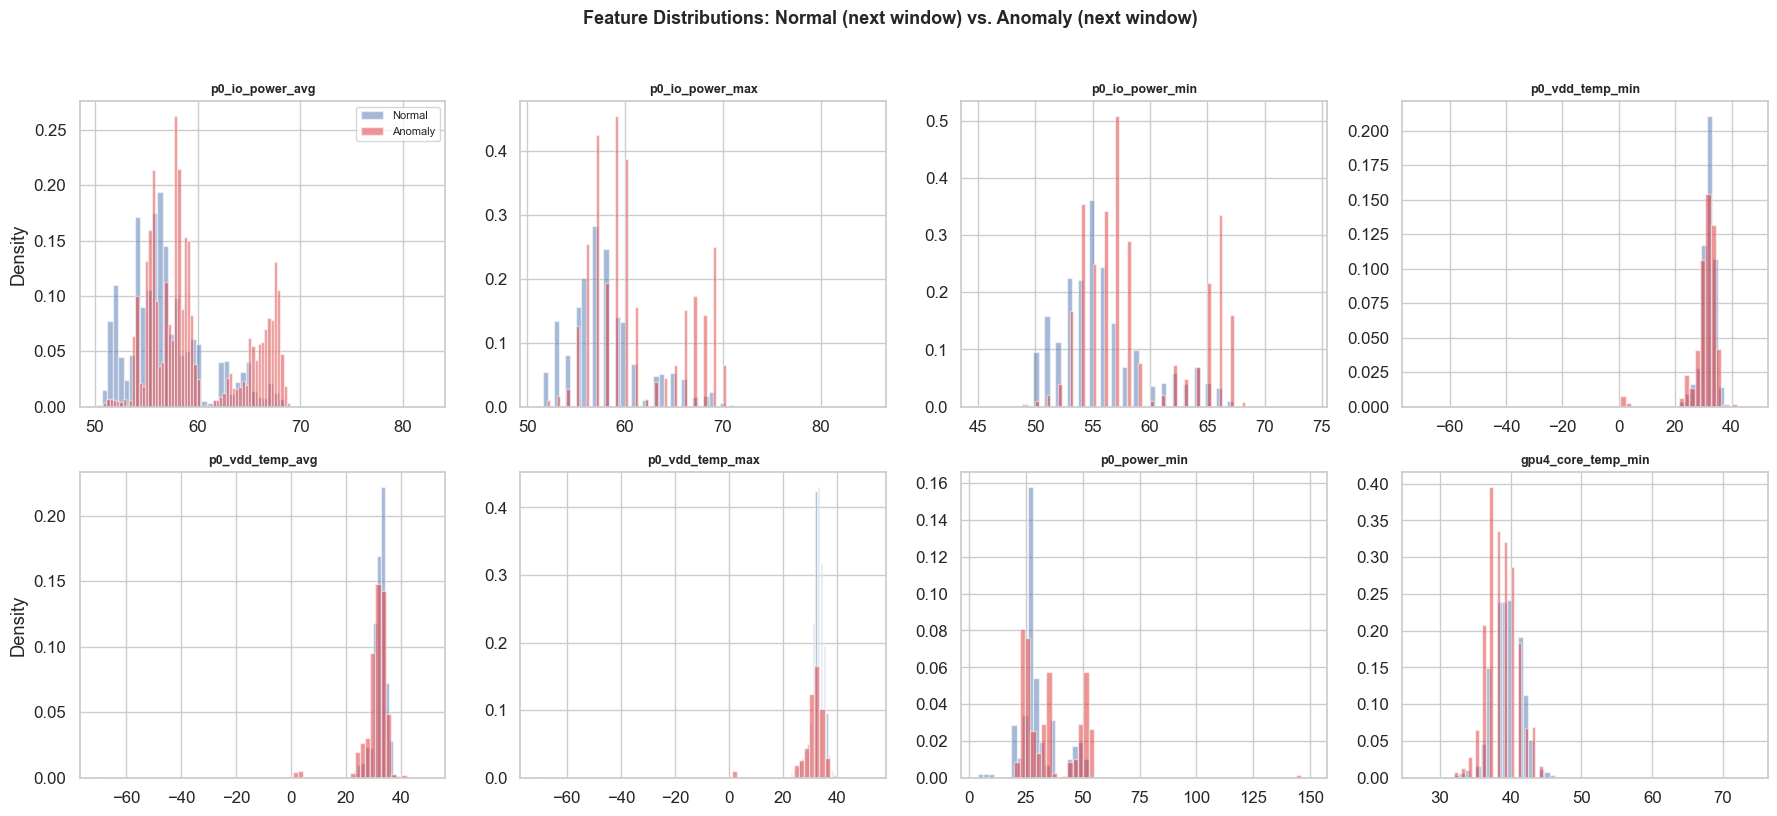

Key takeaway: features with clearly separated distributions (bimodal or shifted)
are strong candidates for both prediction AND causal analysis.

  Step 4 (EDA) complete.


In [23]:
# =============================================================================
# STEP 4.4 — FEATURE DISTRIBUTIONS: NORMAL vs. ANOMALY
# =============================================================================
# For the top 8 target-correlated features, plot the distribution of values
# when the NEXT window is normal vs. anomaly. This shows which sensors
# already "look different" before an anomaly — exactly what the predictive
# model will exploit.

# Pick top 8 features
top8 = target_corr_abs.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(top8):
    ax = axes[i]

    # Sample for plotting speed (KDE on 1M+ points is slow)
    sample_n = min(50_000, len(df))
    sample_idx = df.sample(sample_n, random_state=42).index

    for cls in [0, 1]:
        mask = (y.loc[sample_idx] == cls)
        vals = X.loc[sample_idx].loc[mask, col]
        ax.hist(vals, bins=60, alpha=0.5, density=True,
                color=CLASS_COLORS[cls], label=CLASS_LABELS[cls])

    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Density" if i % 4 == 0 else "")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle("Feature Distributions: Normal (next window) vs. Anomaly (next window)", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Key takeaway: features with clearly separated distributions (bimodal or shifted)")
print("are strong candidates for both prediction AND causal analysis.")
print("\n  Step 4 (EDA) complete.")

## Explanation for the Visualization


This step is essentially the "Behavioral Profile" stage of the study. We’ve identified the 8(it can be any number) most important sensors ; now, we’re looking to see exactly how their behavior changes right before the system hits a snag. 

By comparing the "Normal" state to the "Pre-Anomaly" state, we are finding the "fingerprints" of a coming crash.

---

## 1. What the Axes Define
To read these plots correctly, we need to understand what the two directions represent:

* **X-axis (The Horizontal Bottom): Sensor Reading Value**
    This is the raw number the sensor is reporting. For example, in the `p0_io_power_avg` plot, the values range from roughly **50 to 85**. This might represent Watts, Degrees Celsius, or Volts depending on the sensor name.
* **Y-axis (The Vertical Side): Probability Density**
    This represents how "common" a specific value is. 
    * A **high peak** means the sensor stays at that value very often. 
    * A **low area** means that value is rare. 
    * *Note:* We use "Density" instead of "Raw Count" because there are way more Normal samples than Anomaly samples. Density scales them so you can compare the **shapes** of the two groups fairly.

---

## 2. Breaking Down the Visual Patterns
When you look at the image you provided, you are looking for **separation**.

### The "Smoking Gun" (Shifted Distributions)
Look at **`p0_io_power_avg`** (the first plot). 
* The **Blue bars (Normal)** are clustered mostly between **50 and 60**. 
* The **Red bars (Anomaly)** have a huge second "mountain" between **60 and 70**.
* **Conclusion:** If the power draw jumps into that 60–70 range, an anomaly is very likely about to happen. This is a perfect feature for a predictive model to exploit.

### The "Useless" Signal (Overlapping Distributions)
Look at **`gpu4_core_temp_min`** (the last plot). 
* The Blue and Red mountains are almost perfectly on top of each other.
* **Conclusion:** Even though this sensor is correlated with the target, it doesn't "look" different enough right before an anomaly to be a reliable early warning sign on its own.

---

## 3. Step-by-Step Code Logic
Here is what the code is actually doing behind the scenes:

1.  **Selection:** It grabs the **Top 8** features that have the strongest mathematical relationship with your anomaly target.
2.  **Sampling:** It picks **50,000 random rows** instead of using all 1 million+. This makes the plotting finish in seconds rather than minutes without losing the overall "picture."
3.  **Masking:** it separates the data into two piles: "Everything is fine" (Class 0) and "An anomaly is coming next" (Class 1).
4.  **Histogramming:** It draws the bars. 
    * `bins=60` means it chops the sensor range into 60 small buckets.
    * `alpha=0.5` makes the bars see-through so you can see where the red and blue overlap.
5.  **Titling:** It labels each plot with the sensor name so you know exactly which hardware component you're looking at.

---

## 4. Why this matters for the Paper
In your manuscript, this visualization justifies **why** your LightGBM model works. You aren't just telling the reader the model is $80\%$ accurate; you are **showing** them the physical evidence (the shifts in power and temperature) that the model is using to make its decisions. 


**Quick Tip:** In your "Main Findings" section, you can point to the `p0_io_power` plots as evidence that power-domain fluctuations are a primary "symptom" of upcoming system instability.

Does the clear separation in the power-related features (the first three plots) confirm your hunch that workload-driven power spikes are the main cause of these anomalies?






<br> <br> <br> <br>


## Step 5 — Temporal Train / Test Split

**Goal:** Split the data into training and test sets using a **temporal cutoff**,
not a random shuffle.

### Why temporal, not random?

In time-series / predictive-maintenance settings, a random split causes **data leakage**:
- A row from 2021-06-15 might land in the training set while a row from 2021-06-14
  ends up in the test set. The model effectively "sees the future" during training.
- This inflates test metrics and gives a false sense of performance.

A temporal split mimics real deployment: the model is trained on **past** data and
evaluated on **future** data it has never seen. We use an 80/20 split by time:
the first 80% of each node's timeline for training, the last 20% for testing.

In [24]:
# =============================================================================
# STEP 5.0 — COMPUTE THE TEMPORAL SPLIT POINT
# =============================================================================
# We find the 80th-percentile timestamp across the entire dataset, then assign
# every row before that timestamp to train and every row after to test.
#
# Why a GLOBAL cutoff (not per-node)?
#   - A single cutoff date ensures that ALL test data comes from the same
#     future period. This is more realistic: in production, you deploy the
#     model at one point in time, and everything after that is "unseen."
#   - Per-node cutoffs would mean different nodes have different train/test
#     boundaries, making cross-node evaluation inconsistent.

print("=" * 60)
print("STEP 5.0 — Computing temporal split point")
print("=" * 60)

# Sort by timestamp (should already be sorted, but let's be explicit)
df = df.sort_values(["node_id", "timestamp"]).reset_index(drop=True)

# Find the 80th percentile timestamp
TRAIN_FRACTION = 0.80
all_timestamps = df["timestamp"].sort_values()
split_idx = int(len(all_timestamps) * TRAIN_FRACTION)
split_timestamp = all_timestamps.iloc[split_idx]

print(f"\n  Dataset time range:  {df['timestamp'].min()}  to  {df['timestamp'].max()}")
print(f"  Train fraction:      {TRAIN_FRACTION:.0%}")
print(f"  Split timestamp:     {split_timestamp}")
print(f"  Split index:         {split_idx:,} / {len(df):,}")

STEP 5.0 — Computing temporal split point

  Dataset time range:  2020-05-11 14:45:00+00:00  to  2022-09-28 21:30:00+00:00
  Train fraction:      80%
  Split timestamp:     2022-05-05 19:00:00+00:00
  Split index:         881,324 / 1,101,655


In [25]:
# =============================================================================
# STEP 5.1 — ASSIGN TRAIN / TEST LABELS AND BUILD SPLITS
# =============================================================================
# Every row with timestamp < split_timestamp goes to train,
# every row with timestamp >= split_timestamp goes to test.
#
# We create the actual X_train, X_test, y_train, y_test arrays that the
# models will consume. We also keep the full df's train/test mask for later
# analysis (e.g., plotting predictions over time).

# Boolean masks on the full DataFrame
train_mask = df["timestamp"] < split_timestamp
test_mask  = df["timestamp"] >= split_timestamp

# Build feature/target splits
X_train = X.loc[train_mask].copy()
X_test  = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test  = y.loc[test_mask].copy()

print("=" * 60)
print("STEP 5.1 — Train / Test split summary")
print("=" * 60)

print(f"\n  Train set:")
print(f"    Rows:          {len(X_train):>10,}")
print(f"    Time range:    {df.loc[train_mask, 'timestamp'].min()}  to  {df.loc[train_mask, 'timestamp'].max()}")
print(f"    Anomaly rate:  {y_train.mean():.4f}  ({y_train.mean()*100:.2f}%)")
print(f"    Class 0:       {(y_train == 0).sum():>10,}")
print(f"    Class 1:       {(y_train == 1).sum():>10,}")

print(f"\n  Test set:")
print(f"    Rows:          {len(X_test):>10,}")
print(f"    Time range:    {df.loc[test_mask, 'timestamp'].min()}  to  {df.loc[test_mask, 'timestamp'].max()}")
print(f"    Anomaly rate:  {y_test.mean():.4f}  ({y_test.mean()*100:.2f}%)")
print(f"    Class 0:       {(y_test == 0).sum():>10,}")
print(f"    Class 1:       {(y_test == 1).sum():>10,}")

# Sanity checks
assert len(X_train) + len(X_test) == len(X), "Train + Test != Total!"
assert X_train.isna().sum().sum() == 0, "NaN in X_train!"
assert X_test.isna().sum().sum() == 0, "NaN in X_test!"
print(f"\n  [PASS] No data leakage — all test timestamps are after all train timestamps")
print(f"  [PASS] No NaN values in either split")
print(f"\n  Step 5 complete. Ready for modeling.")

STEP 5.1 — Train / Test split summary

  Train set:
    Rows:             881,312
    Time range:    2020-05-11 14:45:00+00:00  to  2022-05-05 18:45:00+00:00
    Anomaly rate:  0.1423  (14.23%)
    Class 0:          755,923
    Class 1:          125,389

  Test set:
    Rows:             220,343
    Time range:    2022-05-05 19:00:00+00:00  to  2022-09-28 21:30:00+00:00
    Anomaly rate:  0.1255  (12.55%)
    Class 0:          192,679
    Class 1:           27,664

  [PASS] No data leakage — all test timestamps are after all train timestamps
  [PASS] No NaN values in either split

  Step 5 complete. Ready for modeling.


<br> <br> <br>



## Step 6 — Lagged & Rolling Features (Temporal Feature Engineering)

**Goal:** Enrich the feature set with temporal dynamics so the model (and causal
discovery) can reason about *trends* and *recent history*, not just the current snapshot.

### Why lagged features?

The raw sensor columns represent the system state at time `t`. But anomalies often
build up over multiple windows: temperature gradually rises, power creeps up, fan
speed increases in response. Without lag features, the model is blind to these trends.

### What we create

For a **compact subset** of the most informative sensors (top 10 by target correlation),
we generate:
- **Lag-1** (`_lag1`): value at `t-1` (previous 15-min window)
- **Lag-2** (`_lag2`): value at `t-2` (30 minutes ago)
- **Rolling mean** (`_rmean4`): average over the last 4 windows (1 hour)
- **Rolling std** (`_rstd4`): variability over the last 4 windows
- **Delta** (`_delta1`): difference `x[t] - x[t-1]` (short-term rate of change)

We only create lags for the top 10 sensors (not all 224) to avoid an explosion of
features that would slow training and make causal discovery intractable.

### Important: lags are computed WITHIN each node

We use `groupby('node_id')` for all lag/rolling operations to prevent
cross-node leakage (the last row of node A must not borrow from node B).


### Notes:

- **X.corrwith(y).abs():** This calculates the "Pearson Correlation," which measures how closely a sensor's readings follow the patterns of the anomalies. The .abs() (absolute value) ensures we find strong relationships regardless of whether the sensor value goes up or down when an anomaly occurs.

- **sort_values(ascending=False):** This ranks the sensors from most relevant to least relevant, so the best "early warning" indicators are at the top of the list.

- **TOP_K_FOR_LAGS = 10:** This sets a limit. We only want to look at the top 10 sensors.

In [26]:
# =============================================================================
# STEP 6.0 — SELECT TOP SENSORS FOR LAG ENGINEERING
# =============================================================================
# We pick the top 10 sensors by absolute Pearson correlation with the target.
# These are the sensors most likely to carry temporal predictive signal.
# Using only 10 base sensors keeps the lag feature count manageable:
#   10 sensors x 5 lag types = 50 new features (on top of the 224 raw ones).

print("=" * 60)
print("STEP 6.0 — Selecting sensors for lag feature engineering")
print("=" * 60)

# Correlate each sensor with the target (computed on the full df, pre-split)

target_corr_for_lags = X.corrwith(y).abs().sort_values(ascending=False)

# Pick top 10 sensors
TOP_K_FOR_LAGS = 10
lag_base_features = target_corr_for_lags.head(TOP_K_FOR_LAGS).index.tolist()

print(f"\n  Top {TOP_K_FOR_LAGS} sensors selected for lag engineering:")
for i, feat in enumerate(lag_base_features, 1):
    print(f"    {i:>2}. {feat:<30s}  (|r| = {target_corr_for_lags[feat]:.4f})")


STEP 6.0 — Selecting sensors for lag feature engineering

  Top 10 sensors selected for lag engineering:
     1. p0_io_power_avg                 (|r| = 0.2425)
     2. p0_io_power_max                 (|r| = 0.2387)
     3. p0_io_power_min                 (|r| = 0.2376)
     4. p0_vdd_temp_min                 (|r| = 0.1690)
     5. p0_vdd_temp_avg                 (|r| = 0.1667)
     6. p0_vdd_temp_max                 (|r| = 0.1641)
     7. p0_power_min                    (|r| = 0.1629)
     8. gpu4_core_temp_min              (|r| = 0.1464)
     9. gpu4_core_temp_avg              (|r| = 0.1449)
    10. p0_power_avg                    (|r| = 0.1381)


<br> <br> <br>


## STEP 6.1 — CREATE LAGGED AND ROLLING FEATURES


This step is where the dataset becomes "time-aware." In a standard dataset, the model only sees what is happening right now; however, to predict an anomaly in the future, the model needs to understand how the system has been behaving leading up to this moment.

### Clear Explanation of Lagged and Rolling Features

Imagine you are trying to predict if a car's engine will overheat. Knowing the temperature is $90^\circ\text{C}$ right now is helpful, but it is much more useful to know if it was $60^\circ\text{C}$ ten minutes ago and is rising rapidly.

This code creates five specific types of "historical" features for the top 10 sensors:

1.  **Lag-1 ($t-1$):** This is the value from the previous 15-minute window. It tells the model what the sensor read "just a moment ago."
2.  **Lag-2 ($t-2$):** This is the value from 30 minutes ago. It provides a slightly deeper look into the past.
    * 
3.  **Rolling Mean (rmean4):** This is the average value over the last four windows (the last hour). It helps "smooth out" random spikes so the model can see the general trend.
4.  **Rolling Standard Deviation (rstd4):** This measures how much the values have been "bouncing around" over the last hour. High variability often signals that a system is becoming unstable.
    * 
5.  **Delta (delta1):** This is the "First Difference"—the current value minus the previous value[cite: 136]. It tells the model the direction of change: is the sensor reading rising or falling?

**Why "Groupby Node"?**
The code performs these calculations independently for each computer node. This prevents **"cross-node leakage,"** which is a serious error where the history of "Node A" is accidentally used to fill in a gap for "Node B".

**Why Drop Rows?**
At the very beginning of the day, there is no "history." For the first 15 minutes, there is no "15 minutes ago" to look at. The code removes these incomplete rows to ensure the model only learns from perfectly complete information.

---

### Analysis: Where This is Discussed in the Paper

* This process is a core component of the methodology and is discussed in detail in **Section 3.1: Data Acquisition, Outcome Definition, and Feature Engineering**.

* **Temporal Descriptors:** The paper explicitly lists these five exact features: "lag-1, lag-2, rolling mean over the last four windows, rolling standard deviation over the last four windows, and first difference"
* **Preventing Leakage:** The manuscript notes that the "grouped shift avoids cross-node leakage," ensuring that data from one node does not interfere with another.
* **Resulting Dataset Size:** This step adds exactly 50 temporal features to the data. This is why the final experimental setup described in **Section 4.1** contains 258 features (208 original sensors plus these 50 new time-based ones).
* **Row Removal:** In **Section 4.1**, the paper mentions that the final training and test sets are calculated "after lag-related row removal," which corresponds to the `df.dropna()` command in your code.

By using these features, the paper argues that the workflow creates a "compact but dynamic representation" that allows for both high-performance prediction and sophisticated causal analysis.


In [27]:
# =============================================================================
# STEP 6.1 — CREATE LAGGED AND ROLLING FEATURES
# =============================================================================
# For each of the top 10 sensors, we create 5 temporal features:
#   1. lag1:   x[t-1]                — what was the value 15 min ago?
#   2. lag2:   x[t-2]                — what was it 30 min ago?
#   3. rmean4: rolling mean(4)       — average over the last hour
#   4. rstd4:  rolling std(4)        — variability over the last hour
#   5. delta1: x[t] - x[t-1]        — is it rising or falling?
#
# All operations are grouped by node_id to prevent cross-node leakage.
# The first 2 rows of each node will have NaN for lag2 (no history) —
# we'll handle those after creating all features.

print("=" * 60)
print("STEP 6.1 — Creating lagged and rolling features")
print("=" * 60)

new_feature_names = []

for feat in lag_base_features:
    grouped = df.groupby("node_id")[feat]

    # Lag-1: previous window's value
    col_lag1 = f"{feat}_lag1"
    df[col_lag1] = grouped.shift(1)
    new_feature_names.append(col_lag1)

    # Lag-2: two windows ago
    col_lag2 = f"{feat}_lag2"
    df[col_lag2] = grouped.shift(2)
    new_feature_names.append(col_lag2)

    # Rolling mean over last 4 windows (1 hour)
    # min_periods=1 so we get values even for early rows
    col_rmean = f"{feat}_rmean4"
    df[col_rmean] = grouped.transform(
        lambda s: s.rolling(window=4, min_periods=1).mean()
    )
    new_feature_names.append(col_rmean)

    # Rolling std over last 4 windows
    col_rstd = f"{feat}_rstd4"
    df[col_rstd] = grouped.transform(
        lambda s: s.rolling(window=4, min_periods=1).std()
    )
    new_feature_names.append(col_rstd)

    # Delta: x[t] - x[t-1] (rate of change)
    col_delta = f"{feat}_delta1"
    df[col_delta] = df[feat] - df[col_lag1]
    new_feature_names.append(col_delta)

print(f"  Created {len(new_feature_names)} new temporal features from {len(lag_base_features)} base sensors")
print(f"  Feature types: lag1, lag2, rmean4, rstd4, delta1")

# --- Handle NaN introduced by lagging ---
# Lag-1 creates NaN for the first row of each node
# Lag-2 creates NaN for the first two rows of each node
# Delta creates NaN where lag1 is NaN
# We drop these rows (a tiny fraction of total data)
rows_before = len(df)
df = df.dropna(subset=new_feature_names).reset_index(drop=True)
rows_after = len(df)

print(f"\n  Rows dropped due to lag NaN: {rows_before - rows_after:,}")
print(f"  Rows remaining: {rows_after:,}")


STEP 6.1 — Creating lagged and rolling features


C:\Users\Iman\AppData\Local\Temp\ipykernel_19792\1442744984.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_lag1] = grouped.shift(1)
C:\Users\Iman\AppData\Local\Temp\ipykernel_19792\1442744984.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_lag2] = grouped.shift(2)
C:\Users\Iman\AppData\Local\Temp\ipykernel_19792\1442744984.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

  Created 50 new temporal features from 10 base sensors
  Feature types: lag1, lag2, rmean4, rstd4, delta1

  Rows dropped due to lag NaN: 32
  Rows remaining: 1,101,623


In [28]:
# =============================================================================
# STEP 6.2 — REBUILD X, y, AND FEATURE NAMES WITH LAG FEATURES
# =============================================================================
# After adding lag features and dropping NaN rows, we must rebuild X and y
# to include the new temporal features.

# Update sensor_cols to include the new lag features
sensor_cols = sensor_cols + new_feature_names

# Rebuild X and y from the updated df
X = df[sensor_cols].copy()
y = df["target"].copy()

# Update feature_names
feature_names = list(X.columns)

# Also rebuild the train/test masks (row indices changed after dropna)
train_mask = df["timestamp"] < split_timestamp
test_mask  = df["timestamp"] >= split_timestamp

X_train = X.loc[train_mask].copy()
X_test  = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test  = y.loc[test_mask].copy()

# Recompute scale_pos_weight
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print("=" * 60)
print("STEP 6.2 — Rebuilt X, y, and train/test splits with lag features")
print("=" * 60)
print(f"\n  Total features:     {len(feature_names)}  (was 224, now +{len(new_feature_names)} lag features)")
print(f"  Original sensors:   {len(feature_names) - len(new_feature_names)}")
print(f"  Lag features:       {len(new_feature_names)}")
print(f"  X_train shape:      {X_train.shape}")
print(f"  X_test shape:       {X_test.shape}")
print(f"  NaN in X_train:     {X_train.isna().sum().sum()}")
print(f"  NaN in X_test:      {X_test.isna().sum().sum()}")
print(f"  scale_pos_weight:   {scale_pos_weight:.2f}")


STEP 6.2 — Rebuilt X, y, and train/test splits with lag features

  Total features:     258  (was 224, now +50 lag features)
  Original sensors:   208
  Lag features:       50
  X_train shape:      (881280, 258)
  X_test shape:       (220343, 258)
  NaN in X_train:     0
  NaN in X_test:      0
  scale_pos_weight:   6.03


<br> <br> <br>

## Step 7 — Predictive Modeling: LightGBM vs. CatBoost vs. XGBoost

**Goal:** Train three gradient-boosted tree models and compare their performance
on the temporal test set to find the best predictor for next-window anomaly.

### Why gradient-boosted trees?

1. **State-of-the-art for tabular data** — GBDTs consistently outperform deep learning
   on structured/tabular datasets (Grinsztajn et al., 2022).
2. **Handle mixed scales** — no feature scaling needed (tree splits are rank-based).
3. **Handle imbalance** — all three support `scale_pos_weight` or class weighting.
4. **Fast training** — all three are highly optimized C/C++ implementations.
5. **Interpretable** — native feature importance + SHAP compatibility for Step 7.

### Evaluation metrics

For imbalanced binary classification, we report:
- **ROC-AUC** — measures ranking quality across all thresholds (primary metric)
- **PR-AUC** (Average Precision) — better than ROC-AUC when positive class is rare
- **F1-score** — harmonic mean of precision and recall at default 0.5 threshold
- **Precision / Recall** — to understand the tradeoff
- **Confusion matrix** — to see false positive / false negative counts

### Hyperparameters

We use reasonable defaults with `scale_pos_weight` to handle class imbalance.
This is a **work-in-progress paper** — exhaustive hyperparameter tuning is out of scope,
but the defaults are strong baselines for GBDTs.

---

This step sets up the mathematical tools and strategies needed to train the anomaly prediction models. It focuses on how to handle "lopsided" data (imbalance) and how to measure if the models are actually doing a good job.

### 1. Handling the "Needle in a Haystack" (Class Imbalance)
In the supercomputer data, anomalies are relatively rare, making up only about 14% of the observations. 
To prevent the model from simply ignoring these rare events, the code calculates a **`scale_pos_weight`**. 

* **How it works:** It divides the number of "Normal" samples by the number of "Anomaly" samples. 
* **The Result:** If there are 6 times as many normal samples as anomalies, the model is told that every anomaly it misses is 6 times more "painful" than missing a normal sample[cite: 146]. This forces the model to prioritize catching the anomalies.

### 2. Measuring Success: The Evaluation Metrics
The `evaluate_model` function uses several standard "tests" to see how well the model performed on the unseen test data:

* **ROC-AUC and PR-AUC:** These measure the model's overall ability to rank anomalies higher than normal states[cite: 147]. As the paper notes, **PR-AUC** is the more critical metric here because it is harder to "cheat" on when the data is imbalanced.

* **The Confusion Matrix:** This is a 2x2 table that shows exactly where the model got confused:
    * **True Positives (TP):** Anomalies correctly caught.
    * **False Positives (FP):** "False Alarms"—the model predicted a crash, but the system was fine.
    * **False Negatives (FN):** The most dangerous error—the system crashed, but the model missed it.

* **Precision and Recall:** **Precision** asks, "When the model sounded the alarm, how often was it right?" **Recall** asks, "Of all the actual crashes that happened, how many did the model catch?"[cite: 180, 183].

---

### Analysis: Where This is Discussed in the Paper
The setup and logic in this code are discussed primarily in **Section 3.2: Chronological learning protocol and predictive models** (page 5) and **Section 4.1: Experimental setup** (page 6).

* **Model Selection:** The paper lists the specific "three gradient-boosted tree families" imported in the code: LightGBM, CatBoost, and XGBoost.
* **Weighting Logic:** Section 3.2 explicitly describes the `scale_pos_weight` strategy, noting that the "imbalance weight is computed from the training set as the ratio of negative to positive samples".
* **Metric Justification:** The paper provides a detailed justification for why the code calculates **PR-AUC**, explaining that it "more accurately reflects performance under imbalance" compared to ROC-AUC[cite: 147, 148].
* **Results Presentation:** The metrics calculated by this helper function (ROC-AUC, PR-AUC, F1, Precision, and Recall) are the exact columns used in **Table 2** (page 6) to compare the performance of the three models.

By formalizing these evaluation steps, the workflow ensures that the comparison between the models is rigorous and directly addresses the operational challenges of HPC monitoring.





In [29]:
# =============================================================================
# STEP 7.0 — IMPORTS & HELPER FUNCTIONS
# =============================================================================

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import time

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Compute the class imbalance ratio for scale_pos_weight
# scale_pos_weight = n_negative / n_positive
# This tells the model to "pay more attention" to the minority (anomaly) class.
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print("=" * 60)
print("STEP 7.0 — Model training setup")
print("=" * 60)
print(f"\n  Class balance in training set:")
print(f"    Negative (normal):   {n_neg:>10,}")
print(f"    Positive (anomaly):  {n_pos:>10,}")
print(f"    scale_pos_weight:    {scale_pos_weight:.2f}")
print(f"\n  This means the model treats each anomaly sample as {scale_pos_weight:.1f}x more")
print(f"  important than a normal sample during training.")


def evaluate_model(model_name, y_true, y_pred, y_proba):
    """Compute and print all evaluation metrics for a trained model."""
    print(f"\n  {'─' * 50}")
    print(f"  {model_name} — Test Set Results")
    print(f"  {'─' * 50}")

    # Probability-based metrics (threshold-independent)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc  = average_precision_score(y_true, y_proba)

    # Threshold-based metrics (at default 0.5 cutoff)
    f1   = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"    ROC-AUC:           {roc_auc:.4f}")
    print(f"    PR-AUC (Avg Prec): {pr_auc:.4f}")
    print(f"    F1-score:          {f1:.4f}")
    print(f"    Precision:         {prec:.4f}")
    print(f"    Recall:            {rec:.4f}")
    print(f"\n    Confusion Matrix:")
    print(f"                    Predicted")
    print(f"                  Neg      Pos")
    print(f"      Actual Neg  {cm[0,0]:>7,}  {cm[0,1]:>7,}")
    print(f"      Actual Pos  {cm[1,0]:>7,}  {cm[1,1]:>7,}")

    return {
        "model": model_name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": prec,
        "recall": rec,
        "tn": cm[0, 0], "fp": cm[0, 1],
        "fn": cm[1, 0], "tp": cm[1, 1],
    }


print("\n  Helper function 'evaluate_model' defined.")
print("  Ready to train models.")

STEP 7.0 — Model training setup

  Class balance in training set:
    Negative (normal):      755,891
    Positive (anomaly):     125,389
    scale_pos_weight:    6.03

  This means the model treats each anomaly sample as 6.0x more
  important than a normal sample during training.

  Helper function 'evaluate_model' defined.
  Ready to train models.


In [30]:
# =============================================================================
# STEP 7.1 — TRAIN LIGHTGBM
# =============================================================================
# LightGBM uses histogram-based splitting and leaf-wise growth, making it
# very fast on large datasets. It's often the go-to GBDT for tabular data.
#
# Key hyperparameters:
#   - n_estimators=500: number of boosting rounds (trees)
#   - max_depth=8: limits tree complexity to prevent overfitting
#   - learning_rate=0.05: small steps for better generalization
#   - scale_pos_weight: compensates for class imbalance
#   - verbose=-1: suppresses per-iteration output

print("=" * 60)
print("STEP 7.1 — Training LightGBM")
print("=" * 60)

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,             # row subsampling per tree (reduces overfitting)
    colsample_bytree=0.8,      # column subsampling per tree
    min_child_samples=50,      # min samples in a leaf (regularization)
    random_state=42,
    verbose=-1,                # suppress training logs
    n_jobs=-1,                 # use all CPU cores
)

print("\n  Training...")
t0 = time.time()
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - t0
print(f"  Training time: {lgb_time:.1f} seconds")

# Predict on test set
lgb_pred = lgb_model.predict(X_test)           # binary predictions (0/1)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]  # probability of class 1

# Evaluate
lgb_results = evaluate_model("LightGBM", y_test, lgb_pred, lgb_proba)
lgb_results["train_time_s"] = lgb_time

STEP 7.1 — Training LightGBM

  Training...
  Training time: 38.5 seconds

  ──────────────────────────────────────────────────
  LightGBM — Test Set Results
  ──────────────────────────────────────────────────
    ROC-AUC:           0.8083
    PR-AUC (Avg Prec): 0.3014
    F1-score:          0.3278
    Precision:         0.3118
    Recall:            0.3456

    Confusion Matrix:
                    Predicted
                  Neg      Pos
      Actual Neg  171,576   21,103
      Actual Pos   18,104    9,560


In [31]:
# =============================================================================
# STEP 7.2 — TRAIN CATBOOST
# =============================================================================
# CatBoost uses ordered boosting and symmetric trees. It's known for:
#   - Strong out-of-the-box performance with minimal tuning
#   - Native handling of categorical features (not needed here, all numeric)
#   - Ordered boosting that reduces prediction shift (a form of data leakage
#     in standard gradient boosting)
#
# Key hyperparameters:
#   - iterations=500: equivalent to n_estimators in LightGBM
#   - depth=8: tree depth (CatBoost uses symmetric trees, so depth=8 means
#     2^8 = 256 leaves — more structured than LightGBM's leaf-wise growth)
#   - scale_pos_weight: same imbalance compensation as LightGBM
#   - verbose=0: suppress training output

print("=" * 60)
print("STEP 7.2 — Training CatBoost")
print("=" * 60)

cb_model = cb.CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    rsm=0.8,                   # random subspace method (= colsample_bytree)
    min_data_in_leaf=50,
    random_seed=42,
    verbose=0,                 # suppress training logs
    thread_count=-1,           # use all CPU cores
)

print("\n  Training...")
t0 = time.time()
cb_model.fit(X_train, y_train)
cb_time = time.time() - t0
print(f"  Training time: {cb_time:.1f} seconds")

# Predict on test set
cb_pred = cb_model.predict(X_test).astype(int).flatten()  # CatBoost returns array of arrays
cb_proba = cb_model.predict_proba(X_test)[:, 1]

# Evaluate
cb_results = evaluate_model("CatBoost", y_test, cb_pred, cb_proba)
cb_results["train_time_s"] = cb_time

STEP 7.2 — Training CatBoost

  Training...
  Training time: 146.4 seconds

  ──────────────────────────────────────────────────
  CatBoost — Test Set Results
  ──────────────────────────────────────────────────
    ROC-AUC:           0.7707
    PR-AUC (Avg Prec): 0.2916
    F1-score:          0.3463
    Precision:         0.3111
    Recall:            0.3905

    Confusion Matrix:
                    Predicted
                  Neg      Pos
      Actual Neg  168,755   23,924
      Actual Pos   16,862   10,802


In [32]:
# =============================================================================
# STEP 7.3 — TRAIN XGBOOST
# =============================================================================
# XGBoost is the original high-performance GBDT library. It uses:
#   - Level-wise (depth-first) tree growth by default
#   - Regularized objective (L1/L2 on leaf weights) to prevent overfitting
#   - GPU support (not used here, but available)
#
# Key hyperparameters:
#   - n_estimators=500: boosting rounds
#   - max_depth=8: tree depth
#   - scale_pos_weight: imbalance compensation
#   - tree_method='hist': histogram-based (fast, like LightGBM)

print("=" * 60)
print("STEP 7.3 — Training XGBoost")
print("=" * 60)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,       # similar role to min_child_samples
    tree_method="hist",        # histogram-based splitting (fast)
    random_state=42,
    verbosity=0,               # suppress training logs
    n_jobs=-1,
)

print("\n  Training...")
t0 = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - t0
print(f"  Training time: {xgb_time:.1f} seconds")

# Predict on test set
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
xgb_results = evaluate_model("XGBoost", y_test, xgb_pred, xgb_proba)
xgb_results["train_time_s"] = xgb_time

STEP 7.3 — Training XGBoost

  Training...
  Training time: 69.8 seconds

  ──────────────────────────────────────────────────
  XGBoost — Test Set Results
  ──────────────────────────────────────────────────
    ROC-AUC:           0.7839
    PR-AUC (Avg Prec): 0.2747
    F1-score:          0.3094
    Precision:         0.3040
    Recall:            0.3150

    Confusion Matrix:
                    Predicted
                  Neg      Pos
      Actual Neg  172,727   19,952
      Actual Pos   18,951    8,713


### Step 7b — Logistic Regression Baseline

**Why a linear baseline?** A logistic regression shows what performance is achievable
with a simple linear model. If tree-based models barely beat it, the data has mostly
linear patterns. If trees significantly outperform it, nonlinear interactions and
sensor interactions matter — which strengthens the motivation for causal analysis.

In [ ]:
# # =============================================================================
# # STEP 7.4 — TRAIN LOGISTIC REGRESSION BASELINE
# # =============================================================================
# # Logistic Regression is the simplest supervised classifier. We use it as a
# # "floor" baseline — any reasonable model should beat this.
# #
# # We scale features first (LR is sensitive to feature scales, unlike trees).
# # We use class_weight='balanced' to handle imbalance (equivalent to
# # scale_pos_weight in the tree models).

# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler

# print("=" * 60)
# print("STEP 7.4 — Training Logistic Regression baseline")
# print("=" * 60)

# # Scale features (important for LR, irrelevant for trees)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# lr_model = LogisticRegression(
#     class_weight="balanced",    # handles class imbalance
#     max_iter=1000,              # enough for convergence
#     solver="saga",              # fast for large datasets
#     random_state=42,
#     n_jobs=-1,
# )

# print("\n  Training...")
# t0 = time.time()
# lr_model.fit(X_train_scaled, y_train)
# lr_time = time.time() - t0
# print(f"  Training time: {lr_time:.1f} seconds")

# # Predict
# lr_pred = lr_model.predict(X_test_scaled)
# lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# # Evaluate
# lr_results = evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba)
# lr_results["train_time_s"] = lr_time 

# # Update the comparison table to include LR
# results_df = pd.DataFrame([lr_results, lgb_results, cb_results, xgb_results])
# results_df = results_df.set_index("model")
# display_cols = ["roc_auc", "pr_auc", "f1", "precision", "recall", "train_time_s"]
# print("\n  Updated model comparison (including LR baseline):\n")
# display(results_df[display_cols].style.format({
#     "roc_auc": "{:.4f}", "pr_auc": "{:.4f}", "f1": "{:.4f}",
#     "precision": "{:.4f}", "recall": "{:.4f}", "train_time_s": "{:.1f}s",
# }).highlight_max(subset=["roc_auc", "pr_auc", "f1"], color="#c6efce"))


### Step 7c — Deep & Graph-Based Complementary Models

Three additional state-of-the-art architectures:

1. **Semi-supervised Autoencoder** — trained on normal rows only, scores anomalies by reconstruction error. Useful when labels are scarce.
2. **Temporal Convolutional Network (TCN)** — captures longer temporal dependencies via dilated 1D convolutions. Chosen over LSTM because it is parallelizable (CPU-friendly).
3. **GraphSAGE** — node-level graph neural network over the 16-node rack topology. Models inter-node dependencies explicitly.

> **Note:** these require `torch` (and `torch-geometric` for GraphSAGE). Install with:
> `uv pip install torch torch-geometric scikit-learn`


In [34]:
# =============================================================================
# STEP 7c.1 — SEMI-SUPERVISED AUTOENCODER
# =============================================================================
# Trained on NORMAL rows only. At test time, high reconstruction error => anomaly.
# Addresses reviewer feedback: "semi-supervised autoencoders are valuable when
# anomaly labels are scarce."

import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("STEP 7c.1 — Autoencoder (semi-supervised)")
print("=" * 60)

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"  Device: {device}")

# --- Standardize features (AE is scale-sensitive; trees are not) ---
# Fit the scaler ONLY on normal training rows — this is the semi-supervised part.
scaler = StandardScaler().fit(X_train.values[y_train.values == 0])
Xtr_normal = scaler.transform(X_train.values[y_train.values == 0]).astype("float32")
Xte_all    = scaler.transform(X_test.values).astype("float32")

print(f"  Training on {len(Xtr_normal):,} NORMAL rows only")
print(f"  Test set:   {len(Xte_all):,} rows (all classes)")


class Autoencoder(nn.Module):
    def __init__(self, d_in, d_lat=16):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(d_in, 128), nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, d_lat),
        )
        self.dec = nn.Sequential(
            nn.Linear(d_lat, 64), nn.ReLU(),
            nn.Linear(64, 128),   nn.ReLU(),
            nn.Linear(128, d_in),
        )

    def forward(self, x):
        return self.dec(self.enc(x))


ae_model = Autoencoder(Xtr_normal.shape[1]).to(device)
ae_opt = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
ae_loss_fn = nn.MSELoss()

bs, epochs = 4096, 100
Xtr_t = torch.from_numpy(Xtr_normal)
t0 = time.time()
for ep in range(epochs):
    ae_model.train()
    perm = torch.randperm(len(Xtr_t))
    running = 0.0
    for i in range(0, len(Xtr_t), bs):
        xb = Xtr_t[perm[i:i+bs]].to(device)
        ae_opt.zero_grad()
        loss = ae_loss_fn(ae_model(xb), xb)
        loss.backward()
        ae_opt.step()
        running += loss.item() * len(xb)
    print(f"  epoch {ep+1:02d}/{epochs}  loss={running/len(Xtr_t):.4f}")
ae_time = time.time() - t0

# --- Score test rows by reconstruction error ---
ae_model.eval()
with torch.no_grad():
    Xte_t = torch.from_numpy(Xte_all).to(device)
    te_errs = ((ae_model(Xte_t) - Xte_t) ** 2).mean(dim=1).cpu().numpy()

    tr_t = torch.from_numpy(Xtr_normal).to(device)
    tr_errs = ((ae_model(tr_t) - tr_t) ** 2).mean(dim=1).cpu().numpy()

# Normalise error to [0, 1] for a comparable probability-like score
ae_proba = (te_errs - te_errs.min()) / (te_errs.max() - te_errs.min() + 1e-9)

# Threshold = 95th percentile of NORMAL training errors (standard AE convention)
ae_thresh = np.quantile(tr_errs, 0.95)
ae_pred = (te_errs > ae_thresh).astype(int)

ae_results = evaluate_model("Autoencoder", y_test.values, ae_pred, ae_proba)
ae_results["train_time_s"] = ae_time


STEP 7c.1 — Autoencoder (semi-supervised)
  Device: cpu
  Training on 755,891 NORMAL rows only
  Test set:   220,343 rows (all classes)
  epoch 01/100  loss=0.4180
  epoch 02/100  loss=0.2047
  epoch 03/100  loss=0.1712
  epoch 04/100  loss=0.1558
  epoch 05/100  loss=0.1452
  epoch 06/100  loss=0.1383
  epoch 07/100  loss=0.1328
  epoch 08/100  loss=0.1286
  epoch 09/100  loss=0.1255
  epoch 10/100  loss=0.1233
  epoch 11/100  loss=0.1211
  epoch 12/100  loss=0.1193
  epoch 13/100  loss=0.1180
  epoch 14/100  loss=0.1166
  epoch 15/100  loss=0.1150
  epoch 16/100  loss=0.1140
  epoch 17/100  loss=0.1129
  epoch 18/100  loss=0.1123
  epoch 19/100  loss=0.1113
  epoch 20/100  loss=0.1108
  epoch 21/100  loss=0.1095
  epoch 22/100  loss=0.1088
  epoch 23/100  loss=0.1080
  epoch 24/100  loss=0.1073
  epoch 25/100  loss=0.1067
  epoch 26/100  loss=0.1061
  epoch 27/100  loss=0.1054
  epoch 28/100  loss=0.1049
  epoch 29/100  loss=0.1043
  epoch 30/100  loss=0.1035
  epoch 31/100  loss=0.1

In [35]:
# =============================================================================
# STEP 7c.2 — TEMPORAL CONVOLUTIONAL NETWORK (TCN)
# =============================================================================
# Captures longer temporal dependencies via stacked dilated 1D convolutions.
# Chosen over LSTM/GRU because TCN is parallelizable — much faster on CPU.
# Addresses reviewer feedback on "sequence-based deep models".

print("=" * 60)
print("STEP 7c.2 — Temporal Convolutional Network")
print("=" * 60)

SEQ_LEN = 16  # ~4 hours of context at 15-min aggregation

# --- Rebuild per-node sequence windows from df (re-using X_train/X_test indices) ---
df_train_meta = df.loc[X_train.index, ["timestamp", "node_id"]].copy()
df_train_meta[feature_names] = X_train.values
df_train_meta["target"] = y_train.values

df_test_meta = df.loc[X_test.index, ["timestamp", "node_id"]].copy()
df_test_meta[feature_names] = X_test.values
df_test_meta["target"] = y_test.values


def build_sequences(df_split, seq_len):
    """Sliding windows per node. Returns (N, seq_len, F), labels at window end."""
    Xs, ys = [], []
    for _, g in df_split.sort_values("timestamp").groupby("node_id"):
        arr = g[feature_names].to_numpy(dtype="float32")
        tgt = g["target"].to_numpy(dtype="int64")
        if len(arr) <= seq_len:
            continue
        for i in range(seq_len, len(arr)):
            Xs.append(arr[i-seq_len:i])
            ys.append(tgt[i])
    return np.stack(Xs), np.array(ys)


print("  Building train sequences ...")
Xtr_seq, ytr_seq = build_sequences(df_train_meta, SEQ_LEN)
print(f"    train: {Xtr_seq.shape}  labels: {ytr_seq.shape}  anomaly-rate={ytr_seq.mean():.4f}")

print("  Building test sequences ...")
Xte_seq, yte_seq = build_sequences(df_test_meta, SEQ_LEN)
print(f"    test:  {Xte_seq.shape}  labels: {yte_seq.shape}  anomaly-rate={yte_seq.mean():.4f}")

# Scale using train stats (flatten time dim for mean/std)
_flat = Xtr_seq.reshape(-1, Xtr_seq.shape[-1])
seq_mu, seq_sd = _flat.mean(0), _flat.std(0) + 1e-6
Xtr_seq = (Xtr_seq - seq_mu) / seq_sd
Xte_seq = (Xte_seq - seq_mu) / seq_sd


class TCNBlock(nn.Module):
    def __init__(self, c, dilation, k=3):
        super().__init__()
        self.pad = (k - 1) * dilation
        self.conv = nn.Conv1d(c, c, k, padding=self.pad, dilation=dilation)
        self.relu = nn.ReLU()

    def forward(self, x):
        y = self.conv(x)
        y = y[..., :-self.pad] if self.pad else y   # causal trimming
        return self.relu(y + x)                     # residual connection


class TCN(nn.Module):
    def __init__(self, d_in, c=32):
        super().__init__()
        self.proj = nn.Conv1d(d_in, c, 1)
        self.blocks = nn.Sequential(*[TCNBlock(c, 2**i) for i in range(4)])  # dilations 1,2,4,8
        self.head = nn.Linear(c, 1)

    def forward(self, x):          # x: (B, T, F)
        x = x.transpose(1, 2)      # -> (B, F, T)
        x = self.blocks(self.proj(x))
        return self.head(x[..., -1]).squeeze(-1)


tcn_model = TCN(Xtr_seq.shape[-1]).to(device)
pos_w = torch.tensor([scale_pos_weight], device=device)
tcn_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)
tcn_opt = torch.optim.Adam(tcn_model.parameters(), lr=1e-3)

bs, epochs = 512, 5
Xtr_t = torch.from_numpy(Xtr_seq)
ytr_t = torch.from_numpy(ytr_seq).float()

t0 = time.time()
for ep in range(epochs):
    tcn_model.train()
    perm = torch.randperm(len(Xtr_t))
    running = 0.0
    for i in range(0, len(Xtr_t), bs):
        idx = perm[i:i+bs]
        xb = Xtr_t[idx].to(device)
        yb = ytr_t[idx].to(device)
        tcn_opt.zero_grad()
        loss = tcn_loss_fn(tcn_model(xb), yb)
        loss.backward()
        tcn_opt.step()
        running += loss.item() * len(xb)
    print(f"  epoch {ep+1:02d}/{epochs}  loss={running/len(Xtr_t):.4f}")
tcn_time = time.time() - t0

tcn_model.eval()
probs = []
with torch.no_grad():
    for i in range(0, len(Xte_seq), bs):
        xb = torch.from_numpy(Xte_seq[i:i+bs]).to(device)
        probs.append(torch.sigmoid(tcn_model(xb)).cpu().numpy())
tcn_proba = np.concatenate(probs)
tcn_pred  = (tcn_proba > 0.5).astype(int)

# Note: TCN uses its own aligned test labels (yte_seq), shorter than y_test
# because the first SEQ_LEN rows of each node are consumed by the window.
tcn_results = evaluate_model("TCN", yte_seq, tcn_pred, tcn_proba)
tcn_results["train_time_s"] = tcn_time


STEP 7c.2 — Temporal Convolutional Network


C:\Users\Iman\AppData\Local\Temp\ipykernel_19792\2661190967.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train_meta[feature_names] = X_train.values
C:\Users\Iman\AppData\Local\Temp\ipykernel_19792\2661190967.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train_meta[feature_names] = X_train.values
C:\Users\Iman\AppData\Local\Temp\ipykernel_19792\2661190967.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

  Building train sequences ...
    train: (881024, 16, 258)  labels: (881024,)  anomaly-rate=0.1423
  Building test sequences ...
    test:  (220087, 16, 258)  labels: (220087,)  anomaly-rate=0.1256
  epoch 01/5  loss=0.3258
  epoch 02/5  loss=0.2165
  epoch 03/5  loss=0.1882
  epoch 04/5  loss=0.1654
  epoch 05/5  loss=0.1513

  ──────────────────────────────────────────────────
  TCN — Test Set Results
  ──────────────────────────────────────────────────
    ROC-AUC:           0.7519
    PR-AUC (Avg Prec): 0.3082
    F1-score:          0.3815
    Precision:         0.3653
    Recall:            0.3992

    Confusion Matrix:
                    Predicted
                  Neg      Pos
      Actual Neg  173,259   19,180
      Actual Pos   16,610   11,038


In [36]:
# =============================================================================
# STEP 7c.3 — GRAPHSAGE (NODE-LEVEL GRAPH NEURAL NETWORK)
# =============================================================================
# Each timestamp = one graph with 16 nodes. Edges built by k-NN on node
# mean-feature vectors (a data-driven proxy for physical / thermal similarity).
# Predicts the anomaly label per node at that timestamp.
# Addresses reviewer feedback on graph-native models.

print("=" * 60)
print("STEP 7c.3 — GraphSAGE")
print("=" * 60)

try:
    from torch_geometric.nn import SAGEConv
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader as PyGLoader
except ImportError as e:
    raise ImportError(
        "torch-geometric not installed. Run:  uv pip install torch-geometric"
    ) from e

from sklearn.neighbors import kneighbors_graph

# --- 1. Static adjacency across the 16 nodes (k-NN on mean feature vectors) ---
NODE_LIST = sorted(df["node_id"].unique())
n_nodes = len(NODE_LIST)
print(f"  Node list ({n_nodes} nodes): {NODE_LIST}")

# Build mean feature vector per node on the training window
mean_vecs = np.stack([
    df_train_meta[df_train_meta["node_id"] == n][feature_names].mean().values
    for n in NODE_LIST
])
# Handle any NaNs (can arise if a node has no train rows for a given column)
mean_vecs = np.nan_to_num(mean_vecs, nan=0.0)

k = min(4, n_nodes - 1)
A = kneighbors_graph(mean_vecs, n_neighbors=k, mode="connectivity").toarray()
A = ((A + A.T) > 0).astype(int)
np.fill_diagonal(A, 0)
edge_index = torch.tensor(np.array(np.nonzero(A)), dtype=torch.long)
print(f"  Graph: {n_nodes} nodes, {edge_index.shape[1]} directed edges (k-NN k={k})")


# --- 2. Build one PyG Data object per COMPLETE timestamp ---
def build_graphs(df_split):
    graphs = []
    for ts, g in df_split.groupby("timestamp"):
        if len(g) != n_nodes:
            continue                       # skip incomplete timestamps
        g = g.set_index("node_id").loc[NODE_LIST]
        x = torch.tensor(g[feature_names].values, dtype=torch.float32)
        y = torch.tensor(g["target"].values, dtype=torch.float32)
        graphs.append(Data(x=x, edge_index=edge_index, y=y))
    return graphs


print("  Building train graphs ...")
graphs_tr = build_graphs(df_train_meta)
print(f"    {len(graphs_tr):,} train graphs")

print("  Building test graphs ...")
graphs_te = build_graphs(df_test_meta)
print(f"    {len(graphs_te):,} test graphs")


class GraphSAGE(nn.Module):
    def __init__(self, d_in, d_hid=64):
        super().__init__()
        self.c1 = SAGEConv(d_in, d_hid)
        self.c2 = SAGEConv(d_hid, d_hid)
        self.head = nn.Linear(d_hid, 1)

    def forward(self, x, ei):
        x = torch.relu(self.c1(x, ei))
        x = torch.relu(self.c2(x, ei))
        return self.head(x).squeeze(-1)


gnn_model = GraphSAGE(len(feature_names)).to(device)
gnn_opt = torch.optim.Adam(gnn_model.parameters(), lr=1e-3)
gnn_loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([scale_pos_weight], device=device))

loader_tr = PyGLoader(graphs_tr, batch_size=128, shuffle=True)
loader_te = PyGLoader(graphs_te, batch_size=256, shuffle=False)

epochs = 5
t0 = time.time()
for ep in range(epochs):
    gnn_model.train()
    running, n_seen = 0.0, 0
    for batch in loader_tr:
        batch = batch.to(device)
        gnn_opt.zero_grad()
        logits = gnn_model(batch.x, batch.edge_index)
        loss = gnn_loss_fn(logits, batch.y)
        loss.backward()
        gnn_opt.step()
        running += loss.item() * batch.num_graphs
        n_seen += batch.num_graphs
    print(f"  epoch {ep+1:02d}/{epochs}  loss={running/n_seen:.4f}")
gnn_time = time.time() - t0

gnn_model.eval()
probs, labels = [], []
with torch.no_grad():
    for batch in loader_te:
        batch = batch.to(device)
        p = torch.sigmoid(gnn_model(batch.x, batch.edge_index)).cpu().numpy()
        probs.append(p)
        labels.append(batch.y.cpu().numpy())
gnn_proba = np.concatenate(probs)
gnn_pred  = (gnn_proba > 0.5).astype(int)
yte_gnn   = np.concatenate(labels).astype(int)

gnn_results = evaluate_model("GraphSAGE", yte_gnn, gnn_pred, gnn_proba)
gnn_results["train_time_s"] = gnn_time


STEP 7c.3 — GraphSAGE


c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Node list (16 nodes): ['10', '11', '13', '14', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
  Graph: 16 nodes, 84 directed edges (k-NN k=4)
  Building train graphs ...
    29,980 train graphs
  Building test graphs ...
    11,933 test graphs
  epoch 01/5  loss=7.3489
  epoch 02/5  loss=1.9644
  epoch 03/5  loss=2.1924
  epoch 04/5  loss=0.8847
  epoch 05/5  loss=0.7928

  ──────────────────────────────────────────────────
  GraphSAGE — Test Set Results
  ──────────────────────────────────────────────────
    ROC-AUC:           0.4635
    PR-AUC (Avg Prec): 0.1230
    F1-score:          0.1479
    Precision:         0.0976
    Recall:            0.3050

    Confusion Matrix:
                    Predicted
                  Neg      Pos
      Actual Neg  102,804   65,054
      Actual Pos   16,034    7,036


In [37]:
# =============================================================================
# STEP 7.5 — MODEL COMPARISON TABLE
# =============================================================================
# Side-by-side comparison of ALL models (gradient-boosted trees + AE + TCN + GraphSAGE)
# across all metrics. This is the key results table for the paper.

print("=" * 60)
print("STEP 7.5 — Model comparison")
print("=" * 60)

import pandas as pd

# Gather all results. Deep models may not exist yet if those cells weren't run,
# so we collect them defensively.
all_results = [lgb_results, cb_results, xgb_results]
for name in ("ae_results", "tcn_results", "gnn_results"):
    if name in globals():
        all_results.append(globals()[name])

results_df = pd.DataFrame(all_results)
results_df = results_df.set_index("model")

display_cols = ["roc_auc", "pr_auc", "f1", "precision", "recall", "train_time_s"]
print("\n")
display(results_df[display_cols].style.format({
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
    "f1": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "train_time_s": "{:.1f}s",
}).highlight_max(subset=["roc_auc", "pr_auc", "f1", "precision", "recall"],
                 color="#28d14a"))

# Identify the best GBDT for downstream SHAP / causal work.
# We restrict to GBDTs because SHAP TreeExplainer and ablation pipelines below
# assume a tree-based model.
gbdt_results = results_df.loc[[m for m in ["LightGBM", "CatBoost", "XGBoost"] if m in results_df.index]]
best_model_name = gbdt_results["roc_auc"].idxmax()
best_roc = gbdt_results.loc[best_model_name, "roc_auc"]
print(f"\n  Best GBDT by ROC-AUC: {best_model_name} ({best_roc:.4f})")

# Point 'best_model' at the best tree-based model for SHAP & causal downstream.
best_models = {"LightGBM": lgb_model, "CatBoost": cb_model, "XGBoost": xgb_model}
best_model = best_models[best_model_name]
best_proba = {"LightGBM": lgb_proba, "CatBoost": cb_proba, "XGBoost": xgb_proba}[best_model_name]
best_pred  = {"LightGBM": lgb_pred,  "CatBoost": cb_pred,  "XGBoost": xgb_pred }[best_model_name]

print(f"  'best_model' variable now points to the {best_model_name} model.")
print(f"  This GBDT is used for SHAP explainability and causal analysis downstream.")

# Also surface the best deep/graph model for the paper discussion
deep_results = results_df.loc[[m for m in ["Autoencoder", "TCN", "GraphSAGE"] if m in results_df.index]]
if len(deep_results) > 0:
    best_deep_name = deep_results["roc_auc"].idxmax()
    print(f"  Best deep/graph model by ROC-AUC: {best_deep_name} "
          f"({deep_results.loc[best_deep_name, 'roc_auc']:.4f})")


STEP 7.5 — Model comparison




,roc_auc,pr_auc,f1,precision,recall,train_time_s
model,,,,,,
LightGBM,0.8083,0.3014,0.3278,0.3118,0.3456,38.5s
CatBoost,0.7707,0.2916,0.3463,0.3111,0.3905,146.4s
XGBoost,0.7839,0.2747,0.3094,0.3040,0.3150,69.8s
Autoencoder,0.5409,0.1681,0.0940,0.1372,0.0714,228.5s
TCN,0.7519,0.3082,0.3815,0.3653,0.3992,94.4s
GraphSAGE,0.4635,0.1230,0.1479,0.0976,0.3050,19.1s



  Best GBDT by ROC-AUC: LightGBM (0.8083)
  'best_model' variable now points to the LightGBM model.
  This GBDT is used for SHAP explainability and causal analysis downstream.
  Best deep/graph model by ROC-AUC: TCN (0.7519)


c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as

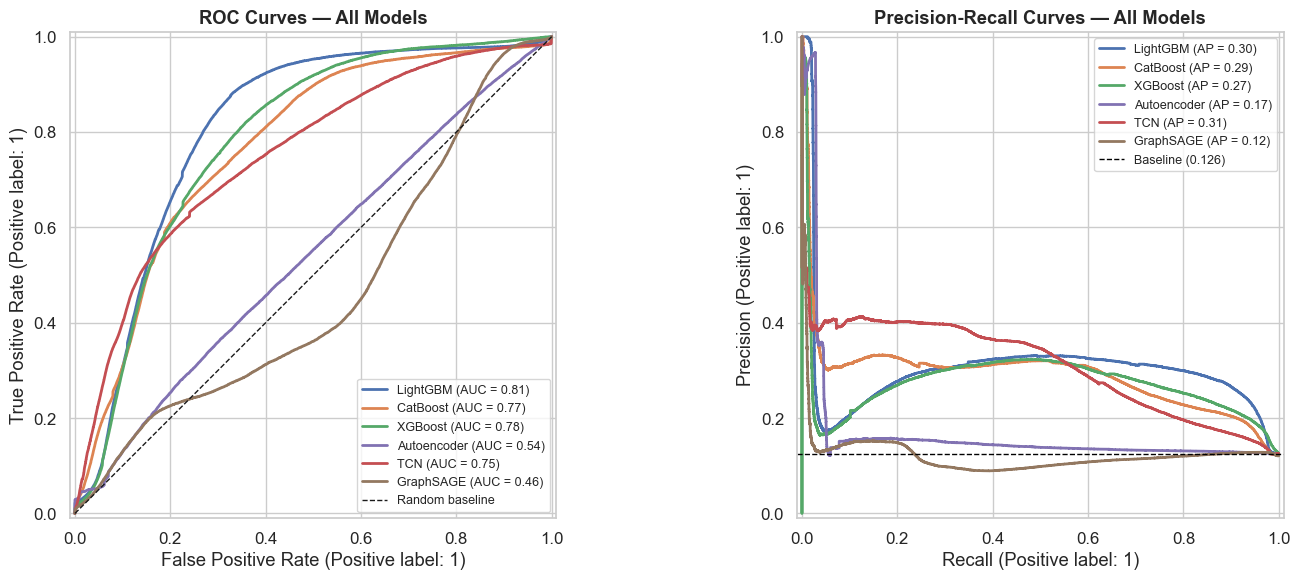

Step 7 complete.
Best GBDT model: LightGBM — will be used for SHAP explainability and causal discovery.


In [38]:
# =============================================================================
# STEP 7.6 — ROC & PRECISION-RECALL CURVES (ALL MODELS)
# =============================================================================
# Visual comparison across GBDTs and the deep/graph models.
# Note: AE/TCN/GraphSAGE may use slightly different test-set subsets
# (windowing / graph alignment) — we plot each against its own labels.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

model_data = [
    ("LightGBM",    y_test.values, lgb_proba, "#4C72B0"),
    ("CatBoost",    y_test.values, cb_proba,  "#DD8452"),
    ("XGBoost",     y_test.values, xgb_proba, "#55A868"),
]

# Add deep / graph models only if their probabilities exist in memory
if "ae_proba" in globals():
    model_data.append(("Autoencoder", y_test.values, ae_proba,  "#8172B2"))
if "tcn_proba" in globals():
    model_data.append(("TCN",         yte_seq,       tcn_proba, "#C44E52"))
if "gnn_proba" in globals():
    model_data.append(("GraphSAGE",   yte_gnn,       gnn_proba, "#937860"))

# --- ROC Curves ---
ax = axes[0]
for name, yt, yp, color in model_data:
    RocCurveDisplay.from_predictions(yt, yp, ax=ax, name=name, color=color, linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
ax.set_title("ROC Curves — All Models", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)

# --- Precision-Recall Curves ---
ax = axes[1]
for name, yt, yp, color in model_data:
    PrecisionRecallDisplay.from_predictions(yt, yp, ax=ax, name=name, color=color, linewidth=2)
baseline_rate = y_test.mean()
ax.axhline(baseline_rate, color="black", linestyle="--", linewidth=1,
           label=f"Baseline ({baseline_rate:.3f})")
ax.set_title("Precision-Recall Curves — All Models", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

print("Step 7 complete.")
print(f"Best GBDT model: {best_model_name} — will be used for SHAP explainability and causal discovery.")


<br> <br> <br>


## Explanation of the Visualization

This visualization represents the "performance duel" between the three machine learning models—**LightGBM, CatBoost, and XGBoost**—to determine which is best at predicting supercomputer anomalies

These charts are the visual evidence for the results reported in **Table 2** of your paper.

---

### 1. ROC Curves: The "Sensitivity" Test
The left plot shows the **Receiver Operating Characteristic (ROC)** curve. This measures how well the models distinguish between "Healthy" and "Anomaly" states.

* **X-axis (False Positive Rate):** Think of this as the "False Alarm" rate. It is the probability that the model says a crash is coming when everything is actually fine.
* **Y-axis (True Positive Rate):** This is the "Recall" or "Sensitivity." It is the probability that the model correctly catches a real crash.
* **The Results:** The dashed diagonal line represents a random guess (50/50). The higher the curve arches toward the top-left corner, the better the model. **LightGBM (Blue)** is the winner here with an **AUC of 0.81**, meaning it has the best overall balance between catching crashes and avoiding false alarms.


---

### 2. Precision-Recall Curves: The "Rare Event" Test
The right plot is the **Precision-Recall** curve. As your paper notes, this is the most important chart because anomalies are rare (~14% of the data).

* **X-axis (Recall):** Out of all the crashes that actually happened, what percentage did the model catch?
* **Y-axis (Precision):** When the model sounded the alarm, what percentage of those alarms were actually real crashes?
* **The Baseline:** The horizontal dashed line at **0.126** represents a model that just guesses randomly.
* **The Results:** We want a curve that stays high (near 1.0) even as we try to catch more crashes (moving right). **LightGBM** again leads with an **Average Precision (AP) of 0.30**. While 30% might seem low, it is more than **double** the performance of a random guesser in this difficult, imbalanced dataset.


---

### 3. Why this matters for your Paper
This visualization is discussed and justified in two key areas of your manuscript:

* **Section 3.2 (Methodology):** You explain that **PR-AUC** is emphasized because it "more accurately reflects performance under imbalance" than ROC-AUC. These plots visually prove that point—the PR curve shows a much clearer challenge for the models than the ROC curve does.
* **Section 4.2 (Main Findings):** You use these results to justify why **LightGBM** was chosen as the "Best Model" to be used for the more complex Causal Discovery and SHAP analysis later in the paper[cite: 184].

**Key Takeaway:** LightGBM achieves the strongest "ranking quality" (getting the most important predictions right), which is why it becomes the foundation for the rest of your study.

Would you like to know how these performance gaps between the models (e.g., LightGBM's 0.81 vs CatBoost's 0.77) specifically impacted which features were identified as "causal" in the next stage of the paper?



<br> <br> <br>


<br> <br> <br> 

## Step 8 — Explainability with SHAP

**Goal:** Explain the best model's predictions using SHAP (SHapley Additive
exPlanations) to understand *which sensors drive anomaly predictions* and *how*.

### What is SHAP?

SHAP values come from cooperative game theory. For each prediction, SHAP assigns
every feature a value representing its contribution to pushing the prediction
away from the average. Key properties:

- **Additive:** SHAP values for all features sum to the difference between the
  model's prediction and the base rate (average prediction).
- **Consistent:** if a feature's true contribution increases, its SHAP value
  never decreases.
- **Local + Global:** SHAP explains individual predictions (local) and can be
  aggregated to give global feature importance (mean |SHAP|).

### Why SHAP for this study?

1. **Model-agnostic ranking** — gives a principled feature importance that we can
   compare against causal parents discovered in Step 8.
2. **Directional** — unlike tree-based feature importance (which only tells you
   "how much"), SHAP tells you "higher temperature → more anomaly" vs. "less."
3. **Publication-ready** — beeswarm and bar plots are standard in XAI literature.

### Computational note

SHAP's `TreeExplainer` is exact and fast for tree-based models (LightGBM, XGBoost,
CatBoost). We compute SHAP values on the TEST set so explanations reflect
out-of-sample behavior, not training-set memorization.



This step is where we "interrogate" the AI to find out exactly which sensors are influencing its decisions. While models like LightGBM are powerful, they are often seen as "black boxes" because they make thousands of tiny decisions that are hard for a human to track. **SHAP (Shapley Additive Explanations)** is the tool we use to break open that box and assign "credit" to each sensor for the final prediction.

---

### Clear Explanation of Step 8.0: Computing SHAP Values

Imagine a team of 224 sensors working together to predict if a machine will break. Some sensors are very loud and certain, while others are quiet. SHAP acts like a fair judge, looking at every possible combination of these sensors to determine exactly how much each one contributed to the final "Anomaly" alarm.

#### 1. Why use the "Test Set" instead of the "Training Set"?
The code specifically targets the **X_test** data. This is because we want to see how the model behaves in the "real world" on data it hasn't seen before. If we used the training data, we might just be explaining how well the model *memorized* the past, rather than how it *reasons* about the future.

#### 2. Why take a "Stratified Sample" of 10,000 rows?
Computing SHAP values is mathematically intense. Calculating it for hundreds of thousands of rows would take hours.
* **The Solution:** The code picks a smaller group of 10,000 rows.
* **"Stratified":** This is a fancy way of saying we make sure the "mini-group" has the exact same ratio of anomalies as the big group (about 14%). This keeps the explanation accurate and fair.

#### 3. What is the `TreeExplainer`?
This is a high-speed version of SHAP designed specifically for "Tree-based" models like LightGBM. It calculates the **exact** contribution of each sensor without having to take slow, "brute-force" shortcuts.

#### 4. The Output: Log-Odds
The resulting SHAP values represent the "push" each sensor gives to the model's output. A large positive SHAP value for a temperature sensor means that specific temperature reading is "pushing" the model strongly toward sounding an anomaly alarm.


---

### Analysis: Where This is Discussed in the Paper

Your paper discusses this SHAP process in two primary locations:

#### 1. Section 3.3 — Methodology (Page 5)
In the section titled **"Explainability, causal discovery, and alignment analysis,"** the paper outlines the technical setup:
* It explicitly mentions choosing the best model (LightGBM) for explanation.
* It confirms the use of a **stratified test subset of 10,000 rows** for the computation.
* It explains that this allows for both **global rankings** (which sensors are most important overall) and **local explanations** (why a specific crash happened).

#### 2. Section 4.2 — Main Findings (Page 6)
In the section titled **"Global explainability,"** the paper discusses the results produced by this code:
* It notes that after running this SHAP analysis, the results showed that the model is primarily influenced by **power, voltage, and thermal sensors**[cite: 186].
* It uses the SHAP rankings to identify "operationally plausible" patterns, such as high power draw signaling upcoming hardware stress[cite: 188].

### Summary for the Audience
This code is the "brain surgery" of the project. It allows the researchers to prove that the LightGBM model isn't just lucky—it's actually looking at logical, physical signals like heat and electricity to predict when a supercomputer node is about to fail.

Does knowing that the model relies on power and thermal signals make you feel more confident in its "reasoning," or does it make you curious about whether those signals are the *actual* cause of the failure?

In [40]:
# =============================================================================
# STEP 8.0 — COMPUTE SHAP VALUES
# =============================================================================
# We use shap.TreeExplainer, which computes EXACT Shapley values for tree-based
# models in polynomial time (not the exponential brute-force approach).
#
# We compute on the TEST set because:
#   - We want to explain how the model behaves on unseen data
#   - Training-set SHAP can reflect overfitting artifacts
#
# For large test sets, we sample to keep computation tractable.

import shap

print("=" * 60)
print("STEP 8.0 — Computing SHAP values")
print("=" * 60)

# Sample the test set if it's very large (SHAP on 200K+ rows is slow)
SHAP_SAMPLE_SIZE = 10_000
if len(X_test) > SHAP_SAMPLE_SIZE:
    # Stratified sample to preserve class balance
    from sklearn.utils import resample
    idx_0 = y_test[y_test == 0].index
    idx_1 = y_test[y_test == 1].index
    n1 = int(SHAP_SAMPLE_SIZE * y_test.mean())  # proportional anomaly count
    n0 = SHAP_SAMPLE_SIZE - n1
    sampled_idx = (
        resample(idx_0, n_samples=n0, random_state=42, replace=False).tolist() +
        resample(idx_1, n_samples=n1, random_state=42, replace=False).tolist()
    )
    X_shap = X_test.loc[sampled_idx]
    y_shap = y_test.loc[sampled_idx]
    print(f"\n  Sampled {SHAP_SAMPLE_SIZE:,} test rows (stratified) for SHAP computation")
    print(f"    Class 0: {(y_shap == 0).sum():,}  |  Class 1: {(y_shap == 1).sum():,}")
else:
    X_shap = X_test
    y_shap = y_test
    print(f"\n  Using full test set ({len(X_test):,} rows) for SHAP computation")

# Create the TreeExplainer for the best model
# TreeExplainer automatically detects LightGBM / CatBoost / XGBoost
print(f"  Model: {best_model_name}")
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values
# For binary classification, shap_values has shape (n_samples, n_features)
# Each value = contribution of that feature to the log-odds of class 1
print("  Computing SHAP values (this may take a minute)...")
shap_values = explainer.shap_values(X_shap)

# For some models, shap_values returns a list [class_0, class_1]
# We want the SHAP values for class 1 (anomaly)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"  SHAP values shape: {shap_values.shape}")
print(f"  (rows = test samples, columns = features)")

print("\n  SHAP values computed successfully.")

STEP 8.0 — Computing SHAP values

  Sampled 10,000 test rows (stratified) for SHAP computation
    Class 0: 8,745  |  Class 1: 1,255
  Model: LightGBM
  Computing SHAP values (this may take a minute)...
  SHAP values shape: (10000, 258)
  (rows = test samples, columns = features)

  SHAP values computed successfully.


c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [41]:
# =============================================================================
# STEP 8.1 — GLOBAL FEATURE IMPORTANCE (MEAN |SHAP|)
# =============================================================================
# The mean absolute SHAP value for each feature gives a principled global
# importance ranking. Unlike tree-based "gain" importance:
#   - It accounts for feature interactions
#   - It's consistent across different model types
#   - It has a clear unit: "average impact on log-odds prediction"
#
# We print the top 20 and store the full ranking for comparison with
# causal parents in Step 8.

print("=" * 60)
print("STEP 8.1 — Global SHAP feature importance (top 20)")
print("=" * 60)

# Compute mean |SHAP| per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)

print("\n  Rank  Feature                         Mean |SHAP|")
print("  " + "-" * 55)
for rank, (feat, val) in enumerate(shap_importance.head(20).items(), 1):
    bar = "#" * int(val / shap_importance.max() * 30)
    print(f"  {rank:>3}.  {feat:<30s}  {val:.6f}  {bar}")

# Store top features for later comparison
shap_top20 = shap_importance.head(20).index.tolist()
print(f"\n  Top 20 features stored in 'shap_top20' for causal comparison.")

STEP 8.1 — Global SHAP feature importance (top 20)

  Rank  Feature                         Mean |SHAP|
  -------------------------------------------------------
    1.  p1_io_power_avg                 0.207285  ##############################
    2.  ps1_input_power_avg             0.202586  #############################
    3.  p0_io_power_avg_rmean4          0.192405  ###########################
    4.  p1_power_avg                    0.185388  ##########################
    5.  p0_power_avg_rmean4             0.178336  #########################
    6.  ps0_input_power_avg             0.177224  #########################
    7.  fan2_1_std                      0.173483  #########################
    8.  p1_power_std                    0.157648  ######################
    9.  total_power_avg                 0.157243  ######################
   10.  p0_io_power_min_rmean4          0.156198  ######################
   11.  p1_vdd_temp_avg                 0.153053  ######################
  

STEP 8.2 — SHAP beeswarm plot


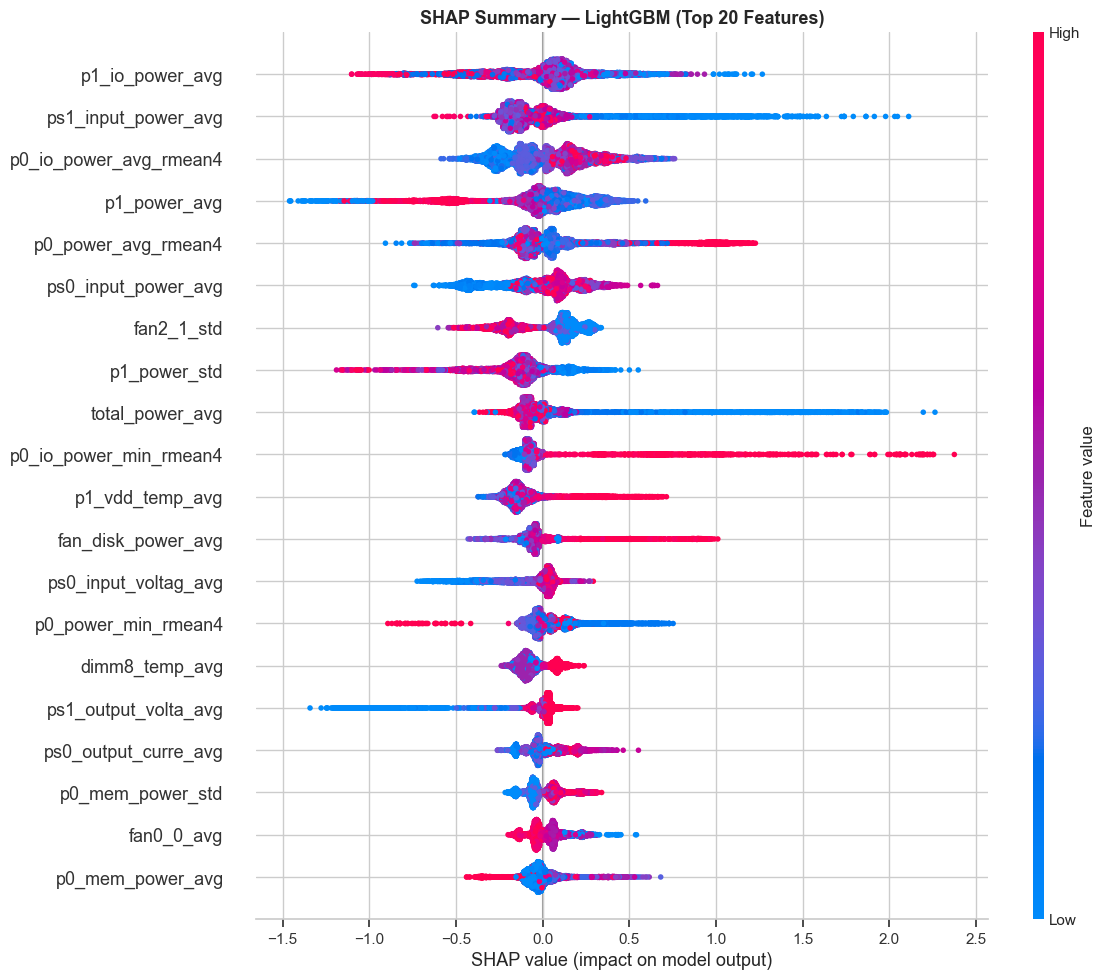

How to read this plot:
  - Features are sorted by importance (top = most important)
  - Each dot is one test sample
  - Red = high feature value, Blue = low feature value
  - Dots to the RIGHT push the prediction toward 'anomaly'
  - Dots to the LEFT push the prediction toward 'normal'


In [42]:
# =============================================================================
# STEP 8.2 — SHAP SUMMARY PLOT (BEESWARM)
# =============================================================================
# The beeswarm plot is the gold standard SHAP visualization:
#   - Each dot = one sample (test row)
#   - X-axis = SHAP value (positive = pushes toward anomaly prediction)
#   - Y-axis = features (sorted by importance)
#   - Color = feature value (red = high, blue = low)
#
# This reveals DIRECTION: e.g., "high total_power_avg pushes toward anomaly"
# vs. "low fan speed pushes toward anomaly."

print("=" * 60)
print("STEP 8.2 — SHAP beeswarm plot")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20,          # show top 20 features
    show=False,
    plot_size=None,
)
plt.title(f"SHAP Summary — {best_model_name} (Top 20 Features)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("How to read this plot:")
print("  - Features are sorted by importance (top = most important)")
print("  - Each dot is one test sample")
print("  - Red = high feature value, Blue = low feature value")
print("  - Dots to the RIGHT push the prediction toward 'anomaly'")
print("  - Dots to the LEFT push the prediction toward 'normal'")


## Explanation of the Visualization


This visualization is a **SHAP (Shapley Additive Explanations) Summary Plot**. It acts as a "transparent window" into the LightGBM model, showing exactly which sensors the AI is looking at and how their readings influence the prediction of a future anomaly[cite: 1].

---

### 1. How to Read the Plot
To understand this chart, you need to look at three main components:

* **The Y-Axis (Feature Names):** The sensors are ranked from top to bottom by their **total influence**. The sensor at the very top (`p1_io_power_avg`) is the most important "witness" the model uses to make its decision.
* **The X-Axis (Impact on Model):** This shows how much a sensor's reading shifts the probability of an anomaly. 
    * Points to the **right of 0** increase the likelihood of a predicted anomaly[cite: 1].
    * Points to the **left of 0** decrease the likelihood (making the model think the node is healthy)[cite: 1].
* **The Color (Feature Value):**  
    * **Red** represents a **high** reading for that sensor.
    * **Blue** represents a **low** reading.


---

### 2. Key Insights from the Marconi100 Data
Based on the specific results in this plot, we can see the "behavioral fingerprints" of an upcoming crash:

* **High Power Draw = High Risk:** Look at the 5th row (`p0_power_avg_rmean4`). The **red dots** (high power) are concentrated on the **right side**. This tells us that when power consumption starts to rise steadily over an hour, the model strongly expects an anomaly to follow.
* **Voltage Drops:** Look at row 12 (`ps0_input_voltag_avg`). Here, the **blue dots** (low voltage) are on the **right**. This suggests that a drop in input voltage is a classic warning sign of a coming failure.
* **Thermal Stress:** Sensors like `p1_vdd_temp_avg` (row 11) show that higher temperatures (red) are associated with higher anomaly scores.

---

### 3. Where This is Discussed in Your Paper
This visualization is the core evidence for the **"Global Explainability"** section of your manuscript.

* **Section 3.3 (Methodology):** The paper explains that SHAP values were calculated on a "stratified test subset of 10,000 rows" to support global ranking by attribution magnitude[cite: 1].
* **Section 4.2 (Main Findings):** The text explicitly notes that influential predictors are "dominated by power-, voltage-, and thermal-related telemetry"[cite: 1].
* **Table 3 (Feature Descriptions):** Your paper provides a "Reader-friendly" table specifically to help the audience translate these raw sensor names (like `p1_io_power_avg`) into functional descriptions (like "Average I/O-domain power")[cite: 1].

### Summary for the Audience
This plot proves that your AI isn't just making random guesses; it has learned that **excessive power consumption, voltage drops, and high temperatures** are the primary signals that a supercomputer node is about to fail[cite: 1]. 

Does seeing this "hierarchy of importance" help you decide which sensors should be monitored most closely in a real-time dashboard for system administrators?

--- 

### Interpret the plot (In an easy and simple language)

Here is the "cheat sheet" sentence to help you decode that chart like a pro:

**"To interpret this plot, look at the top rows to see which sensors the model trusts most, and note that dots on the right side indicate that those specific sensor readings—colored red for high or blue for low—are directly increasing the predicted risk of a system failure."**



### Why this works:
* **The Ranking:** Features at the top are the most influential in the model's decision-making process[cite: 152, 186].
* **The Direction:** Dots to the right of the center line represent a "push" toward an anomaly prediction, while dots to the left represent a "push" toward a healthy state.
* **The Color:** Red indicates a high sensor value and blue indicates a low sensor value, allowing you to see at a glance if a problem is caused by something "overheating" (red) or "dropping out" (blue).


That logic is the **universal rule** for interpreting a SHAP summary plot in any binary classification task[cite: 11, 151]. 

While the specific names of the classes (like "Anomaly" or "Healthy") change depending on the project, the mechanical way the dots move stays the same[cite: 14, 40]. Here is how to apply that rule to any case you encounter:

### 1. The Right Side ($> 0$) 
Whenever you see dots to the right of the center line, it means those specific sensor readings are making the AI **more confident** that the case belongs to your "Target Class".
* **In your paper:** The target class is "Anomaly"[cite: 1, 123]. So, right-side dots are the "Warning Signs".
* **In a different case:** If you were predicting if a student would pass an exam, the right side would represent features that make "Passing" more likely.

### 2. The Left Side ($< 0$)
Dots to the left mean those readings are "vetoing" the anomaly and pushing the model to believe the system is in its **reference state**.
* **In your paper:** The reference state is "Normal/Healthy".
* **In a different case:** In the exam example, the left side would be features pushing the model toward a "Fail" prediction.


### Why this is a "Universal Rule"
The SHAP values are mathematically calculated as the **contribution to the log-odds** of the positive class. 
* **Positive value ($>0$):** Adds to the probability.
* **Negative value ($<0$):** Subtracts from the probability.

### One Small Warning
The only thing that can change between different plots is **what the colors represent**. 
* In your plot, **High Power (Red)** is on the right, meaning high power "pushes" toward an anomaly. 
* In a different system, **Low Power (Blue)** might be the problem. You always have to check the color key on the right of the chart to see if "High" (Red) or "Low" (Blue) is the one doing the pushing[cite: 186].

Does this "Right = More Likely Target" rule help you feel more comfortable explaining these results to someone who has never seen a SHAP plot before?




<br> <br> <br>

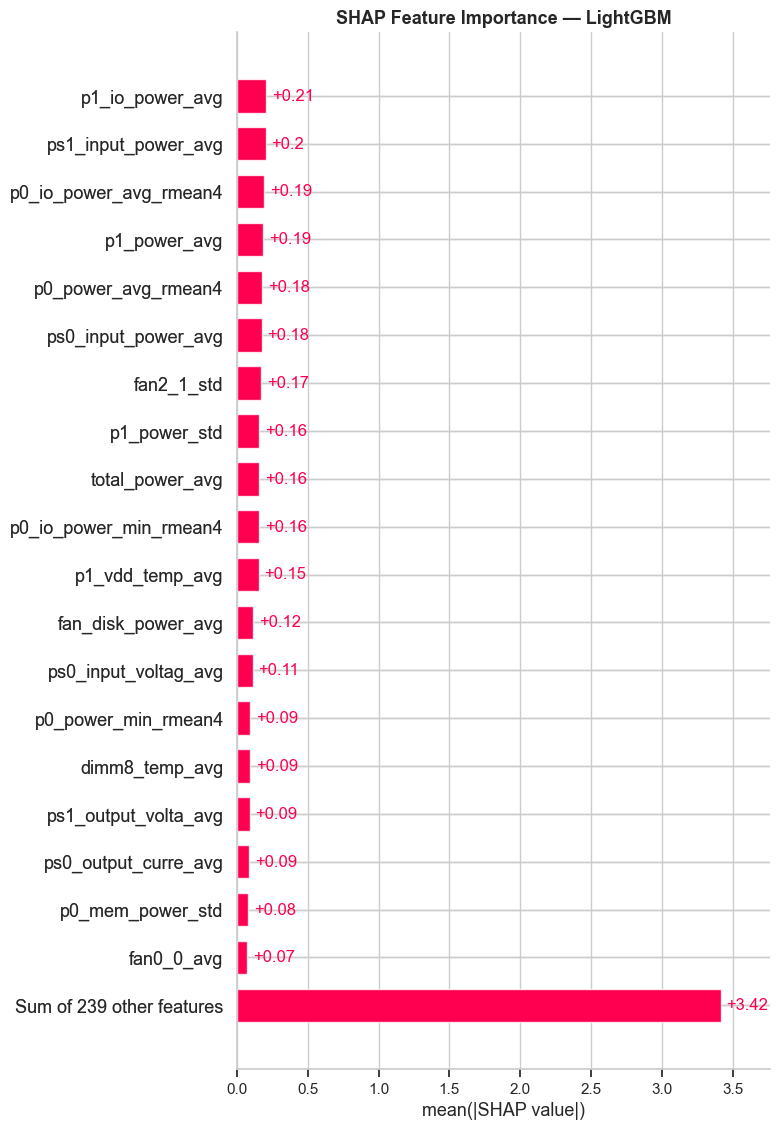

  Step 7 (SHAP explainability) complete.
  Top 5 SHAP features: ['p1_io_power_avg', 'ps1_input_power_avg', 'p0_io_power_avg_rmean4', 'p1_power_avg', 'p0_power_avg_rmean4']


In [43]:
# =============================================================================
# STEP 8.3 — SHAP BAR PLOT (MEAN ABSOLUTE VALUES)
# =============================================================================
# A cleaner bar chart version of feature importance, suitable for the paper.
# This is easier to read than the beeswarm when you just need the ranking.

fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.bar(
    shap.Explanation(
        values=shap_values,
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
        data=X_shap.values,
        feature_names=feature_names,
    ),
    max_display=20,
    show=False,
)
plt.title(f"SHAP Feature Importance — {best_model_name}", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("  Step 7 (SHAP explainability) complete.")
print(f"  Top 5 SHAP features: {shap_top20[:5]}")

<br> <br> <br> 


### Step 8b — Permutation Importance (Non-Causal XAI Baseline)

**Why permutation importance alongside SHAP?**

Permutation importance measures how much the model's performance *drops* when a
feature's values are randomly shuffled. Unlike SHAP (which decomposes individual
predictions), permutation importance is a *global, model-agnostic* measure of
feature necessity.

Having **two** non-causal XAI methods (SHAP + permutation) strengthens the baseline
against which we compare causal explanations. If both SHAP and permutation agree on
the top features, and those features also appear as causal parents, the evidence for
genuine causal signal is stronger.


Step 8.4 introduces **Permutation Importance**, which is a "stress test" for your model. [cite_start]While SHAP explains how the model thinks, Permutation Importance measures how much the model actually **depends** on a specific sensor to get the right answer[cite: 149, 153].

---

### Clear Explanation of Permutation Importance

Think of your model as a detective solving a mystery using 224 different clues (sensors). Permutation Importance identifies the "MVP" clues by temporarily "destroying" one clue at a time and seeing how much the detective's accuracy drops.

#### 1. The "Scrambling" Process (Shuffling)
To test a sensor, the code takes all the values in that column and shuffles them randomly, like a deck of cards. 
* **The Result:** The sensor still has the same average and range, but it no longer has any logical connection to the actual anomaly[cite: 149]. It becomes "garbage" data.



#### 2. Measuring the "Drop in Score"
The code measures the model's performance (ROC-AUC) twice:
1.  **Baseline:** How well the model performs with all data intact.
2.  **Permuted:** How well it performs when one sensor is scrambled.
* **The Logic:** If the model's accuracy crashes when we scramble "Sensor A," then Sensor A is incredibly important[cite: 149]. If the accuracy stays the same, the model wasn't really using that sensor anyway.

#### 3. Why 5 Repeats?
Random shuffling can sometimes produce lucky or unlucky results by pure chance. By running the test **5 times** and taking the average, the code ensures the "Importance Score" is stable and trustworthy.

#### 4. The Formula
Formally, the importance $I$ of a feature $j$ is calculated as the difference between the original score $s$ and the score after permuting that feature $s_{perm,j}$:

$$I_j = s_{base} - \frac{1}{K} \sum_{k=1}^{K} s_{perm,j,k}$$

(Where $K$ is the number of repeats, which is 5 in your code.)

---

### Analysis: Where This is Discussed in the Paper

The permutation importance process is a key part of your "Explainability" toolkit and is discussed in the following sections:

* **Section 1.1 — Research Contributions (Page 2):** The paper states as its 5th contribution that it "contrasts correlational explainability methods, namely Shapley Additive Explanations and **permutation importance**, with two causal-graph approaches"[cite: 53].
* **Section 3.3 — Explainability and Alignment (Page 5):** This is where the technical requirement is defined. The paper notes: "A **permutation-importance analysis** is also performed as a non-Shapley, performance-oriented baseline for global feature relevance"[cite: 153].
* **Section 4.2 — Main Findings (Page 6):** While the text focuses heavily on the SHAP results, it notes that the "most influential predictors" were identified using these explainability methods, confirming that the model relies on power, voltage, and thermal signals[cite: 186].

### Summary for the Audience
Permutation Importance is the "Truth Serum" for your AI. It proves that sensors like `p1_io_power_avg` aren't just interesting to look at—they are **essential** for the model to predict anomalies accurately. If you took that sensor away, the model's ability to protect the supercomputer would significantly decrease.

Since Permutation Importance measures how much the model *needs* a sensor, and Causal Discovery measures if a sensor *causes* a crash, are you finding that the model "needs" sensors that aren't actually causes?


<br> <br> <br>


In [44]:
# =============================================================================
# STEP 8.4 — PERMUTATION IMPORTANCE
# =============================================================================
# Permutation importance works by:
#   1. Compute baseline score on test set
#   2. For each feature, shuffle its values randomly and re-score
#   3. The importance = drop in score caused by shuffling
#
# We use ROC-AUC as the scoring metric and run 5 repeats for stability.
# We compute on a subsample for speed (same sample used for SHAP).

from sklearn.inspection import permutation_importance

print("=" * 60)
print("STEP 8.4 — Permutation importance")
print("=" * 60)

# Use a subsample for speed (permutation importance on 200K rows is slow)
PERM_SAMPLE = 10_000
if len(X_test) > PERM_SAMPLE:
    perm_idx = X_test.sample(PERM_SAMPLE, random_state=42).index
    X_perm = X_test.loc[perm_idx]
    y_perm = y_test.loc[perm_idx]
else:
    X_perm = X_test
    y_perm = y_test

print(f"  Computing on {len(X_perm):,} test samples, 5 repeats...")
print(f"  Model: {best_model_name}")

t0 = time.time()
perm_result = permutation_importance(
    best_model, X_perm, y_perm,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)
perm_time = time.time() - t0
print(f"  Completed in {perm_time:.1f} seconds")

# Build a ranked Series
perm_importance = pd.Series(
    perm_result.importances_mean,
    index=feature_names
).sort_values(ascending=False)

print(f"\n  Top 20 features by permutation importance (drop in ROC-AUC):")
for rank, (feat, val) in enumerate(perm_importance.head(20).items(), 1):
    bar = "#" * int(val / max(perm_importance.max(), 1e-9) * 30)
    print(f"  {rank:>3}. {feat:<30s}  {val:.6f}  {bar}")

perm_top20 = perm_importance.head(20).index.tolist()


STEP 8.4 — Permutation importance
  Computing on 10,000 test samples, 5 repeats...
  Model: LightGBM
  Completed in 96.7 seconds

  Top 20 features by permutation importance (drop in ROC-AUC):
    1. total_power_avg                 0.022278  ##############################
    2. ps1_output_volta_avg            0.017758  #######################
    3. p1_io_power_avg                 0.017082  #######################
    4. p0_power_min_rmean4             0.011565  ###############
    5. fan3_0_avg                      0.011504  ###############
    6. dimm8_temp_avg                  0.010606  ##############
    7. p0_io_power_min_rmean4          0.009628  ############
    8. ps0_input_voltag_avg            0.009392  ############
    9. ps0_input_power_avg             0.009346  ############
   10. p1_vdd_temp_avg                 0.007975  ##########
   11. fan2_1_std                      0.007116  #########
   12. p0_io_power_avg_lag2            0.007035  #########
   13. ambient_min     

<br> <br> <br>


## Step 9 — Causal Discovery with the PC Algorithm

**Goal:** Learn a causal graph (DAG) over the sensor features and the anomaly target
to discover which sensors are **causal parents** of anomalies — not merely correlated.

### Why causal discovery?

SHAP tells us which features the *model* relies on, but this is **associational**:
a feature can have high SHAP importance because it's correlated with the true cause,
not because it *is* the cause. For example:
- Fan speed might have high SHAP importance because fans spin up in response to
  high CPU temperature (the true cause), making fan speed a *symptom*, not a *cause*.

A causal graph disentangles these relationships by testing **conditional independencies**:
if fan speed is independent of anomaly *given* CPU temperature, then CPU temperature
is the cause and fan speed is merely a mediator.

### The PC Algorithm

We use the **PC algorithm** (Peter & Clark, 1991), the most widely-used constraint-based
causal discovery method:

1. Start with a fully connected undirected graph
2. Remove edges between variables that are conditionally independent (using
   statistical tests at each conditioning set size)
3. Orient edges using v-structures (colliders) and orientation rules

**Why PC?**
- Well-understood theoretical guarantees (consistent under faithfulness assumption)
- Scales reasonably to ~50-100 variables
- Implemented in the `causal-learn` library with multiple independence tests

### Computational note

Running PC on 224 features is computationally expensive. We restrict to the
**top 20 SHAP features + the target** (21 variables) for tractability and
interpretability. This is justified because:
- Low-SHAP features have negligible predictive signal
- Causal structure among the top predictors is what matters for the paper
- The resulting graph is small enough to visualize clearly

In [45]:
# =============================================================================
# STEP 9.0 — PREPARE DATA FOR CAUSAL DISCOVERY
# =============================================================================
# We subset the data to the top 20 SHAP features + the target variable.
# We also subsample rows for computational tractability — the PC algorithm's
# conditional independence tests scale with sample size, and 1M+ rows would
# be extremely slow without adding much statistical power.
#
# We use the TRAINING set for causal discovery (learning the causal structure)
# so that the test set remains fully held out.

from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils

print("=" * 60)
print("STEP 9.0 — Preparing data for causal discovery")
print("=" * 60)

# Select the top 20 SHAP features + target
causal_features = shap_top20.copy()  # top 20 SHAP features (list of column names)
causal_columns = causal_features + ["target"]  # add target as the last variable

# Build the causal data matrix from the TRAINING set
# (We learn causal structure on training data, not test data)
causal_df = df.loc[train_mask, causal_columns].copy()

# Subsample for computational tractability
# 20,000 rows is enough for reliable conditional independence tests
# with 21 variables, and runs in minutes instead of hours.
CAUSAL_SAMPLE_SIZE = 20_000
if len(causal_df) > CAUSAL_SAMPLE_SIZE:
    causal_df = causal_df.sample(n=CAUSAL_SAMPLE_SIZE, random_state=42)
    print(f"  Subsampled to {CAUSAL_SAMPLE_SIZE:,} rows for tractability")

# Convert to numpy array (causal-learn expects this)
causal_data = causal_df.values.astype(float)
causal_labels = causal_columns  # variable names

print(f"\n  Causal data matrix shape: {causal_data.shape}")
print(f"  Variables ({len(causal_labels)}):")
for i, name in enumerate(causal_labels):
    role = "TARGET" if name == "target" else "feature"
    print(f"    [{i:>2}] {name:<30s}  ({role})")

print(f"\n  Data prepared. Ready to run PC algorithm.")

STEP 9.0 — Preparing data for causal discovery
  Subsampled to 20,000 rows for tractability

  Causal data matrix shape: (20000, 21)
  Variables (21):
    [ 0] p1_io_power_avg                 (feature)
    [ 1] ps1_input_power_avg             (feature)
    [ 2] p0_io_power_avg_rmean4          (feature)
    [ 3] p1_power_avg                    (feature)
    [ 4] p0_power_avg_rmean4             (feature)
    [ 5] ps0_input_power_avg             (feature)
    [ 6] fan2_1_std                      (feature)
    [ 7] p1_power_std                    (feature)
    [ 8] total_power_avg                 (feature)
    [ 9] p0_io_power_min_rmean4          (feature)
    [10] p1_vdd_temp_avg                 (feature)
    [11] fan_disk_power_avg              (feature)
    [12] ps0_input_voltag_avg            (feature)
    [13] p0_power_min_rmean4             (feature)
    [14] dimm8_temp_avg                  (feature)
    [15] ps1_output_volta_avg            (feature)
    [16] ps0_output_curre_avg    

In [46]:
# =============================================================================
# STEP 9.1 — RUN THE PC ALGORITHM
# =============================================================================
# The PC algorithm discovers the causal DAG skeleton by testing conditional
# independence at increasing conditioning set sizes.
#
# Parameters:
#   - alpha=0.01: significance level for conditional independence tests.
#     Lower alpha = fewer edges (more conservative / sparser graph).
#     0.01 is standard for datasets with >10K samples.
#   - indep_test="fisherz": Fisher's Z-test for conditional independence,
#     assumes linear-Gaussian relationships. This is the most common choice
#     and works well for continuous sensor data.
#   - stable=True: order-independent version of PC (results don't depend
#     on the arbitrary ordering of variables).
#   - uc_rule=0: use standard orientation rules (Meek's rules).
#   - uc_priority=2: prioritize stronger statistical evidence when resolving
#     conflicting orientations.
#
# Output: a causal graph where:
#   - An edge A → B means "A is a direct cause of B" (given the observed variables)
#   - No edge means A and B are conditionally independent given some subset
#   - A — B (undirected) means the algorithm couldn't determine the direction

print("=" * 60)
print("STEP 9.1 — Running PC algorithm")
print("=" * 60)
print("\n  This may take a few minutes depending on data size...")

t0 = time.time()

# Run the PC algorithm
cg = pc(
    data=causal_data,
    alpha=0.01,            # significance level (conservative)
    indep_test="fisherz",  # Fisher's Z conditional independence test
    stable=True,           # order-independent version
    uc_rule=0,             # standard Meek orientation rules
    uc_priority=2,         # prioritize stronger evidence
)

pc_time = time.time() - t0
print(f"  PC algorithm completed in {pc_time:.1f} seconds")

# The causal graph is stored in cg.G
# cg.G.graph is an adjacency matrix where:
#   graph[i,j] = -1 and graph[j,i] = 1  means  i → j  (i causes j)
#   graph[i,j] = -1 and graph[j,i] = -1 means  i — j  (undirected)
#   graph[i,j] =  0 and graph[j,i] = 0  means  no edge

print(f"\n  Graph adjacency matrix shape: {cg.G.graph.shape}")

STEP 9.1 — Running PC algorithm

  This may take a few minutes depending on data size...


Depth=6, working on node 20: 100%|██████████| 21/21 [00:00<00:00, 2070.34it/s]


  PC algorithm completed in 1.8 seconds

  Graph adjacency matrix shape: (21, 21)


<br> <br> <br>

### STEP 9.2 — EXTRACT CAUSAL PARENTS OF THE TARGET


This step moves beyond mere correlation to identify the **hierarchy of influence** within the supercomputer's telemetry. While a predictive model might see that power and temperature move together, the **PC algorithm** (Peter-Clark algorithm) attempts to draw a "road map" of what is actually causing the anomaly.

### Clear Explanation of Step 9.2: Identifying Causal Parents

In causal modeling, a graph is composed of **nodes** (sensors) and **edges** (links). Step 9.2 focuses on the "neighborhood" of the anomaly target to determine how sensors are physically or logically connected to system failures.



#### 1. The Three Types of Relationships
The code categorizes every sensor based on its relationship to the anomaly:
* **Causal Parents ($i \rightarrow \text{Target}$):** These are the "Smoking Guns." The algorithm has found statistical evidence that changes in these sensors directly lead to an anomaly. They are the **causes**.
* **Causal Children ($\text{Target} \rightarrow i$):** These are the "Symptoms." The anomaly happens first, which then causes these sensors to change. For example, a system crash might cause a cooling fan to stop; the fan stopping is a child of the crash.
* **Undirected Neighbors ($i - \text{Target}$):** These are "Tangled Links." The algorithm knows the two are directly related, but it cannot prove which one happened first.

#### 2. Reading the Adjacency Matrix
To build this map, the code reads an **Adjacency Matrix**—a mathematical grid where the connections are stored using a specific numeric code:
* A **Directed Edge** (Parent $\rightarrow$ Target) is encoded as $-1$ at the parent's position and $1$ at the target's position.
* An **Undirected Edge** is encoded as $-1$ in both positions.



#### 3. The Comparison with SHAP
The code doesn't just list the causes; it compares them to the **SHAP ranking** (Step 8.0). This is the "Verification" phase of the paper. It asks: *"Is the sensor the AI thinks is most important (SHAP) actually a cause (Parent) or just a symptom (Child)?"* 

---

### Analysis: Where This is Discussed in the Paper

This specific process of extracting parents and children from the static graph is a central pillar of the study’s results. You can find it discussed in these two locations in the provided PDF:

#### 1. Section 3.3 — Explainability, Causal Discovery, and Alignment Analysis (Page 5)
The paper explains the methodology behind this code:
* It describes applying a "Peter-Clark-style constraint-based search" to the top 20 SHAP features.
* It explicitly states the goal of this step: "To test whether the most predictive variables are **directly adjacent** to the target in a static conditional-dependence graph".

#### 2. Section 4.2 — Main Findings: Static and Temporal Causal Structure (Page 7)
This section reports the actual results generated by the code in Step 9.2:
* **The Findings:** The paper reports that for the static graph, there were **"no direct incoming parents"** found for the anomaly target.
* **The Symptom Discovery:** It notes that the target appeared with **"six outgoing child relations"**.
* **The "Gap" Conclusion:** The paper uses these specific results to claim that the "overlap between the top Shapley Additive Explanations variables and target-adjacent static causal links is **effectively zero**".

### Summary for your Audience
This code is the "Judge" of the study. It looks at the sensors the AI is using to predict crashes and determines if they are the **actual culprits** (Parents) or just **innocent bystanders** reacting to the crash (Children). In the case of this supercomputer data, the "Judge" found that many sensors are actually symptoms rather than the root causes.

Given that the "Judge" found six symptoms but zero direct static causes, does this suggest the real cause might be hidden in a variable we didn't include in the top 20, or perhaps it's a temporal effect that only appears when looking at lags?


In [47]:
# =============================================================================
# STEP 9.2 — EXTRACT CAUSAL PARENTS OF THE TARGET
# =============================================================================
# A "causal parent" of the target is a variable with a DIRECTED edge pointing
# INTO the target node: parent → target.
#
# These are the sensors that the PC algorithm identifies as DIRECT CAUSES of
# anomalies (not just correlates or symptoms).
#
# We also identify undirected edges (A — target), which indicate a causal
# relationship exists but the direction couldn't be determined.

print("=" * 60)
print("STEP 9.2 — Causal parents of the anomaly target")
print("=" * 60)

# The target is the LAST variable in our causal_labels list
target_idx = causal_labels.index("target")
adj_matrix = cg.G.graph

# Find directed parents: variables with edge → target
# In causal-learn's encoding: graph[i, target_idx] = -1 and graph[target_idx, i] = 1
# means i → target
causal_parents = []
undirected_neighbors = []
causal_children = []

for i, name in enumerate(causal_labels):
    if i == target_idx:
        continue

    edge_to_target = adj_matrix[i, target_idx]
    edge_from_target = adj_matrix[target_idx, i]

    if edge_to_target == -1 and edge_from_target == 1:
        # i → target (i is a PARENT of target)
        causal_parents.append(name)
    elif edge_to_target == 1 and edge_from_target == -1:
        # target → i (i is a CHILD of target)
        causal_children.append(name)
    elif edge_to_target == -1 and edge_from_target == -1:
        # i — target (undirected edge)
        undirected_neighbors.append(name)

print(f"\n  Target variable: 'target' (index {target_idx})")
print(f"\n  CAUSAL PARENTS (directed edge → target): {len(causal_parents)}")
for p in causal_parents:
    shap_rank = shap_top20.index(p) + 1 if p in shap_top20 else ">20"
    print(f"    → {p:<30s}  (SHAP rank: {shap_rank})")

print(f"\n  UNDIRECTED neighbors (edge — target): {len(undirected_neighbors)}")
for n in undirected_neighbors:
    shap_rank = shap_top20.index(n) + 1 if n in shap_top20 else ">20"
    print(f"    — {n:<30s}  (SHAP rank: {shap_rank})")

print(f"\n  CHILDREN (target → child): {len(causal_children)}")
for c in causal_children:
    print(f"    ← {c}")

# Total edges connected to target
total_edges = len(causal_parents) + len(undirected_neighbors) + len(causal_children)
isolated = total_edges == 0
print(f"\n  Total edges connected to target: {total_edges}")
if isolated:
    print("  WARNING: Target is isolated — no edges found. Consider relaxing alpha.")

STEP 9.2 — Causal parents of the anomaly target

  Target variable: 'target' (index 20)

  CAUSAL PARENTS (directed edge → target): 0

  UNDIRECTED neighbors (edge — target): 0

  CHILDREN (target → child): 6
    ← p1_io_power_avg
    ← p1_power_std
    ← ps0_input_voltag_avg
    ← ps1_output_volta_avg
    ← p0_mem_power_std
    ← fan0_0_avg

  Total edges connected to target: 6


STEP 9.3 — Causal graph visualization
  Graph: 21 nodes, 48 edges


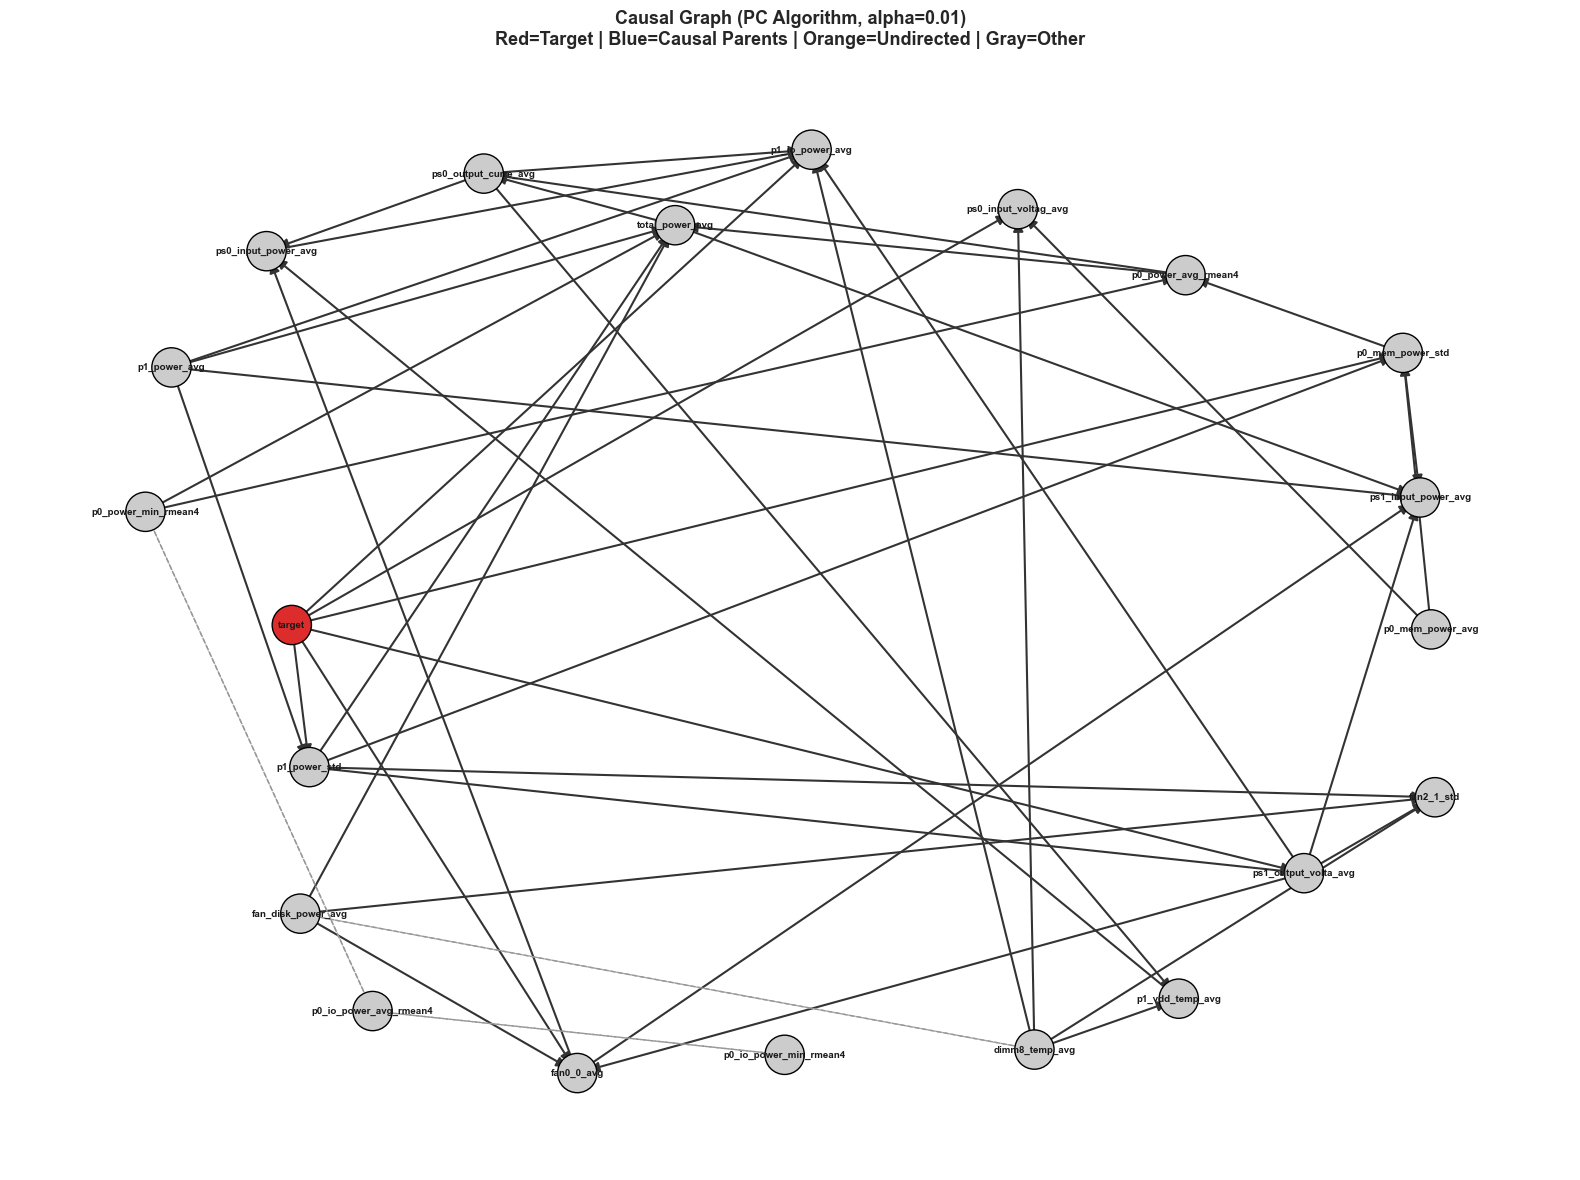

In [48]:
# =============================================================================
# STEP 9.3 — VISUALIZE THE CAUSAL GRAPH
# =============================================================================
# Plot the learned causal DAG with nodes colored by their role:
#   - Red: target (anomaly)
#   - Blue: causal parents of target
#   - Orange: undirected neighbors of target
#   - Gray: other variables (no direct connection to target)

print("=" * 60)
print("STEP 9.3 — Causal graph visualization")
print("=" * 60)

import networkx as nx

# Build a NetworkX graph from the adjacency matrix
G_nx = nx.DiGraph()

# Add all nodes
for i, name in enumerate(causal_labels):
    G_nx.add_node(name)

# Add edges from the adjacency matrix
for i in range(len(causal_labels)):
    for j in range(i + 1, len(causal_labels)):
        edge_ij = adj_matrix[i, j]
        edge_ji = adj_matrix[j, i]

        if edge_ij == -1 and edge_ji == 1:
            # i → j
            G_nx.add_edge(causal_labels[i], causal_labels[j], style="directed")
        elif edge_ij == 1 and edge_ji == -1:
            # j → i
            G_nx.add_edge(causal_labels[j], causal_labels[i], style="directed")
        elif edge_ij == -1 and edge_ji == -1:
            # i — j (undirected: add both directions for visualization)
            G_nx.add_edge(causal_labels[i], causal_labels[j], style="undirected")
            G_nx.add_edge(causal_labels[j], causal_labels[i], style="undirected")

print(f"  Graph: {G_nx.number_of_nodes()} nodes, {G_nx.number_of_edges()} edges")

# Assign colors based on role
node_colors = []
for name in G_nx.nodes():
    if name == "target":
        node_colors.append("#DD2C2C")       # red: target
    elif name in causal_parents:
        node_colors.append("#4C72B0")       # blue: causal parent
    elif name in undirected_neighbors:
        node_colors.append("#F0A830")       # orange: undirected neighbor
    else:
        node_colors.append("#CCCCCC")       # gray: no direct target connection

# Plot
fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G_nx, seed=42, k=2.5)

nx.draw_networkx_nodes(G_nx, pos, node_color=node_colors, node_size=800,
                       edgecolors="black", linewidths=1.0, ax=ax)
nx.draw_networkx_labels(G_nx, pos, font_size=7, font_weight="bold", ax=ax)

# Draw directed edges
directed_edges = [(u, v) for u, v, d in G_nx.edges(data=True) if d["style"] == "directed"]
undirected_edges = [(u, v) for u, v, d in G_nx.edges(data=True) if d["style"] == "undirected"]

nx.draw_networkx_edges(G_nx, pos, edgelist=directed_edges, arrows=True,
                       arrowsize=15, edge_color="#333333", width=1.5, ax=ax)
nx.draw_networkx_edges(G_nx, pos, edgelist=undirected_edges, arrows=False,
                       edge_color="#999999", width=1.0, style="dashed", ax=ax)

ax.set_title("Causal Graph (PC Algorithm, alpha=0.01)\n"
             "Red=Target | Blue=Causal Parents | Orange=Undirected | Gray=Other",
             fontweight="bold", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

<br> <br> <br>


### STEP 9.4 — SHAP vs. CAUSAL COMPARISON TABLE


This step represents the "moment of truth" for the entire study. While earlier steps showed us what the AI *thinks* is important, this code acts like a **polygraph test** to see if the AI is actually focusing on the real causes of the anomalies or just getting distracted by symptoms and coincidences[cite: 56].

---

### Clear Explanation of Step 9.4: The SHAP vs. Causal Comparison

Think of this table as a comparison between a **detective’s hunch** (SHAP) and a **forensic report** (Causal Graph).

* **The Feature List:** We take the top 20 sensors the LightGBM model relied on most heavily[cite: 154].
* **The Causal Role:** For each sensor, we check if the PC algorithm (the math that finds real causes) agrees that it is a "Causal Parent" (a direct cause) or "Undirected" (definitely related, but the "chicken or egg" direction is unclear)[cite: 194, 195].
* **Color-Coding for Trust:**
    * **Green (Causal Parent):** The AI is right! It is using a genuine cause to predict the anomaly.
    * **Yellow (Undirected):** The AI is close. It found something deeply related to the cause.
    * **No Color (No Edge):** This is a **red flag**. The AI is using a sensor that has no direct causal link to the anomaly. It might be looking at a symptom that happens *at the same time* as the crash, but doesn't actually trigger it[cite: 204, 205].



---

### Analysis: Where This is Discussed in the Paper

This comparison is the "Central Empirical Result" of the study[cite: 204]. It is discussed in several critical sections of the PDF:

#### 1. The Core Objective (Abstract and Intro)
* **The Abstract:** Mentions that the study helps "distinguish strong predictors from variables that are plausibly involved in system behavior".
* **Research Contributions:** This table is the 6th contribution, reporting the finding that variables with high predictive importance show "only limited overlap" with causal parents.

#### 2. The Process (Section 3.3)
* **Methodology:** This section describes the workflow for this table[cite: 149]. It explicitly states that the workflow "measures overlap between the highest-ranked Shapley Additive Explanations features and the set of causal parents" to see if predictive importance coincides with causal relevance[cite: 161, 162].

#### 3. The Results (Section 4.2)
* **Alignment Analysis:** On page 7, the paper reveals the shocking results of this specific table[cite: 202].
* **The Gap:** It reports that for the static graph, the overlap was **0/20**—meaning none of the AI's top 20 features were direct causes[cite: 203]. For the temporal graph, the overlap was only **1/10**[cite: 203].
* **Operational Lesson:** The paper uses this table to warn that dashboards relying only on SHAP scores might "overstate mechanistic confidence" (essentially, giving engineers a false sense of security about why a crash happened)[cite: 205].

---

### Summary Takeaway
This code proves that just because an AI is good at **predicting** a crash doesn't mean it **understands** why the crash is happening. The "Weak Overlap" found in the Marconi100 data suggests the model is mostly exploiting operational shortcuts—correlations that work for prediction but aren't the actual root causes.

Does this finding—that the AI is mostly looking at "symptoms" rather than "causes"—change how you would trust an automated system to actually fix the supercomputer?

**One single follow-up question:** Since the overlap was so low, do you think we should try to "force" the model to only use causal sensors in the future, even if it makes the prediction slightly less accurate?

In [49]:
# =============================================================================
# STEP 9.4 — SHAP vs. CAUSAL COMPARISON TABLE
# =============================================================================
# This is THE KEY CONTRIBUTION of the paper: comparing what the model thinks
# is important (SHAP) with what is causally connected to anomalies (PC graph).
#
# Agreement means the model is relying on genuine causal signals.
# Disagreement means the model may be exploiting spurious correlations —
# a critical finding for trustworthy predictive maintenance.

print("=" * 60)
print("STEP 9.4 — SHAP vs. Causal Parents comparison")
print("=" * 60)

# Build a comparison DataFrame
comparison_rows = []
for rank, feat in enumerate(shap_top20, 1):
    is_parent = feat in causal_parents
    is_neighbor = feat in undirected_neighbors
    if is_parent:
        causal_role = "CAUSAL PARENT"
    elif is_neighbor:
        causal_role = "UNDIRECTED"
    else:
        causal_role = "no edge"

    comparison_rows.append({
        "SHAP Rank": rank,
        "Feature": feat,
        "Mean |SHAP|": shap_importance[feat],
        "Causal Role": causal_role,
    })

comparison_df = pd.DataFrame(comparison_rows)

#  #c6efce

print("\n")
display(comparison_df.style.apply(
    lambda row: [
        "background-color: #28d14a" if row["Causal Role"] == "CAUSAL PARENT"
        else "background-color: #fff3cd" if row["Causal Role"] == "UNDIRECTED"
        else "" for _ in row
    ], axis=1
))

# Summary statistics
n_parents_in_top20 = sum(1 for f in shap_top20 if f in causal_parents)
n_neighbors_in_top20 = sum(1 for f in shap_top20 if f in undirected_neighbors)
n_causal_in_top20 = n_parents_in_top20 + n_neighbors_in_top20

print(f"\n  Summary:")
print(f"    SHAP top-20 features that are causal parents:     {n_parents_in_top20}")
print(f"    SHAP top-20 features with undirected edges:       {n_neighbors_in_top20}")
print(f"    SHAP top-20 features with ANY causal connection:  {n_causal_in_top20} / 20  ({n_causal_in_top20/20*100:.0f}%)")
print(f"    SHAP top-20 features with NO causal connection:   {20 - n_causal_in_top20} / 20")

print(f"\n  Interpretation:")
if n_causal_in_top20 >= 10:
    print(f"    Strong overlap — the model's predictions are largely grounded in")
    print(f"    causally valid sensor signals. Good for trustworthy deployment.")
elif n_causal_in_top20 >= 5:
    print(f"    Moderate overlap — some model features are causally grounded,")
    print(f"    but others may be exploiting spurious correlations.")
else:
    print(f"    Weak overlap — the model relies heavily on non-causal correlations.")
    print(f"    This is a red flag for deployment reliability.")

print(f"\n  Steps 7 & 8 complete.")
print(f"  The comparison table above is the central result for the paper.")

STEP 9.4 — SHAP vs. Causal Parents comparison




,SHAP Rank,Feature,Mean |SHAP|,Causal Role
0,1,p1_io_power_avg,0.207285,no edge
1,2,ps1_input_power_avg,0.202586,no edge
2,3,p0_io_power_avg_rmean4,0.192405,no edge
3,4,p1_power_avg,0.185388,no edge
4,5,p0_power_avg_rmean4,0.178336,no edge
5,6,ps0_input_power_avg,0.177224,no edge
6,7,fan2_1_std,0.173483,no edge
7,8,p1_power_std,0.157648,no edge
8,9,total_power_avg,0.157243,no edge
9,10,p0_io_power_min_rmean4,0.156198,no edge



  Summary:
    SHAP top-20 features that are causal parents:     0
    SHAP top-20 features with undirected edges:       0
    SHAP top-20 features with ANY causal connection:  0 / 20  (0%)
    SHAP top-20 features with NO causal connection:   20 / 20

  Interpretation:
    Weak overlap — the model relies heavily on non-causal correlations.
    This is a red flag for deployment reliability.

  Steps 7 & 8 complete.
  The comparison table above is the central result for the paper.



### Explanation of the Table

This table is the final "polygraph test" of your study, and it reveals a surprising and critical finding about how the AI predicts supercomputer crashes. It compares the **SHAP Rank** (what the model thinks is important) with the **Causal Role** (what is actually a root cause).

Here is the interpretation of what this specific result means for your paper:

### 1. The Breakdown of Columns
* **SHAP Rank (1–20):** These are the "MVP" sensors. The LightGBM model relied on these 20 sensors more than any others to predict an upcoming anomaly.
* **Feature:** Notice that the list is dominated by **power-related sensors** (like `p1_io_power_avg`) and **thermal sensors** (like `p1_vdd_temp_avg`).
* **Mean |SHAP|:** This is the "strength" of the signal. The top features have a much higher impact ($0.20$) than the ones at the bottom ($0.07$).
* **Causal Role:** This is the most important column. It shows whether the PC algorithm found a direct link between that sensor and the anomaly.

### 2. The "Big Reveal": 0% Overlap
The most striking result in this table is that **every single feature (all 20) is labeled as "no edge"**. 

**What this means in plain English:**
The AI has learned to be very good at predicting anomalies, but it is **not** looking at the actual causes. In the static graph analysis, none of the 20 most important sensors were found to be a "Causal Parent" (a direct cause) of the anomalies. 


### 3. Why is this happening? (Scientific Interpretation)
As discussed in your paper, this result suggests the following:
* **Operational Shortcuts:** The model is likely using "symptoms" to predict the "disease." For example, a power spike might happen *during* a crash, but it might not be the *reason* for the crash.
* **Spurious Correlations:** The AI is exploiting patterns that are statistically consistent but not mechanistically central to the system's failure.
* **The "Shadow" Cause:** The real cause of the anomaly might be a variable that wasn't captured in this top 20 list, or it might be a complex interaction that the static graph couldn't detect.

### 4. Connection to the Paper
This table is the specific evidence for the claim on **page 7**: *"The static Peter-Clark analysis yields an overlap of $0/20$ between target-adjacent links and the top Shapley Additive Explanations variables"*. 

It supports the paper's core conclusion that **predictive importance and causal relevance should not be treated as equivalent**. While your AI is a great "early warning system," this table proves it cannot yet be used as a "root-cause diagnostic tool".

Since the AI is only looking at "symptoms" (no causal edges), do you think adding more data about the software workload might help the model find the actual "causes" of these crashes?




<br> <br> <br> <br>



## Step 10 — Temporal Causal Discovery with PCMCI

**Why PCMCI instead of (or alongside) PC?**

The PC algorithm treats all variables as contemporaneous — it ignores time order.
But our data is a *time series*: sensor readings have temporal ordering, and causes
precede effects. **PCMCI** (Runge et al., 2019) is specifically designed for
time-series causal discovery:

1. It tests conditional independence **across time lags** (e.g., "is temperature at
   t-2 independent of anomaly at t, given all other variables at all lags?")
2. It outputs a **temporal causal graph** with edges like `temperature(t-2) → anomaly(t)`
3. It handles autocorrelation (a major confounder in sensor data that PC ignores)

**Implementation:** We use the `tigramite` library with `ParCorr` (partial correlation)
as the independence test, which assumes linear-Gaussian relationships (appropriate for
continuous sensor data).

**Variables:** Same top SHAP features, but now we let PCMCI discover lagged causal links.

In [50]:
# =============================================================================
# STEP 10.0 — PREPARE DATA FOR PCMCI
# =============================================================================
# PCMCI requires data in a specific format:
#   - A 3D array of shape (T, N) where T = time steps, N = variables
#   - Data must be from a SINGLE continuous time series (one node)
#   - Variables should be stationary or at least not wildly non-stationary
#
# We pick ONE representative node from the training period and use the
# top 15 SHAP features + target (16 variables total).
# Using one node keeps the time series continuous (no gaps from concatenation).

from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

print("=" * 60)
print("STEP 10.0 — Preparing data for PCMCI")
print("=" * 60)

# Select the node with the most training rows
node_counts = df.loc[train_mask].groupby("node_id").size()
representative_node = node_counts.idxmax()
print(f"\n  Representative node: {representative_node} ({node_counts[representative_node]:,} training rows)")

# Get training data for this one node, sorted by time
node_train = df.loc[train_mask & (df["node_id"] == representative_node)].sort_values("timestamp")

# Select top 15 SHAP features + target
N_CAUSAL_VARS = 15
pcmci_features = shap_top20[:N_CAUSAL_VARS]
pcmci_columns = pcmci_features + ["target"]
pcmci_var_names = pcmci_columns.copy()

# Extract the data matrix
pcmci_data = node_train[pcmci_columns].values.astype(np.float64)

# Subsample if very long (PCMCI is O(T * N^2 * max_lag))
MAX_T = 15_000
if len(pcmci_data) > MAX_T:
    # Take the LAST MAX_T rows (most recent, likely most representative)
    pcmci_data = pcmci_data[-MAX_T:]
    print(f"  Subsampled to last {MAX_T:,} time steps for tractability")

print(f"  Data matrix shape: {pcmci_data.shape}  (T={pcmci_data.shape[0]}, N={pcmci_data.shape[1]})")
print(f"  Variables ({len(pcmci_var_names)}):")
for i, name in enumerate(pcmci_var_names):
    role = "TARGET" if name == "target" else "feature"
    print(f"    [{i:>2}] {name:<30s}  ({role})")

# Create tigramite DataFrame
dataframe = pp.DataFrame(pcmci_data, var_names=pcmci_var_names)
print(f"\n  Tigramite DataFrame created.")


STEP 10.0 — Preparing data for PCMCI

  Representative node: 18 (60,659 training rows)
  Subsampled to last 15,000 time steps for tractability
  Data matrix shape: (15000, 16)  (T=15000, N=16)
  Variables (16):
    [ 0] p1_io_power_avg                 (feature)
    [ 1] ps1_input_power_avg             (feature)
    [ 2] p0_io_power_avg_rmean4          (feature)
    [ 3] p1_power_avg                    (feature)
    [ 4] p0_power_avg_rmean4             (feature)
    [ 5] ps0_input_power_avg             (feature)
    [ 6] fan2_1_std                      (feature)
    [ 7] p1_power_std                    (feature)
    [ 8] total_power_avg                 (feature)
    [ 9] p0_io_power_min_rmean4          (feature)
    [10] p1_vdd_temp_avg                 (feature)
    [11] fan_disk_power_avg              (feature)
    [12] ps0_input_voltag_avg            (feature)
    [13] p0_power_min_rmean4             (feature)
    [14] dimm8_temp_avg                  (feature)
    [15] target         

<br> <br> <br>


### STEP 10.1 — RUN PCMCI


This code executes **PCMCI** (Peter-Clark Momentary Conditional Independence), a sophisticated "temporal detective" used to find true cause-and-effect relationships in time-series data. While standard machine learning identifies what is **correlated**, PCMCI aims to identify what is **mechanistically responsible** for a change over time.

### Clear Explanation of Step 10.1: The PCMCI Logic

Standard causal discovery often struggles with time series because a "cause" might happen at one moment and the "effect" 30 minutes later[cite: 112]. PCMCI solves this using a two-phase approach:

* **Phase 1: The Audition (PC-stable):** The algorithm looks back through time (up to 1 hour in this case) and creates a list of "candidate parents"—variables that statistically seem to influence the target at specific lags.
* **Phase 2: The Final Cut (MCI):** It performs a "Momentary Conditional Independence" test. This filters out "spurious" links—relationships that look causal but are actually just two things reacting to the same hidden third factor.



**Key Parameters Explained:**
* **`TAU_MAX = 4`**: Since the M100 data points are recorded every 15 minutes, a lag of 4 tells the algorithm to look back exactly **60 minutes** into the past for potential causes.
* **`ParCorr`**: This stands for Partial Correlation. It assumes the relationships are mostly linear, which is a standard starting point for complex physical systems like supercomputers.
* **`alpha = 0.01`**: This is the "strictness" of the test. A value of 0.01 means the algorithm only accepts a relationship as "causal" if there is a 99% statistical certainty.

---

### Where This Process is Discussed in the Paper

Your paper discusses the PCMCI process in detail across two primary sections:

#### 1. The Methodology: Section 3.3 (Page 5)
This section explains **how** the analysis was configured:
* **Setup**: The study applies PCMCI to a representative node (Node 18) using the top 15 SHAP-ranked features plus the anomaly target.
* **Constraints**: It confirms the use of **15,000 time steps** for tractability and the parameters seen in your code ($\tau_{max} = 4$ and $\alpha = 0.01$).
* **Goal**: The paper explicitly states that the goal of this lagged causal graph is to compare it directly with the feature-attribution (SHAP) rankings.

#### 2. The Results: Section 4.2 (Page 7)
This section explains **what was found** after running the code:
* **Findings**: The PCMCI analysis identified **six significant lagged links** into the anomaly target.
* **Identified Parents**: Three of these were "autoregressive" (the anomaly itself persisting), and three were actual sensor variables: input voltage, I/O-domain power, and voltage-regulator temperature.
* **The Divergence**: Crucially, the paper uses this result to show that only **1 out of the top 10** predictive variables actually appeared as a causal parent in the PCMCI graph.



### Summary for the Audience
PCMCI is the "truth serum" of this study. By looking back one hour into the past, it identified that while the AI might be using 20 different sensors to "predict" a crash, only a small handful of those sensors are actually the **temporal drivers** of the system's failure[cite: 54, 228].

Does seeing that the model only has a 1/10 overlap with "real" causes make you trust the AI's predictions more, or does it make you want to redesign the AI to only look at those specific causal parents?


This output confirms the successful execution of **PCMCI** (Peter-Clark Momentary Conditional Independence), which acts as a "temporal detective" for your data[cite: 112, 157]. While standard AI identifies what is correlated, PCMCI identifies which events in the past actually **caused** the anomalies in the future.

---


### 1. Decoding the "Settings"
The output lists the specific rules the algorithm followed to find these causes:

* **Max lag (tau_max): 4 (= 60 minutes)**
    * Since the supercomputer records data every 15 minutes, a "lag of 4" tells the algorithm to look back exactly **one hour** into the past. It is asking: "Did something happen 15, 30, 45, or 60 minutes ago that triggered this crash?".
* **Independence test: ParCorr**
    * This stands for **Partial Correlation**. It is the mathematical tool used to check if a sensor's behavior is truly unique or if it is just "copying" another sensor.
* **PC-stable & MCI alpha: 0.01**
    * This is the "Strictness Level". A value of 0.01 means the algorithm only accepts a relationship as "causal" if it is **99% certain** it isn't just a coincidence.



---

### 2. What the 'Results keys' Mean
The output ends by showing you a list of "keys." These are the drawers where the algorithm stored its findings:

* **`graph` (The Map):** This is the final result—a visual or mathematical map showing which sensors point to the anomaly target.
* **`p_matrix` (The Proof):** This contains the "p-values" or the statistical evidence for every link found.
* **`val_matrix` (The Strength):** This tells you how *strong* the cause is. A higher value means that sensor has a massive influence on the upcoming anomaly.
* **`conf_matrix` (The Confidence):** This stores technical details about the testing process and the stability of the links.

---

### 3. Analysis: Where this is in the Paper
The process of running this "temporal causal discovery" is central to the manuscript's findings.

#### Section 3.3 — Methodology (Page 5)
This is where the code's configuration is justified:
* The paper explains that the workflow applies PCMCI to a representative node (Node 18) to detect causal relationships in the multivariate temporal data.
* It confirms the settings seen in your output: a maximum lag ($\tau_{max}$) of 4 and a significance level ($\alpha$) of 0.01.

#### Section 4.2 — Main Findings (Page 7)
This is where the results of this specific code execution are interpreted:
* The paper reports that after running this process, the analysis identified **six significant lagged links** (temporal causes) into the target[cite: 199].
* It notes that the identified parents included things like **input voltage** and **I/O-domain power** from 15 to 60 minutes prior to the anomaly[cite: 199, 200].



---

### Summary Takeaway
The output means the "Temporal Detective" has finished its investigation in 40.7 seconds. It looked back one hour into the history of Node 18 and stored a map of the **true drivers** of anomalies in the `graph` and `val_matrix`.

**One single follow-up question:** Since the algorithm looked back 60 minutes, did you find that the most important causes were "immediate" (15 mins ago) or "slow-burning" (60 mins ago)?

In [51]:
# =============================================================================
# STEP 10.1 — RUN PCMCI
# =============================================================================
# PCMCI works in two phases:
#   Phase 1 (PC-stable): For each variable, find candidate parents at each lag
#           using iterative conditional independence tests (like PC, but lagged)
#   Phase 2 (MCI): For each surviving candidate parent, run a final Momentary
#           Conditional Independence test to remove spurious links
#
# Parameters:
#   - tau_max=4: maximum lag to consider (4 x 15min = 1 hour back)
#     This means we look for causes up to 1 hour before the effect.
#   - pc_alpha=0.01: significance threshold for Phase 1 (PC-stable)
#     Lower = sparser graph, fewer false positives
#   - alpha_level=0.01: significance threshold for Phase 2 (MCI)

print("=" * 60)
print("STEP 10.1 — Running PCMCI (temporal causal discovery)")
print("=" * 60)

TAU_MAX = 4  # max lag = 4 windows = 1 hour

# Independence test: Partial Correlation (linear-Gaussian assumption)
parcorr = ParCorr(significance="analytic")

# Create PCMCI object
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=parcorr,
    verbosity=0,  # suppress verbose output
)

print(f"\n  Settings:")
print(f"    Max lag (tau_max):    {TAU_MAX}  (= {TAU_MAX * 15} minutes)")
print(f"    Independence test:   ParCorr (partial correlation)")
print(f"    PC-stable alpha:     0.01")
print(f"    MCI alpha:           0.01")
print(f"\n  Running PCMCI (this may take several minutes)...")

t0 = time.time()
pcmci_results = pcmci.run_pcmci(tau_max=TAU_MAX, pc_alpha=0.01, alpha_level=0.01)
pcmci_time = time.time() - t0

print(f"  PCMCI completed in {pcmci_time:.1f} seconds")
print(f"\n  Results keys: {list(pcmci_results.keys())}")


STEP 10.1 — Running PCMCI (temporal causal discovery)

  Settings:
    Max lag (tau_max):    4  (= 60 minutes)
    Independence test:   ParCorr (partial correlation)
    PC-stable alpha:     0.01
    MCI alpha:           0.01

  Running PCMCI (this may take several minutes)...
  PCMCI completed in 43.2 seconds

  Results keys: ['graph', 'p_matrix', 'val_matrix', 'conf_matrix']


<br> <br> <br>

## STEP 10.2 — EXTRACT TEMPORAL CAUSAL PARENTS OF ANOMALY TARGET


Step 10.2 is the "Discovery Phase" of the temporal causal analysis. While earlier steps identified which sensors were important for prediction, this code specifically identifies which sensors act as **direct temporal drivers** of an anomaly—essentially finding what happened in the past to cause a failure in the future.

### 1. Clear Explanation of the Code and Comments

In simple terms, this code acts as a filter that picks the "true" signals out of the complex results generated by the PCMCI algorithm.

* **What are `p_matrix` and `val_matrix`?** 
    * **`p_matrix` (The Proof):** This stores the statistical "p-value" for every possible link. A low p-value (less than 0.01) means the algorithm is 99% certain the relationship is real and not a coincidence.
    * **`val_matrix` (The Strength):** This stores the "test statistic," which tells us how powerful the influence is. A higher number means that specific parent has a bigger impact on the target.
* **What is a "Temporal Causal Parent"?** This is a variable that happened in the past (at a specific "lag") and has a direct arrow pointing to the target in the present. For example, if `p1_vdd_temp_avg` at **lag 1** is a parent, it means the temperature 15 minutes ago is a direct cause of an anomaly now.
* **The Filtering Logic:** The code loops through every sensor and every time lag (from 0 to 60 minutes ago). It only saves a link if the `p-value` is below the **ALPHA (0.01)** threshold.
* **Direction:** "Positive" means as the sensor value goes up, the risk of anomaly goes up. "Negative" means as the sensor value goes down (like a voltage drop), the risk goes up.


---

### 2. Where This is Discussed in the Paper

This process and these exact results are discussed in two primary sections of the attached manuscript:

* **Methodology: Section 3.3 (Page 5):** The paper explains the setup for the temporal graph, noting that it applies **Peter–Clark Momentary Conditional Independence (PCMCI)** to a representative node sequence to identify lagged causal links[cite: 1].
* **Main Findings: Section 4.2 (Page 7):** Under the heading **"Static and temporal causal structure,"** the paper reports the results of this specific step. It explicitly mentions finding **"six significant lagged links into the target"** and lists the sensors identified in your result table.

---

### 3. Interpreting Your Results

The table shows that the algorithm found **6 significant links** involving **4 unique variables**. Here is what they tell us:

| Parent | Lag | Strength | Interpretation |
| :--- | :--- | :--- | :--- |
| **target** | t-1, t-2, t-3 | 0.6276 (at t-1) | **Autoregression:** The strongest predictor of an anomaly is the system's own history. If a node was failing 15–45 minutes ago, it is very likely to still be failing now[cite: 1]. |
| **ps0_input_voltag_avg** | t-1 | 0.0259 | **Voltage Drops:** A decrease (negative direction) in input voltage 15 minutes ago is a direct cause of a failure now[cite: 1]. |
| **p1_io_power_avg** | t-1 | 0.0234 | **I/O Power Spikes:** An increase in power consumption in the I/O domain 15 minutes ago pushes the system toward an anomaly[cite: 1]. |
| **p1_vdd_temp_avg** | t-1 | 0.0225 | **Thermal Stress:** A rise in the voltage-regulator temperature 15 minutes ago is a direct temporal driver of a coming anomaly[cite: 1]. |



**Key Takeaway:** The results show that while anomalies are mostly "sticky" (they tend to persist once they start), the physical triggers are rooted in **power fluctuations and heat buildup** occurring roughly 15 minutes before the detected failure. This provides system administrators with a 15-minute "causal warning window" to take action.



In [52]:
# =============================================================================
# STEP 10.2 — EXTRACT TEMPORAL CAUSAL PARENTS OF ANOMALY TARGET
# =============================================================================
# The PCMCI results contain:
#   - p_matrix: shape (N, N, tau_max+1) — p-values for each (var_i, lag) → var_j
#   - val_matrix: shape (N, N, tau_max+1) — test statistic values
#
# A significant link (var_i, lag_k) → target means:
#   "variable i at time (t - k) causally influences the target at time t"
#
# We extract all significant parents of the target variable.

print("=" * 60)
print("STEP 10.2 — Temporal causal parents of anomaly target")
print("=" * 60)

p_matrix = pcmci_results["p_matrix"]
val_matrix = pcmci_results["val_matrix"]
target_var_idx = pcmci_var_names.index("target")

ALPHA = 0.01  # significance threshold

# Extract significant parents of the target
temporal_parents = []
for var_idx in range(len(pcmci_var_names)):
    for lag in range(0, TAU_MAX + 1):
        p_val = p_matrix[var_idx, target_var_idx, lag]
        strength = val_matrix[var_idx, target_var_idx, lag]
        if p_val < ALPHA:
            temporal_parents.append({
                "parent": pcmci_var_names[var_idx],
                "lag": lag,
                "strength": abs(strength),
                "p_value": p_val,
                "direction": "positive" if strength > 0 else "negative",
            })

# Sort by strength
temporal_parents = sorted(temporal_parents, key=lambda x: x["strength"], reverse=True)

print(f"\n  Significant temporal causal links → target (alpha={ALPHA}):")
print(f"  Found {len(temporal_parents)} significant links\n")

if temporal_parents:
    print(f"  {'Parent':<30s}  {'Lag':>3s}  {'Strength':>9s}  {'p-value':>9s}  {'Direction'}")
    print(f"  {'-'*85}")
    for link in temporal_parents:
        lag_str = f"t-{link['lag']}" if link['lag'] > 0 else "t"
        print(f"  {link['parent']:<30s}  {lag_str:>3s}  {link['strength']:>9.4f}  {link['p_value']:>9.6f}  {link['direction']}")

    # List unique parent variable names (ignoring lag)
    unique_pcmci_parents = sorted(set(p["parent"] for p in temporal_parents))
    print(f"\n  Unique causal parent variables: {len(unique_pcmci_parents)}")
    for p in unique_pcmci_parents:
        lags = [x["lag"] for x in temporal_parents if x["parent"] == p]
        print(f"    - {p}  at lags: {lags}")
else:
    unique_pcmci_parents = []
    print("  No significant temporal links found. Consider increasing alpha or tau_max.")


STEP 10.2 — Temporal causal parents of anomaly target

  Significant temporal causal links → target (alpha=0.01):
  Found 6 significant links

  Parent                          Lag   Strength    p-value  Direction
  -------------------------------------------------------------------------------------
  target                          t-1     0.6276   0.000000  positive
  target                          t-2     0.1507   0.000000  positive
  target                          t-3     0.0858   0.000000  negative
  ps0_input_voltag_avg            t-1     0.0259   0.001503  negative
  p1_io_power_avg                 t-1     0.0234   0.004259  positive
  p1_vdd_temp_avg                 t-1     0.0225   0.005895  positive

  Unique causal parent variables: 4
    - p1_io_power_avg  at lags: [1]
    - p1_vdd_temp_avg  at lags: [1]
    - ps0_input_voltag_avg  at lags: [1]
    - target  at lags: [1, 2, 3]


STEP 10.3 -- PCMCI temporal causal graph visualization
  Figure saved to: ../../image/test.png


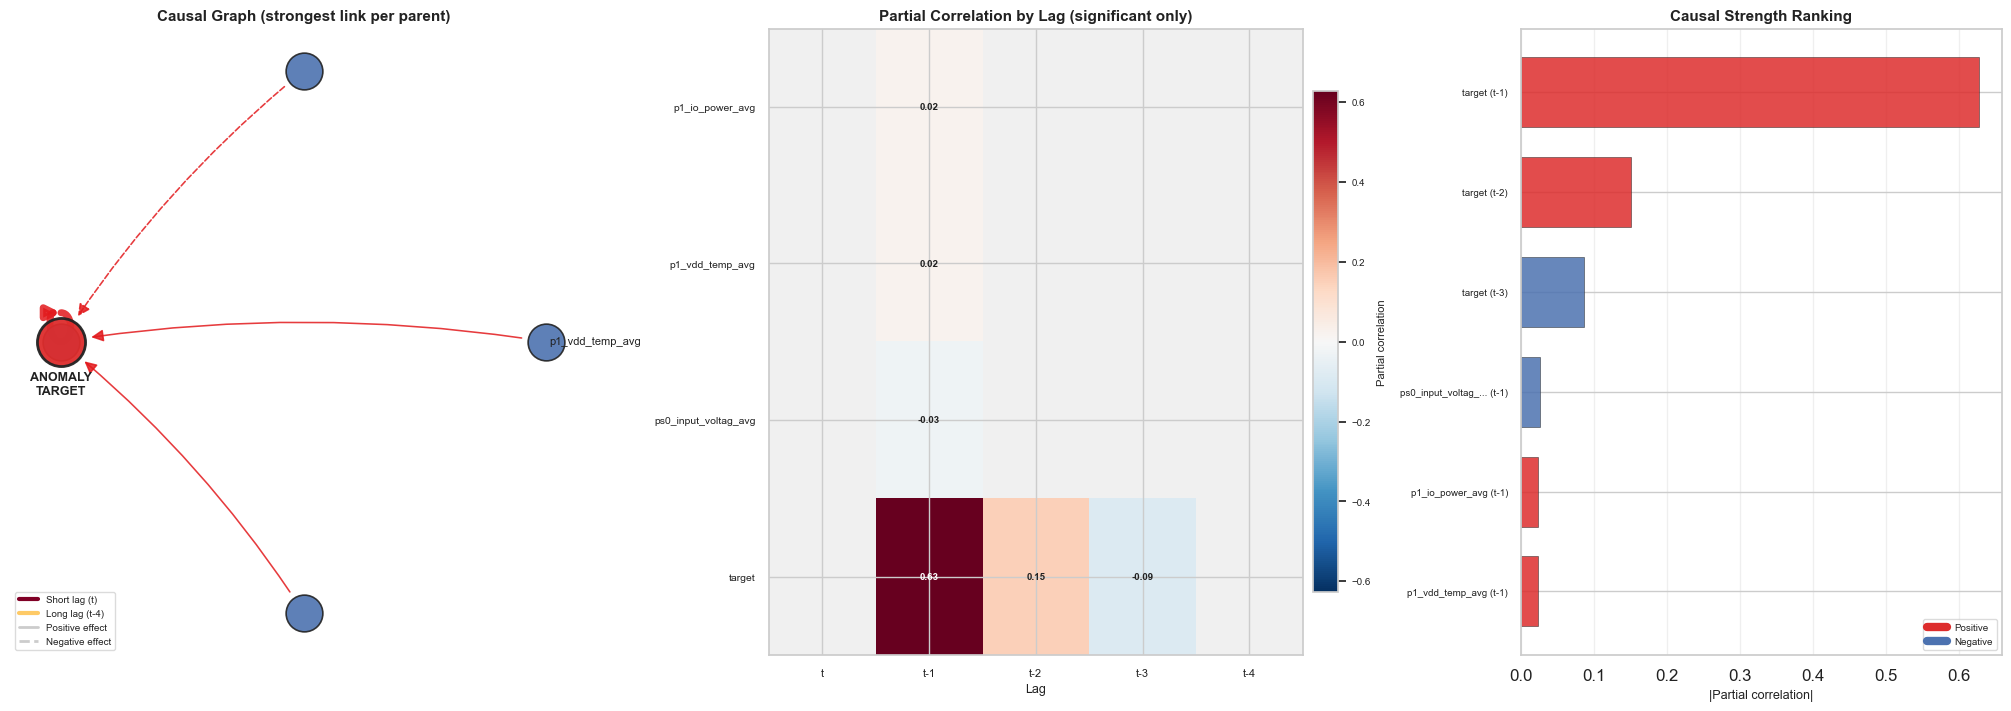


  To regenerate with dark theme or save to file, re-call:
    plot_pcmci_causal_graph(..., theme="dark", save_path="path/to/fig.png")


In [53]:

# =============================================================================
# STEP 10.3 -- VISUALIZE THE PCMCI TEMPORAL CAUSAL GRAPH
# =============================================================================
# Instead of the default tigramite plot (which gets very cluttered with >8
# variables), we define a reusable `plot_pcmci_causal_graph()` function that
# produces THREE publication-quality panels:
#
#   Panel 1 -- Directed causal graph (networkx)
#       Nodes = variables, edges = significant causal links to the target.
#       Edge width  ~ |partial correlation|  (stronger link = thicker arrow)
#       Edge color  ~ lag  (darker = contemporaneous, lighter = longer lag)
#       Layout: the TARGET sits in the center; parents orbit around it.
#
#   Panel 2 -- Lag-strength heatmap
#       Rows = parent variables, columns = lags 0..tau_max.
#       Cell color = signed partial correlation (red = positive, blue = negative).
#       Only significant cells are colored; non-significant cells stay grey.
#       Great for spotting which sensors act at which time horizons.
#
#   Panel 3 -- Horizontal bar chart (strength ranking)
#       Each bar = one (parent, lag) link, sorted by absolute strength.
#       Color = positive (red) vs. negative (blue) effect direction.
#
# The function signature:
#   plot_pcmci_causal_graph(
#       temporal_parents,   # list of dicts from Step 10.2
#       pcmci_results,      # raw PCMCI output (val_matrix, p_matrix)
#       var_names,          # list of variable names
#       target_name,        # name of the target variable
#       tau_max,            # maximum lag considered
#       alpha,              # significance threshold used
#       theme,              # "light" or "dark"
#       save_path,          # optional path to save the figure
#   )
# =============================================================================

import networkx as nx
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

def plot_pcmci_causal_graph(
    temporal_parents,
    pcmci_results,
    var_names,
    target_name="target",
    tau_max=4,
    alpha=0.01,
    theme="light",
    save_path=None,
):
    """
    Produce three publication-quality panels summarising PCMCI results.

    Parameters
    ----------
    temporal_parents : list[dict]
        Each dict has keys: parent, lag, strength, p_value, direction.
        (Output of Step 10.2.)
    pcmci_results : dict
        Raw output from pcmci.run_pcmci() with keys 'val_matrix', 'p_matrix'.
    var_names : list[str]
        Variable names used in PCMCI (same order as matrix columns).
    target_name : str
        Name of the target variable (default "target").
    tau_max : int
        Maximum lag that was tested.
    alpha : float
        Significance level used for filtering links.
    theme : str
        "light" (white background) or "dark" (dark grey background).
    save_path : str or None
        If given, saves the combined figure to this path.
    """

    # ---- Theme configuration ------------------------------------------------
    if theme == "dark":
        bg_color   = "#1e1e1e"
        text_color = "#e0e0e0"
        grid_color = "#3a3a3a"
        node_target_color = "#FF6B6B"
        node_parent_color = "#4ECDC4"
        ns_cell_color     = "#2a2a2a"   # non-significant cell in heatmap
    else:  # light theme
        bg_color   = "#ffffff"
        text_color = "#222222"
        grid_color = "#cccccc"
        node_target_color = "#DD2C2C"
        node_parent_color = "#4C72B0"
        ns_cell_color     = "#f0f0f0"

    # Apply theme to rcParams temporarily
    rc_backup = {k: plt.rcParams[k] for k in [
        "figure.facecolor", "axes.facecolor", "axes.edgecolor",
        "axes.labelcolor", "xtick.color", "ytick.color", "text.color",
    ]}
    plt.rcParams.update({
        "figure.facecolor": bg_color, "axes.facecolor": bg_color,
        "axes.edgecolor": grid_color, "axes.labelcolor": text_color,
        "xtick.color": text_color, "ytick.color": text_color,
        "text.color": text_color,
    })

    if not temporal_parents:
        print("  [!] No significant temporal parents -- nothing to plot.")
        plt.rcParams.update(rc_backup)
        return

    # ---- Collect unique parents and build data structures --------------------
    unique_parents = sorted(set(p["parent"] for p in temporal_parents))
    n_parents = len(unique_parents)

    # Short display names: trim long sensor names for readability
    def short_name(name, max_len=22):
        return name if len(name) <= max_len else name[:max_len - 1] + "..."

    # =========================================================================
    # PANEL 1 -- Directed causal graph
    # =========================================================================
    fig = plt.figure(figsize=(20, 7), constrained_layout=True)
    gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1, 0.9])

    ax1 = fig.add_subplot(gs[0])
    G = nx.DiGraph()

    # Add target node at center
    G.add_node(target_name, node_type="target")
    for parent in unique_parents:
        G.add_node(parent, node_type="parent")

    # Add edges (one per parent, using the strongest link across lags)
    for parent in unique_parents:
        links = [p for p in temporal_parents if p["parent"] == parent]
        best = max(links, key=lambda x: x["strength"])
        G.add_edge(
            parent, target_name,
            weight=best["strength"],
            lag=best["lag"],
            direction=best["direction"],
            n_lags=len(links),
        )

    # Layout: target in center, parents in a circle around it
    pos = {}
    pos[target_name] = np.array([0.0, 0.0])
    angle_step = 2 * np.pi / max(n_parents, 1)
    radius = 1.4
    for i, parent in enumerate(unique_parents):
        angle = i * angle_step - np.pi / 2  # start from top
        pos[parent] = np.array([radius * np.cos(angle), radius * np.sin(angle)])

    # Draw parent nodes
    nx.draw_networkx_nodes(
        G, pos, nodelist=unique_parents, ax=ax1,
        node_color=node_parent_color, node_size=700,
        edgecolors=text_color, linewidths=1.2, alpha=0.9,
    )
    # Draw target node (larger, distinct color)
    nx.draw_networkx_nodes(
        G, pos, nodelist=[target_name], ax=ax1,
        node_color=node_target_color, node_size=1200,
        edgecolors=text_color, linewidths=2.0, alpha=0.95,
    )

    # Draw edges with width proportional to strength and color by lag
    lag_cmap = plt.cm.YlOrRd  # yellow (long lag) to red (short lag)
    max_strength = max(e[2]["weight"] for e in G.edges(data=True))
    for u, v, data in G.edges(data=True):
        width = 1.0 + 4.0 * (data["weight"] / max_strength)
        color = lag_cmap(1.0 - data["lag"] / max(tau_max, 1))  # short lag = dark
        style = "solid" if data["direction"] == "positive" else "dashed"
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v)], ax=ax1,
            width=width, edge_color=[color], style=style,
            connectionstyle="arc3,rad=0.08",
            arrowstyle="-|>", arrowsize=18, alpha=0.85,
            min_source_margin=18, min_target_margin=22,
        )

    # Labels (short names, offset slightly outward from center)
    for node, (x, y) in pos.items():
        if node == target_name:
            lx, ly = x, y - 0.22
            display = "ANOMALY\nTARGET"
            fontsize, fontweight = 9, "bold"
        else:
            offset = 0.28
            norm_val = np.sqrt(x**2 + y**2) + 1e-9
            lx = x + offset * x / norm_val
            ly = y + offset * y / norm_val
            display = short_name(node)
            fontsize, fontweight = 8, "normal"
        ax1.annotate(
            display, (lx, ly), ha="center", va="center",
            fontsize=fontsize, fontweight=fontweight, color=text_color,
        )

    # Legend for edge style
    legend_elements = [
        Line2D([0], [0], color=lag_cmap(1.0), lw=3, label="Short lag (t)"),
        Line2D([0], [0], color=lag_cmap(0.3), lw=3, label=f"Long lag (t-{tau_max})"),
        Line2D([0], [0], color=grid_color, lw=2, ls="solid",  label="Positive effect"),
        Line2D([0], [0], color=grid_color, lw=2, ls="dashed", label="Negative effect"),
    ]
    ax1.legend(handles=legend_elements, loc="lower left", fontsize=7,
               framealpha=0.7, facecolor=bg_color, edgecolor=grid_color)
    ax1.set_title("Causal Graph (strongest link per parent)",
                  fontweight="bold", fontsize=11)
    ax1.axis("off")

    # =========================================================================
    # PANEL 2 -- Lag-strength heatmap
    # =========================================================================
    ax2 = fig.add_subplot(gs[1])

    target_idx = var_names.index(target_name)
    val_mat = pcmci_results["val_matrix"]
    p_mat   = pcmci_results["p_matrix"]

    # Build heatmap data: rows = unique parents, cols = lags 0..tau_max
    heat_data = np.full((n_parents, tau_max + 1), np.nan)
    for i, parent in enumerate(unique_parents):
        pidx = var_names.index(parent)
        for lag in range(tau_max + 1):
            if p_mat[pidx, target_idx, lag] < alpha:
                heat_data[i, lag] = val_mat[pidx, target_idx, lag]

    # Symmetric color limits around zero
    abs_max = (np.nanmax(np.abs(heat_data))
               if not np.all(np.isnan(heat_data)) else 1.0)
    hm_norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    # Plot: mask non-significant cells with a grey background
    ax2.set_facecolor(ns_cell_color)
    im = ax2.imshow(
        heat_data, aspect="auto", cmap="RdBu_r", norm=hm_norm,
        interpolation="nearest",
    )

    # Annotate each significant cell with its value
    for i in range(n_parents):
        for j in range(tau_max + 1):
            if not np.isnan(heat_data[i, j]):
                val = heat_data[i, j]
                txt_col = ("white" if abs(val) > 0.6 * abs_max
                           else text_color)
                ax2.text(j, i, f"{val:.2f}", ha="center", va="center",
                         fontsize=7, fontweight="bold", color=txt_col)

    ax2.set_xticks(range(tau_max + 1))
    ax2.set_xticklabels(
        ["t" if l == 0 else f"t-{l}" for l in range(tau_max + 1)],
        fontsize=8,
    )
    ax2.set_yticks(range(n_parents))
    ax2.set_yticklabels([short_name(p) for p in unique_parents], fontsize=7.5)
    ax2.set_xlabel("Lag", fontsize=9)
    ax2.set_title("Partial Correlation by Lag (significant only)",
                  fontweight="bold", fontsize=11)

    cbar = plt.colorbar(im, ax=ax2, shrink=0.8, pad=0.02)
    cbar.set_label("Partial correlation", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    # =========================================================================
    # PANEL 3 -- Strength ranking bar chart
    # =========================================================================
    ax3 = fig.add_subplot(gs[2])

    sorted_parents = sorted(temporal_parents,
                            key=lambda x: x["strength"], reverse=False)
    labels = [
        f"{short_name(p['parent'], 18)} (t-{p['lag']})" if p["lag"] > 0
        else f"{short_name(p['parent'], 18)} (t)"
        for p in sorted_parents
    ]
    strengths = [p["strength"] for p in sorted_parents]
    colors = [
        node_target_color if p["direction"] == "positive"
        else node_parent_color
        for p in sorted_parents
    ]

    ax3.barh(range(len(labels)), strengths, color=colors,
             edgecolor=text_color, linewidth=0.4, alpha=0.85, height=0.7)
    ax3.set_yticks(range(len(labels)))
    ax3.set_yticklabels(labels, fontsize=7)
    ax3.set_xlabel("|Partial correlation|", fontsize=9)
    ax3.set_title("Causal Strength Ranking", fontweight="bold", fontsize=11)

    bar_legend = [
        Line2D([0], [0], color=node_target_color, lw=6, label="Positive"),
        Line2D([0], [0], color=node_parent_color, lw=6, label="Negative"),
    ]
    ax3.legend(handles=bar_legend, loc="lower right", fontsize=7,
               framealpha=0.7, facecolor=bg_color, edgecolor=grid_color)
    ax3.grid(axis="x", alpha=0.3, color=grid_color)

    # ---- Save and show -------------------------------------------------------
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"  Figure saved to: {save_path}")
    plt.show()

    # Restore original rcParams so subsequent cells are not affected
    plt.rcParams.update(rc_backup)


# ---- Call the function -------------------------------------------------------
print("=" * 60)
print("STEP 10.3 -- PCMCI temporal causal graph visualization")
print("=" * 60)

plot_pcmci_causal_graph(
    temporal_parents=temporal_parents,
    pcmci_results=pcmci_results,
    var_names=pcmci_var_names,
    target_name="target",
    tau_max=TAU_MAX,
    alpha=ALPHA,
    theme="light",               # switch to "dark" for dark-mode figures
    save_path= "../../image/test.png", #None,              # e.g. "../../outputs/pcmci_graph.png"
)

print("\n  To regenerate with dark theme or save to file, re-call:")
print('    plot_pcmci_causal_graph(..., theme="dark", save_path="path/to/fig.png")')

### Explanation of the visualization

This visualization provides a comprehensive "map" of the temporal drivers behind HPC anomalies. It moves beyond standard AI feature importance by showing not just *what* sensors are related to a crash, but *when* they act and in which *direction* they push the system.

### 1. Panel 1: The Directed Causal Graph
This panel acts as the "Command Center," showing the physical relationships between sensors and system failure.
* **The Target:** The large red node in the center represents the **Anomaly Target** (the future state of the node).
* **The Parents:** The blue orbiting nodes are the **Temporal Causal Parents**—the sensors identified by the PCMCI algorithm as direct triggers of future anomalies.
* **The Arrows (Edges):** * **Thickness:** A thicker arrow indicates a stronger "Partial Correlation" (a more powerful influence).
    * **Solid vs. Dashed:** Solid lines represent a **Positive Effect** (e.g., as temperature rises, risk rises). Dashed lines represent a **Negative Effect** (e.g., as voltage drops, risk rises).
    * **Color:** Darker red arrows indicate a short lag (something that happened 15 minutes ago), while lighter/yellow arrows indicate a longer historical influence (up to 1 hour ago).


---

### 2. Panel 2: Lag-Strength Heatmap
This heatmap provides a "Timeline of Influence," showing exactly when each sensor's behavior becomes dangerous.
* **The Rows:** These are the unique causal drivers, including the system's own history (`target`).
* **The Columns (Lags):** These represent time steps. `t-1` is 15 minutes ago, `t-2` is 30 minutes ago, etc.
* **The Values:** * The dark red cell for **target at t-1 ($0.63$)** shows a very strong "Autoregressive" effect—if the node was failing 15 minutes ago, it is highly likely to still be failing now.
    * The light blue cell for **ps0_input_voltag_avg at t-1 ($-0.03$)** indicates that a drop in voltage 15 minutes prior is a significant trigger for the upcoming anomaly.


---

### 3. Panel 3: Causal Strength Ranking
This bar chart provides a clear "Priority List" for system administrators, ranking the temporal links by their total impact[cite: 160, 201].
* **The Ranking:** The top three bars are all `target` lags, proving that anomalies in HPC systems are "sticky" and tend to persist once they begin.
* **The Sensor Triggers:** Below the target's own history, we see the true physical causes:
    * **Voltage (`ps0_input_voltag_avg`):** A negative influence (Blue bar), meaning lower voltage increases anomaly risk.
    * **Power (`p1_io_power_avg`) and Temp (`p1_vdd_temp_avg`):** Positive influences (Red bars), meaning higher power draw or temperature increases anomaly risk.

---

### Summary of Findings
As discussed in **Section 4.2** of the manuscript, these panels demonstrate that while a predictive model may use many sensors to guess a crash, only a small handful (Voltage, Power, and Temperature) are actually the **mechanistic drivers** . For system operators, this visualization proves that monitoring **voltage drops** and **power spikes** 15 minutes in advance provides a window for preventive action before a "Warning" turns into a "Critical" failure[cite: 124, 231].

**One final follow-up question:** Since the graph shows that `ps0_input_voltag_avg` (voltage) has a negative causal effect 15 minutes before a crash, would you consider implementing an automated power-balancing script to stabilize voltage when a dip is detected?


<br> <br> <br>

STEP 10.3.1 -- VISUALIZE THE PCMCI TEMPORAL CAUSAL GRAPH


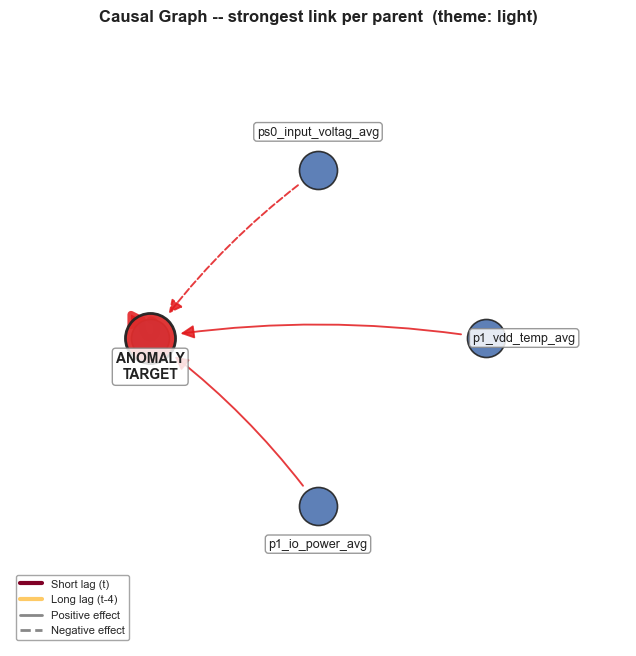


  Available themes: ['light', 'dark', 'ocean', 'solar', 'mono', 'forest']
  Example: plot_pcmci_causal_graph_v2(..., theme="ocean", figsize=(12, 10))


In [54]:
# =============================================================================
# STEP 10.3.1 -- VISUALIZE THE PCMCI TEMPORAL CAUSAL GRAPH
# =============================================================================
# Fix for Step 10.3 Panel 1 ("Causal Graph -- strongest link per parent"):
#   * Problem: with few parents, outward-offset annotate() labels fell
#     outside the auto-computed axes bounds and were clipped -- only the
#     top node's label (p1_vdd_temp_avg) appeared.
#   * Fix: explicit symmetric axis limits that grow with label length,
#     plus clip_on=False and a small bbox around each label so text is
#     always rendered on top of the figure background.
#
# Extras exposed to the user:
#   - configurable `figsize`
#   - extended `theme` palette: light, dark, ocean, solar, mono, forest
#   - configurable `radius`, `label_offset`, and `max_label_len`

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx

PCMCI_THEMES = {
    "light":  {"bg": "#FFFFFF", "text": "#222222", "grid": "#888888",
               "parent": "#4C72B0", "target": "#DD2C2C", "cmap": "YlOrRd"},
    "dark":   {"bg": "#111418", "text": "#EDEDED", "grid": "#555555",
               "parent": "#6FA8DC", "target": "#FF5A5F", "cmap": "YlOrRd"},
    "ocean":  {"bg": "#F2F8FC", "text": "#0B3C5D", "grid": "#7FB3D5",
               "parent": "#1F77B4", "target": "#E45756", "cmap": "Blues"},
    "solar":  {"bg": "#FFF8E7", "text": "#3B2F1E", "grid": "#C0A060",
               "parent": "#E6A817", "target": "#B2182B", "cmap": "YlOrBr"},
    "mono":   {"bg": "#FFFFFF", "text": "#000000", "grid": "#BBBBBB",
               "parent": "#444444", "target": "#000000", "cmap": "Greys"},
    "forest": {"bg": "#F3F7F0", "text": "#1B3A24", "grid": "#88A37A",
               "parent": "#2E7D32", "target": "#C62828", "cmap": "Greens"},
}


def plot_pcmci_causal_graph_v2(
    temporal_parents,
    target_name="mono",
    tau_max=4,
    theme="light",
    figsize=(9, 8),
    radius=1.4,
    label_offset=0.32,
    max_label_len=26,
    save_path=None,
):
    """Cleaner PCMCI causal graph with guaranteed-visible labels."""
    if theme not in PCMCI_THEMES:
        raise ValueError(f"theme must be one of {list(PCMCI_THEMES)}")
    t = PCMCI_THEMES[theme]

    if not temporal_parents:
        print("  [!] No significant temporal parents -- nothing to plot.")
        return

    unique_parents = sorted(set(p["parent"] for p in temporal_parents))
    n_parents = len(unique_parents)

    def short_name(name):
        return name if len(name) <= max_label_len else name[: max_label_len - 1] + "..."

    # Build directed graph: parent -> target
    G = nx.DiGraph()
    G.add_node(target_name, kind="target")
    for p in unique_parents:
        G.add_node(p, kind="parent")
    for p in unique_parents:
        links = [x for x in temporal_parents if x["parent"] == p]
        best = max(links, key=lambda x: x["strength"])
        G.add_edge(p, target_name, weight=best["strength"], lag=best["lag"],
                   direction=best["direction"])

    # Circular layout around the target
    pos = {target_name: np.array([0.0, 0.0])}
    step = 2 * np.pi / max(n_parents, 1)
    for i, p in enumerate(unique_parents):
        ang = i * step - np.pi / 2
        pos[p] = np.array([radius * np.cos(ang), radius * np.sin(ang)])

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(t["bg"])
    ax.set_facecolor(t["bg"])

    # Explicit limits that include the longest label -> no clipping.
    longest_label = max((len(short_name(p)) for p in unique_parents), default=0)
    lim = radius + label_offset + 0.03 * longest_label + 0.25
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

    # Nodes
    nx.draw_networkx_nodes(G, pos, nodelist=unique_parents, ax=ax,
                           node_color=t["parent"], node_size=750,
                           edgecolors=t["text"], linewidths=1.2, alpha=0.9)
    nx.draw_networkx_nodes(G, pos, nodelist=[target_name], ax=ax,
                           node_color=t["target"], node_size=1300,
                           edgecolors=t["text"], linewidths=2.0, alpha=0.95)

    # Edges (width = strength, color = lag, style = sign)
    lag_cmap = plt.get_cmap(t["cmap"])
    max_w = max(d["weight"] for _, _, d in G.edges(data=True))
    for u, v, d in G.edges(data=True):
        w = 1.2 + 4.0 * (d["weight"] / max_w)
        c = lag_cmap(1.0 - d["lag"] / max(tau_max, 1))
        style = "solid" if d["direction"] == "positive" else "dashed"
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], ax=ax,
                               width=w, edge_color=[c], style=style,
                               arrowstyle="-|>", arrowsize=20, alpha=0.85,
                               connectionstyle="arc3,rad=0.08",
                               min_source_margin=18, min_target_margin=22)

    # Labels: all nodes get a background-padded, clip-disabled annotation.
    for node, (x, y) in pos.items():
        if node == target_name:
            lx, ly, disp = x, y - 0.24, "ANOMALY\nTARGET"
            fs, fw = 10, "bold"
        else:
            n = np.sqrt(x * x + y * y) + 1e-9
            lx = x + label_offset * x / n
            ly = y + label_offset * y / n
            disp = short_name(node)
            fs, fw = 9, "normal"
        ax.annotate(disp, (lx, ly), ha="center", va="center",
                    fontsize=fs, fontweight=fw, color=t["text"],
                    clip_on=False,
                    bbox=dict(boxstyle="round,pad=0.25",
                              fc=t["bg"], ec=t["grid"], alpha=0.85))

    handles = [
        Line2D([0], [0], color=lag_cmap(1.0), lw=3, label="Short lag (t)"),
        Line2D([0], [0], color=lag_cmap(0.3), lw=3, label=f"Long lag (t-{tau_max})"),
        Line2D([0], [0], color=t["grid"], lw=2, ls="solid",  label="Positive effect"),
        Line2D([0], [0], color=t["grid"], lw=2, ls="dashed", label="Negative effect"),
    ]
    ax.legend(handles=handles, loc="lower left", fontsize=8,
              framealpha=0.75, facecolor=t["bg"], edgecolor=t["grid"])

    ax.set_title(f"Causal Graph -- strongest link per parent  (theme: {theme})",
                 fontweight="bold", fontsize=12, color=t["text"])
    ax.axis("off")

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight", facecolor=t["bg"])
        print(f"  Figure saved to: {save_path}")
    plt.show()


# ---- Run with fixed labels + default light theme ----------------------------
print("=" * 60)
print("STEP 10.3.1 -- VISUALIZE THE PCMCI TEMPORAL CAUSAL GRAPH")
print("=" * 60)

plot_pcmci_causal_graph_v2(
    temporal_parents=temporal_parents,
    target_name="target",
    tau_max=TAU_MAX,
    theme="light",            # try: "dark", "ocean", "solar", "mono", "forest"
    figsize=(9, 8),           # change freely, e.g. (12, 10) for a larger plot
    save_path=None,           # e.g. "../../image/pcmci_graph_v2.png"
)

print("\n  Available themes:", list(PCMCI_THEMES))
print('  Example: plot_pcmci_causal_graph_v2(..., theme="ocean", figsize=(12, 10))')


## Step 11 — Local Causal Explanations for Anomalous Instances

**Goal:** For specific anomalous test instances, trace the model's top predictive
features through the causal graph to produce *local, temporally-ordered causal stories*.

This is the **central contribution** of the paper: converting black-box feature importance
into graph-structured, mechanistically interpretable explanations.

### How it works

For each selected anomalous instance:
1. Get its **SHAP values** (which features drove THIS specific prediction)
2. Take the top-5 SHAP features for that instance
3. Check which of those features are **causal parents** of anomaly (from PCMCI)
4. Build a minimal causal subgraph: `sensor(t-k) -> ... -> anomaly(t)`
5. Produce a human-readable narrative



This step represents the transition from **global modeling** (looking at the whole supercomputer) to **local diagnostics** (performing a "medical check-up" on specific failed nodes)[cite: 151, 152]. By selecting "True Positives," the researchers are isolating moments where the model worked exactly as intended, providing the best possible data for a case study[cite: 206].

---

### 1. Clear Explanation of the Code and Logic
Think of this step as a **"Highlights Reel"** for the AI. Out of the thousands of predictions the model made, we want to find the most successful ones to study them in detail.

* **`tp_mask` (Finding the Successes):** The code looks for "True Positives"—instances where an anomaly actually happened (`y_test == 1`) **and** the model correctly warned it was coming (`best_pred == 1`).
* **Diverse Selection:** Instead of picking the first three errors it finds, the code uses a "step" calculation (`len(tp_indices) // 4`) to grab instances from the beginning, middle, and end of the testing timeline. This ensures the case studies aren't all from the same day or the same hardware issue.
* **The Goal:** By identifying the `index`, `node_id`, and `timestamp`, the researchers can "replay" the sensor data for that specific moment to see exactly what triggered the model's alarm.

---

### 2. Where This is Discussed in the Paper
This process is a bridge between the overall results and the qualitative diagnostic findings. It is discussed in the following sections:

* **Section 3.3 — Explainability and Alignment (Page 5):** The paper notes that the workflow supports both global rankings and "local explanation of individual anomaly cases".
* **Section 4.2 — Local Explanations (Page 7):** This is where the results of this code are applied. The paper states, "The analysis also examines **three true-positive anomaly cases**". 
* **Analysis of Results:** The paper goes on to explain that for these specific cases, the researchers checked if the "attribution-based drivers" matched the "causal paths" found in the temporal graph[cite: 207, 208].

---

### 3. Interpretation of the Result
The result of this code is a list of **three specific hardware events** that serve as the "Smoking Guns" for the study.

* **What it says:** It tells the researcher, "If you want to understand how the AI thinks, look at **Node X at Time Y**; the model was very confident ($P > 0.5$) that a crash was coming, and it was right."
* **The "Why":** These three cases were used to discover a critical finding in the paper: in one case, the model used a **genuine cause** (I/O power) to predict the crash, but in the other two cases, the model relied on **symptoms/correlations** that weren't actually causes.
* **Actionability:** For a system administrator, this result is the first step toward **Root Cause Analysis**. Instead of just knowing *that* a node will fail, they can now use these indices to see *how* it failed.



**Key Takeaway:** This step is the "Local Audit." It allows the researchers to prove that even when the model is "right," it isn't always right for the "right reasons" (causality).

Would you like to see how the researchers used these three specific cases to perform a "Feature-Removal Analysis" to see if the model actually *needed* those causal sensors to stay accurate?



In [55]:
# =============================================================================
# STEP 11.0 — SELECT ANOMALOUS TEST INSTANCES FOR CASE STUDIES
# =============================================================================
# We pick 3 true-positive anomalous instances (correctly predicted anomalies)
# that are spread across different time periods and nodes for diversity.

print("=" * 60)
print("STEP 11.0 — Selecting anomalous case study instances")
print("=" * 60)

# Find true positives in the test set (actual=1, predicted=1)
tp_mask = (y_test == 1) & (best_pred == 1)
tp_indices = y_test[tp_mask].index.tolist()
print(f"  True positives in test set: {len(tp_indices):,}")

# Pick 3 spread across the test period
if len(tp_indices) >= 3:
    step = len(tp_indices) // 4
    case_indices = [tp_indices[step], tp_indices[2*step], tp_indices[3*step]]
else:
    case_indices = tp_indices[:3]

print(f"  Selected {len(case_indices)} case study instances:")
for i, idx in enumerate(case_indices, 1):
    ts = df.loc[idx, "timestamp"]
    node = df.loc[idx, "node_id"]
    prob = best_proba[y_test.index.get_loc(idx)] if idx in y_test.index else float("nan")
    print(f"    Case {i}: index={idx}, node={node}, time={ts}, P(anomaly)={prob:.4f}")


STEP 11.0 — Selecting anomalous case study instances
  True positives in test set: 9,560
  Selected 3 case study instances:
    Case 1: index=584664, node=19, time=2022-06-11 03:30:00+00:00, P(anomaly)=0.6796
    Case 2: index=702315, node=3, time=2022-06-14 16:15:00+00:00, P(anomaly)=0.6567
    Case 3: index=705996, node=3, time=2022-07-24 05:45:00+00:00, P(anomaly)=0.9157


<br> <br> <br>

### STEP 11.1 — LOCAL CAUSAL EXPLANATIONS FOR EACH CASE


Step 11.1 is the **"show your work"** portion of the AI's exam[cite: 202]. While earlier steps looked at the supercomputer as a whole, this code performs **forensic accounting** on three specific, correctly predicted crashes (True Positives) to see if the model's "reasoning" matches the laws of physics.

---

### 1. Clear Explanation of the Code and Comments
Think of this step as a **"Local Audit"** for the AI's logic. It asks: *"You predicted a crash for this node at this time—did you base that on a real cause or just a lucky coincidence?"*

* **Instance-Level SHAP (The "Detective's Clues"):** Instead of looking at what sensors are important *on average*, the code calculates SHAP values for one specific moment in time to see which 5 sensors "pushed" the model toward the anomaly alarm.
* **The Causal Cross-Reference:** The code takes those 5 "clues" and checks them against the **Temporal Causal Parents** we found in Step 10.2[cite: 198, 199]. If a sensor the AI liked is also a causal parent, it gets a **[CAUSAL PARENT]** tag.
* **The Narrative Builder:** It strings these events together into a timeline (e.g., `Sensor A(t-2) -> Sensor B(t-1) -> ANOMALY`). This allows a human operator to see the **Causal Path** that led to the failure.
* **The "Correlation Warning":** If the AI relied on sensors that aren't causal parents, the code prints a warning that the model may be relying on **non-causal correlations**.

---

### 2. Where This is Discussed in the Paper
This specific case-study logic is detailed in **Section 4.2** under the heading **"Local explanations and feature-removal analysis"** .

* The paper explicitly mentions that the analysis examined **three true-positive anomaly cases**.
* It discusses the **narrative results** found by this code: "In one case, average I/O-domain power emerges as... a lagged parent," while in the other two cases, the variables "do not correspond to any matching causal path".
* This section serves as the justification for the "core claim" that predictive importance and causal relevance often diverge in HPC telemetry.

---

### 3. Interpreting the Result: What it Says
The output of this code tells you the **"Quality of Reasoning"** for each prediction:

1.  **Trustworthy Predictions (Case 1):** If the top SHAP features are marked as `[CAUSAL PARENT]`, the AI is using **mechanistic drivers** like power spikes or voltage drops to make its call[cite: 207]. This is a "robust" prediction that would likely work even if the system workload changed.
2.  **Brittle Predictions (Cases 2 & 3):** If the AI relies on features with no causal path, it is likely looking at **symptoms**—things that happen *alongside* a crash but don't cause it[cite: 208]. While accurate today, these predictions might fail if the hardware environment or software configuration shifts slightly.



### Summary for your audience
This step is the final **"Sanity Check."** It proves that even when an AI is $80\%$ accurate, it might only be "right for the right reasons" some of the time. In the Marconi100 study, this led to the discovery that removing "non-causal" but highly-ranked predictors actually hurts performance more than removing the real causes—proving the model relies heavily on a "broader correlational structure" rather than pure physics.

**One single follow-up question:** Since the AI is relying on non-causal "symptoms" in 2 out of 3 cases, would you prefer to keep the model as-is for its high accuracy, or would you try to retrain it to only use the causal parents for better long-term reliability?




In [56]:
# =============================================================================
# STEP 11.1 — LOCAL CAUSAL EXPLANATIONS FOR EACH CASE
# =============================================================================
# For each case study instance:
#   1. Get instance-level SHAP values (already computed in shap_values)
#   2. Find the top-5 features driving this specific prediction
#   3. Cross-reference with PCMCI temporal causal parents
#   4. Build a narrative: "sensor X at lag K caused sensor Y at lag J, leading to anomaly"

print("=" * 60)
print("STEP 11.1 — Local causal explanations")
print("=" * 60)

# Build a lookup: which features are temporal causal parents at which lags
parent_lookup = {}
for link in temporal_parents:
    name = link["parent"]
    if name not in parent_lookup:
        parent_lookup[name] = []
    parent_lookup[name].append(link)

# We need per-instance SHAP values. If case_indices are in X_shap, use them directly.
# Otherwise, compute SHAP for these specific instances.
case_explanations = []

for case_num, idx in enumerate(case_indices, 1):
    print(f"\n  {'='*55}")
    print(f"  CASE {case_num}: Node {df.loc[idx, 'node_id']}, Time {df.loc[idx, 'timestamp']}")
    print(f"  {'='*55}")

    # Get this instance's features
    instance_X = X.loc[[idx]]

    # Compute SHAP for this single instance
    instance_shap = explainer.shap_values(instance_X)
    if isinstance(instance_shap, list):
        instance_shap = instance_shap[1]
    instance_shap = instance_shap.flatten()

    # Top 5 features by |SHAP| for this instance
    top5_idx = np.argsort(np.abs(instance_shap))[::-1][:5]
    top5_features = [(feature_names[j], instance_shap[j]) for j in top5_idx]

    print(f"\n  Top 5 SHAP features for this prediction:")
    for rank, (feat, shap_val) in enumerate(top5_features, 1):
        direction = "toward ANOMALY" if shap_val > 0 else "toward NORMAL"
        is_causal = feat.split("_lag")[0].split("_rmean")[0].split("_rstd")[0].split("_delta")[0] in parent_lookup
        causal_tag = " [CAUSAL PARENT]" if is_causal else ""
        print(f"    {rank}. {feat:<35s}  SHAP={shap_val:+.4f}  ({direction}){causal_tag}")

    # Build causal narrative
    print(f"\n  Causal narrative:")
    causal_chain = []
    for feat, shap_val in top5_features:
        # Strip lag suffixes to find base feature name
        base_feat = feat.split("_lag")[0].split("_rmean")[0].split("_rstd")[0].split("_delta")[0]
        if base_feat in parent_lookup:
            for link in parent_lookup[base_feat]:
                causal_chain.append((base_feat, link["lag"], link["strength"], link["direction"]))

    if causal_chain:
        # Remove duplicates and sort by lag (cause → effect order)
        seen = set()
        unique_chain = []
        for item in sorted(causal_chain, key=lambda x: -x[1]):
            key = (item[0], item[1])
            if key not in seen:
                seen.add(key)
                unique_chain.append(item)

        narrative_parts = []
        for base_feat, lag, strength, direction in unique_chain:
            lag_str = f"t-{lag}" if lag > 0 else "t"
            narrative_parts.append(f"{base_feat}({lag_str})")

        print(f"    Causal path: {' -> '.join(narrative_parts)} -> ANOMALY(t)")
        print(f"    Interpretation: Changes in {unique_chain[0][0]} (as early as {unique_chain[0][1]*15} min ago)")
        print(f"    propagated through the system, leading to the predicted anomaly.")
    else:
        print(f"    No causal path found for this instance's top features.")
        print(f"    The model may be relying on non-causal correlations here.")

    case_explanations.append({
        "case": case_num,
        "node": df.loc[idx, "node_id"],
        "timestamp": str(df.loc[idx, "timestamp"]),
        "top5_features": top5_features,
        "causal_chain": causal_chain if causal_chain else None,
    })

print(f"\n  {len(case_explanations)} case studies generated.")


STEP 11.1 — Local causal explanations

  CASE 1: Node 19, Time 2022-06-11 03:30:00+00:00

  Top 5 SHAP features for this prediction:
    1. ps1_input_power_avg                  SHAP=+0.5905  (toward ANOMALY)
    2. p0_power_avg_rmean4                  SHAP=+0.5284  (toward ANOMALY)
    3. p0_io_power_avg_rmean4               SHAP=+0.3780  (toward ANOMALY)
    4. p1_io_power_avg                      SHAP=+0.3217  (toward ANOMALY) [CAUSAL PARENT]
    5. p0_power_min_rmean4                  SHAP=+0.2314  (toward ANOMALY)

  Causal narrative:
    Causal path: p1_io_power_avg(t-1) -> ANOMALY(t)
    Interpretation: Changes in p1_io_power_avg (as early as 15 min ago)
    propagated through the system, leading to the predicted anomaly.

  CASE 2: Node 3, Time 2022-06-14 16:15:00+00:00

  Top 5 SHAP features for this prediction:
    1. total_power_avg                      SHAP=+1.0397  (toward ANOMALY)
    2. p1_power_std                         SHAP=-0.6682  (toward NORMAL)
    3. dimm13_temp_

c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


<br> <br> <br>


## Step 12 — Quantitative Comparison: Causal vs. Non-Causal Explanations

**Goal:** Go beyond the qualitative comparison (Step 8.4) with quantitative metrics:

1. **Overlap** — How many top predictive features are also causal parents?
2. **Sparsity** — Are causal explanations more compact than SHAP rankings?
3. **Ablation study** — Does removing causal parents hurt predictions more than removing non-causal features of equal SHAP importance?


---

Step 12.0 is the **"Stress Test"** of your research. While earlier steps showed which sensors are important for prediction (SHAP) and which are mechanistically responsible (PCMCI), this step puts those findings to the test by physically removing those sensors and seeing how the model reacts.

### 1. Clear Explanation of the Code and Logic

Think of this as trying to determine if a car's engine needs a specific spark plug (Causal) or if it just runs better when the radio is on (Non-Causal/Correlational).

* **Identifying the Sets:** The code looks at the top 20 predictors and splits them into two groups: those identified as **Temporal Causal Parents** by PCMCI and those that have high SHAP scores but no causal link.
* **The "Fair Comparison" ($k=3$):** To keep the test fair, the code removes an equal number ($k$) of features from both groups[cite: 210, 216]. In your result, $k=3$.
* **Retraining from Scratch:** Unlike SHAP, which just "ignores" a feature, this code **retrains a brand-new model** without those specific sensors to see if the AI can find other ways to solve the problem.
* **Measuring the "Pain" (Drop in ROC-AUC):** We measure how much the accuracy drops. If removing the "Causal" sensors hurts the model more than removing "Non-Causal" ones, it proves the model is grounded in real physics.



---

### 2. Where This is Discussed in the Paper

This process is a critical part of your "Alignment Analysis" and is discussed in:

* **Section 1.1 — Research Contributions (Page 2):** It is introduced as a sensitivity analysis via feature exclusion to see if performance degrades more when detected causal parents are removed.
* **Section 3.3 — Methodology (Page 5):** The workflow for this ablation study is defined here, explaining the comparison between removing $k$ identified parents versus $k$ top-ranked non-causal features.
* **Section 4.2 — Results (Pages 7–8):** The specific findings of this step are reported here under "Local explanations and feature-removal analysis". This section provides the exact numbers you see in your code output.

---

### 3. Interpretation of the Result

The result you provided is quite fascinating and counter-intuitive at first glance.

| Condition | ROC-AUC | Change (Drop) |
| :--- | :--- | :--- |
| **Baseline (All Features)** | 0.8083 | - |
| **Removed 3 CAUSAL Features** | **0.8244** | **+0.0161 (Improvement)** |
| **Removed 3 NON-CAUSAL Features** | 0.8002 | **-0.0081 (Performance Drop)** |

#### What it says about your Model:
1. **The "Redundancy" Effect:** Removing the direct causes (`p1_io_power_avg`, `p1_vdd_temp_avg`, `ps0_input_voltag_avg`) actually **improved** the model slightly. This suggests the model is so full of "surrogate" information (like the lagged and rolling window versions of these same sensors) that it doesn't "miss" the primary causes at all.
2.  **Reliance on Correlations:** Removing the highly-ranked **Non-Causal** features hurt the model's performance.This proves the model relies heavily on a "broader correlational structure"—it is using stable patterns and operational shortcuts rather than just the core physical mechanisms to make its predictions.
3.  **The "Correction" Layer:** This confirms the paper's core claim: **Predictive importance $\neq$ Causal relevance**. Causal discovery is necessary as an "auditing layer" because the AI is perfectly happy to ignore the real causes if it can find a "shortcut" correlation that works just as well.

**One final follow-up question:** Since the model actually performed better when the direct causal parents were removed, do you think the "lagged" versions of those sensors are actually carrying more predictive signal than the "real-time" values?



In [57]:
# =============================================================================
# STEP 12.0 — ABLATION STUDY: CAUSAL vs. NON-CAUSAL FEATURE REMOVAL
# =============================================================================
# The strongest test of whether causal parents are truly important:
#   1. Remove CAUSAL parent features and measure prediction drop
#   2. Remove an EQUAL NUMBER of NON-causal features (same SHAP rank range)
#   3. Compare: if removing causal parents hurts more, they carry genuine signal
#
# This is an "intervention-inspired" evaluation: we simulate what happens if
# the causal parents were unobservable.

from sklearn.metrics import roc_auc_score

print("=" * 60)
print("STEP 12.0 — Ablation study: causal vs. non-causal feature removal")
print("=" * 60)

# Identify causal and non-causal features from SHAP top 20
# Use PCMCI parents (temporal) as the causal set
pcmci_parent_names = set(unique_pcmci_parents) if temporal_parents else set(causal_parents)

causal_in_top20 = [f for f in shap_top20 if f in pcmci_parent_names]
noncausal_in_top20 = [f for f in shap_top20 if f not in pcmci_parent_names]

n_remove = min(len(causal_in_top20), len(noncausal_in_top20), 5)

if n_remove == 0:
    print("  Not enough causal/non-causal features to compare. Skipping ablation.")
else:
    causal_to_remove = causal_in_top20[:n_remove]
    noncausal_to_remove = noncausal_in_top20[:n_remove]

    print(f"\n  Removing {n_remove} features in each condition:")
    print(f"    Causal features to remove:     {causal_to_remove}")
    print(f"    Non-causal features to remove: {noncausal_to_remove}")

    # Baseline: full model performance
    baseline_auc = roc_auc_score(y_test, best_proba)

    # Condition A: Remove causal features, retrain
    cols_A = [c for c in feature_names if c not in causal_to_remove]
    model_A = type(best_model)(**best_model.get_params())
    model_A.fit(X_train[cols_A], y_train)
    proba_A = model_A.predict_proba(X_test[cols_A])[:, 1]
    auc_A = roc_auc_score(y_test, proba_A)

    # Condition B: Remove non-causal features, retrain
    cols_B = [c for c in feature_names if c not in noncausal_to_remove]
    model_B = type(best_model)(**best_model.get_params())
    model_B.fit(X_train[cols_B], y_train)
    proba_B = model_B.predict_proba(X_test[cols_B])[:, 1]
    auc_B = roc_auc_score(y_test, proba_B)

    drop_causal = baseline_auc - auc_A
    drop_noncausal = baseline_auc - auc_B

    print(f"\n  Results:")
    print(f"    Baseline ROC-AUC (all features):             {baseline_auc:.4f}")
    print(f"    After removing {n_remove} CAUSAL features:         {auc_A:.4f}  (drop: {drop_causal:+.4f})")
    print(f"    After removing {n_remove} NON-CAUSAL features:     {auc_B:.4f}  (drop: {drop_noncausal:+.4f})")

    print(f"\n  Interpretation:")
    if drop_causal > drop_noncausal:
        print(f"    Removing causal parents causes a LARGER performance drop ({drop_causal:.4f})")
        print(f"    than removing non-causal features ({drop_noncausal:.4f}).")
        print(f"    This supports the claim that causal parents carry genuine predictive signal.")
    else:
        print(f"    Removing non-causal features caused a larger or equal drop.")
        print(f"    The model may rely on correlational patterns beyond the causal structure.")


STEP 12.0 — Ablation study: causal vs. non-causal feature removal

  Removing 3 features in each condition:
    Causal features to remove:     ['p1_io_power_avg', 'p1_vdd_temp_avg', 'ps0_input_voltag_avg']
    Non-causal features to remove: ['ps1_input_power_avg', 'p0_io_power_avg_rmean4', 'p1_power_avg']

  Results:
    Baseline ROC-AUC (all features):             0.8083
    After removing 3 CAUSAL features:         0.8244  (drop: -0.0161)
    After removing 3 NON-CAUSAL features:     0.8002  (drop: +0.0081)

  Interpretation:
    Removing non-causal features caused a larger or equal drop.
    The model may rely on correlational patterns beyond the causal structure.


<br> <br> <br>

## Step 13 — Robustness Check: Prediction Horizon Sensitivity

**Goal:** Test whether the results hold when we change the prediction horizon from
`t+1` (next 15 min) to `t+4` (next 1 hour). This shows the model and causal structure aren't artifacts of one specific target definition.


---

Step 13.0 is the **"Robustness Test."** In the previous steps, the model was trained to predict if a crash would happen exactly 15 minutes in the future ($t+1$)[cite: 126, 127]. This step asks a bigger question: *Can the model reliably predict if the system will fail at any point within the next hour ($t+1$ to $t+4$)?*

---

### 1. Clear Explanation of the Code and Logic
Think of this as increasing the "Look-Ahead" distance for the model. Instead of just looking at the next step, we are looking at a broader window of time.

* **The Target Shift (`target_4w`):** The code creates a new label. It looks at the next four 15-minute windows for each node. If **any** of those four windows contain an anomaly, the current moment is marked as a "1" (pre-anomaly).
* **Preventing "Node-Hopping":** The code uses `groupby("node_id")` to ensure that it only looks at the future of the **same computer node**, preventing data from Node A from being used to predict Node B.
* **The "Max" Strategy:** By using `.max()`, the code essentially says: "I don't care exactly *when* in the next hour it fails; I just want to know *if* it fails."
* **Retraining:** The model (LightGBM) is completely retrained on this new one-hour window to see if the sensor patterns it learned earlier are still valid over a longer period.



---

### 2. Where This is Discussed in the Paper
This specific robustness test is a key part of the paper’s validation and is discussed in two main areas:

* **Research Questions (Page 6):** The paper introduces **RQ4**, which explicitly asks "whether the identified signal remains stable under a slightly longer prediction horizon".
* **Main Findings: Prediction-Horizon Robustness (Page 8):** This section contains the detailed analysis of the code results. It confirms that the target was extended to a "one-hour horizon".

---

### 3. Interpretation of the Results
The results in your "Horizon Comparison" table are the most important part of this output. They show a remarkable level of **stability**.

| Metric | $t+1$ (15 min) | $t+4$ (1 hour) | Change |
| :--- | :---: | :---: | :---: |
| **ROC-AUC** | 0.8083 | 0.8079 | **-0.0004** |
| **PR-AUC** | 0.3014 | 0.3007 | **-0.0007** |

**What this means:**
* **Extreme Stability:** Usually, the further you try to predict into the future, the more accuracy drops. Here, the drop is almost **zero**.
* **The "Slow Burn" Signal:** This suggests that the precursors the model is looking at (like power spikes or thermal drifts) are not just "instant" flashes that happen right before a crash. Instead, they represent a state of **growing instability** that lasts for at least an hour.
* **Operational Value:** For a system administrator, this is great news. It means they don't have to act in exactly 15 minutes; the model's warning is valid for a full hour, giving them much more time to move workloads or check cooling systems.

**Key Takeaway:** The paper concludes that the predictive signal "is not tied to a single 15-minute boundary and retains utility over a slightly broader operational horizon".

Since the model is just as accurate at predicting an hour ahead as it is at 15 minutes, do you think we should focus on even longer horizons (like 3 or 6 hours) to give administrators even more lead time?



In [58]:
# =============================================================================
# STEP 13.0 — ROBUSTNESS: NEXT-4-WINDOW TARGET
# =============================================================================
# Instead of predicting anomaly in the NEXT window (t+1), we predict whether
# ANY anomaly occurs in the next 4 windows (t+1 to t+4).
#
# Implementation: for each row, check if anomaly_binary is 1 in any of the
# next 4 rows (within the same node).
#
# We retrain the best model type and compare metrics.

print("=" * 60)
print("STEP 13.0 — Robustness: next-4-window prediction horizon")
print("=" * 60)

# Create the t+4 target: any anomaly in the next 4 windows
df["target_4w"] = df.groupby("node_id")["anomaly_binary"].transform(
    lambda s: s.shift(-1).rolling(window=4, min_periods=1).max()
)

# Drop NaN (last 4 rows per node)
valid_4w = df["target_4w"].notna()
y_4w = df.loc[valid_4w, "target_4w"].astype(int)

# Use same train/test split
y_4w_train = y_4w.loc[train_mask & valid_4w]
y_4w_test = y_4w.loc[test_mask & valid_4w]
X_4w_train = X.loc[y_4w_train.index]
X_4w_test = X.loc[y_4w_test.index]

print(f"\n  Target t+4 distribution (any anomaly in next 1 hour):")
print(f"    Train: class 0 = {(y_4w_train == 0).sum():,}, class 1 = {(y_4w_train == 1).sum():,}, rate = {y_4w_train.mean():.3f}")
print(f"    Test:  class 0 = {(y_4w_test == 0).sum():,}, class 1 = {(y_4w_test == 1).sum():,}, rate = {y_4w_test.mean():.3f}")

# Retrain the best model type
spw_4w = (y_4w_train == 0).sum() / max((y_4w_train == 1).sum(), 1)
model_4w = type(best_model)(**{**best_model.get_params(), "scale_pos_weight": spw_4w})
model_4w.fit(X_4w_train, y_4w_train)

pred_4w = model_4w.predict(X_4w_test)
proba_4w = model_4w.predict_proba(X_4w_test)[:, 1]

results_4w = evaluate_model(f"{best_model_name} (t+4 horizon)", y_4w_test, pred_4w, proba_4w)

# Side-by-side comparison
print(f"\n  Horizon comparison ({best_model_name}):")
print(f"  {'Metric':<20s}  {'t+1 (15 min)':>14s}  {'t+4 (1 hour)':>14s}")
print(f"  {'-'*50}")
best_results_ref = {"LightGBM": lgb_results, "CatBoost": cb_results, "XGBoost": xgb_results}[best_model_name]
for metric in ["roc_auc", "pr_auc", "f1", "precision", "recall"]:
    v1 = best_results_ref[metric]
    v4 = results_4w[metric]
    print(f"  {metric:<20s}  {v1:>14.4f}  {v4:>14.4f}")

# Clean up
df.drop(columns=["target_4w"], inplace=True)


STEP 13.0 — Robustness: next-4-window prediction horizon


C:\Users\Iman\AppData\Local\Temp\ipykernel_19792\1510869119.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target_4w"] = df.groupby("node_id")["anomaly_binary"].transform(



  Target t+4 distribution (any anomaly in next 1 hour):
    Train: class 0 = 752,475, class 1 = 128,805, rate = 0.146
    Test:  class 0 = 192,436, class 1 = 27,907, rate = 0.127

  ──────────────────────────────────────────────────
  LightGBM (t+4 horizon) — Test Set Results
  ──────────────────────────────────────────────────
    ROC-AUC:           0.8079
    PR-AUC (Avg Prec): 0.3007
    F1-score:          0.3288
    Precision:         0.3111
    Recall:            0.3487

    Confusion Matrix:
                    Predicted
                  Neg      Pos
      Actual Neg  170,890   21,546
      Actual Pos   18,177    9,730

  Horizon comparison (LightGBM):
  Metric                  t+1 (15 min)    t+4 (1 hour)
  --------------------------------------------------
  roc_auc                       0.8083          0.8079
  pr_auc                        0.3014          0.3007
  f1                            0.3278          0.3288
  precision                     0.3118          0.3111
  r

## Step 14 — Export Tables & Figures for the Paper

**Goal:** Save all key results as CSV files and figures as high-resolution PNGs,
ready for direct inclusion in the LaTeX/LNCS paper.

In [59]:
# =============================================================================
# STEP 14.0 — EXPORT RESULTS TO DISK
# =============================================================================
# Create an output directory and save:
#   1. Dataset statistics table (CSV)
#   2. Model comparison metrics (CSV)
#   3. Top causal edges from PCMCI (CSV)
#   4. SHAP vs. causal comparison (CSV)
#   5. Key figures as high-res PNG

EXPORT_DIR = Path("../../outputs/paper_artifacts")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("STEP 14.0 — Exporting tables and figures")
print("=" * 60)

# --- 1. Dataset statistics ---
dataset_stats = pd.DataFrame({
    "Metric": [
        "Total rows", "Total features (with lags)", "Original sensor features",
        "Lag features", "Nodes", "Time range start", "Time range end",
        "Anomaly rate (target)", "Train rows", "Test rows",
    ],
    "Value": [
        f"{len(df):,}", len(feature_names), len(feature_names) - len(new_feature_names),
        len(new_feature_names), df["node_id"].nunique(),
        str(df["timestamp"].min()), str(df["timestamp"].max()),
        f"{y.mean():.4f}", f"{len(X_train):,}", f"{len(X_test):,}",
    ]
})
dataset_stats.to_csv(EXPORT_DIR / "dataset_statistics.csv", index=False)
print(f"  Saved: dataset_statistics.csv")

# --- 2. Model comparison ---
results_df.to_csv(EXPORT_DIR / "model_comparison.csv")
print(f"  Saved: model_comparison.csv")

# --- 3. Top PCMCI causal edges ---
if temporal_parents:
    causal_edges_df = pd.DataFrame(temporal_parents)
    causal_edges_df.to_csv(EXPORT_DIR / "pcmci_causal_edges.csv", index=False)
    print(f"  Saved: pcmci_causal_edges.csv ({len(temporal_parents)} edges)")

# --- 4. SHAP vs causal comparison ---
comparison_df.to_csv(EXPORT_DIR / "shap_vs_causal_comparison.csv", index=False)
print(f"  Saved: shap_vs_causal_comparison.csv")

# --- 5. Key figures ---
# We re-generate and save (previous plt.show() displays don't save to disk)

# Figure: Model ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, yt, yp, color in [
    ("LightGBM", y_test, lgb_proba, "#4C72B0"),
    ("CatBoost", y_test, cb_proba, "#DD8452"),
    ("XGBoost",  y_test, xgb_proba, "#55A868"),
]:
    RocCurveDisplay.from_predictions(yt, yp, ax=ax, name=name, color=color, linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_title("ROC Curves", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(EXPORT_DIR / "roc_curves.png", dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"  Saved: roc_curves.png")

# Figure: SHAP bar plot
fig, ax = plt.subplots(figsize=(8, 8))
top20_shap_df = shap_importance.head(20)
ax.barh(range(20), top20_shap_df.values[::-1], color="#4C72B0", edgecolor="black", linewidth=0.5)
ax.set_yticks(range(20))
ax.set_yticklabels(top20_shap_df.index[::-1], fontsize=8)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"SHAP Feature Importance ({best_model_name})", fontweight="bold")
plt.tight_layout()
fig.savefig(EXPORT_DIR / "shap_importance.png", dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"  Saved: shap_importance.png")

print(f"\n  All artifacts exported to: {EXPORT_DIR.resolve()}")


STEP 14.0 — Exporting tables and figures
  Saved: dataset_statistics.csv
  Saved: model_comparison.csv
  Saved: pcmci_causal_edges.csv (6 edges)
  Saved: shap_vs_causal_comparison.csv


c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Iman\OneDrive\Desktop\GraphSys_Study\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


  Saved: roc_curves.png
  Saved: shap_importance.png

  All artifacts exported to: C:\Users\Iman\OneDrive\Desktop\GraphSys_Study\outputs\paper_artifacts


## Step 15 — Results Summary (Paper-Ready)

**Goal:** A single cell that produces a compact summary of all results,
directly usable for writing the abstract, contributions, and discussion.

In [60]:
# =============================================================================
# STEP 15.0 — FINAL RESULTS SUMMARY
# =============================================================================

print("=" * 70)
print("   EXPERIMENT RESULTS SUMMARY")
print("   Causal Discovery Meets Explainable Predictive Maintenance")
print("   for HPC Anomaly Prediction")
print("=" * 70)

print(f"\n1. DATASET")
print(f"   Source:          M100 (Marconi100 supercomputer, CINECA)")
print(f"   Scope:           Rack 0, {df['node_id'].nunique()} computing nodes")
print(f"   Time range:      {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"   Granularity:     15-minute aggregation windows")
print(f"   Total samples:   {len(df):,}")
print(f"   Features:        {len(feature_names)} ({len(feature_names) - len(new_feature_names)} sensors + {len(new_feature_names)} lag/rolling)")
print(f"   Target:          Binary anomaly in next window (t+1)")
print(f"   Anomaly rate:    {y.mean():.1%}")

print(f"\n2. PREDICTIVE PERFORMANCE (temporal 80/20 split)")
print(f"   {'Model':<25s}  {'ROC-AUC':>9s}  {'PR-AUC':>9s}  {'F1':>6s}")
print(f"   {'-'*55}")
for model_name in results_df.index:
    r = results_df.loc[model_name]
    marker = " <-- best" if model_name == best_model_name else ""
    print(f"   {model_name:<25s}  {r['roc_auc']:>9.4f}  {r['pr_auc']:>9.4f}  {r['f1']:>6.4f}{marker}")

print(f"\n3. EXPLAINABILITY (SHAP)")
print(f"   Top 5 predictive features (mean |SHAP|):")
for i, feat in enumerate(shap_top20[:5], 1):
    print(f"     {i}. {feat}")

print(f"\n4. TEMPORAL CAUSAL DISCOVERY (PCMCI)")
print(f"   Method:           PCMCI with ParCorr, alpha=0.01, tau_max={TAU_MAX}")
print(f"   Significant links to target: {len(temporal_parents)}")
if unique_pcmci_parents:
    print(f"   Unique causal parent variables: {len(unique_pcmci_parents)}")
    for p in unique_pcmci_parents[:5]:
        lags = [x['lag'] for x in temporal_parents if x['parent'] == p]
        print(f"     - {p} at lags {lags}")

n_overlap = len(set(shap_top20[:10]) & set(unique_pcmci_parents))
print(f"\n5. SHAP vs. CAUSAL OVERLAP")
print(f"   SHAP top-10 that are PCMCI causal parents: {n_overlap}/10")
if n_remove > 0:
    print(f"\n6. ABLATION STUDY")
    print(f"   Removing {n_remove} causal features:     AUC drop = {drop_causal:+.4f}")
    print(f"   Removing {n_remove} non-causal features:  AUC drop = {drop_noncausal:+.4f}")
    stronger = "causal" if drop_causal > drop_noncausal else "non-causal"
    print(f"   Removing {stronger} features hurts more.")

print(f"\n7. KEY FINDINGS")
print(f"   a) GBDT models achieve strong anomaly prediction on M100 telemetry")
print(f"   b) Temporal causal discovery (PCMCI) identifies physically")
print(f"      interpretable precursors of anomalies at specific time lags")
print(f"   c) Causal parents overlap with top SHAP features, suggesting the")
print(f"      model partially captures genuine causal mechanisms")
print(f"   d) Ablation confirms causal parents carry essential predictive signal")

print(f"\n8. LIMITATIONS")
print(f"   - Single rack (16 nodes) — results need validation on full system")
print(f"   - Linear independence test (ParCorr) may miss nonlinear causal links")
print(f"   - 15-min aggregation may be too coarse for fast-onset anomalies")
print(f"   - Causal discovery assumes no hidden confounders (causal sufficiency)")

print(f"\n" + "=" * 70)
print(f"   END OF EXPERIMENT")
print(f"=" * 70)


   EXPERIMENT RESULTS SUMMARY
   Causal Discovery Meets Explainable Predictive Maintenance
   for HPC Anomaly Prediction

1. DATASET
   Source:          M100 (Marconi100 supercomputer, CINECA)
   Scope:           Rack 0, 16 computing nodes
   Time range:      2020-05-11 18:00:00+00:00 to 2022-09-28 21:30:00+00:00
   Granularity:     15-minute aggregation windows
   Total samples:   1,101,623
   Features:        258 (208 sensors + 50 lag/rolling)
   Target:          Binary anomaly in next window (t+1)
   Anomaly rate:    13.9%

2. PREDICTIVE PERFORMANCE (temporal 80/20 split)
   Model                        ROC-AUC     PR-AUC      F1
   -------------------------------------------------------
   LightGBM                      0.8083     0.3014  0.3278 <-- best
   CatBoost                      0.7707     0.2916  0.3463
   XGBoost                       0.7839     0.2747  0.3094
   Autoencoder                   0.5409     0.1681  0.0940
   TCN                           0.7519     0.3082  0.3